데이터 분석

In [1]:
from google.colab import drive
import zipfile
import os

# 1. 구글 드라이브 연결
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import os
import ast

# 1. 파일 경로 설정 (사용자 정보 반영)
base_path = '/content/drive/MyDrive/Colab Notebooks/dataset/findit2'
csv_path = os.path.join(base_path, 'train.txt') # 학습용이라면 train.txt, 테스트라면 test.txt

# 2. 데이터 불러오기 (공백 제거 포함)
df = pd.read_csv(csv_path, skipinitialspace=True) ##공백제거 옵션

# 3. 데이터 구조 확인 (컬럼명이 잘 들어왔는지 확인)
print("컬럼 리스트:", df.columns.tolist())
print(df.head())

컬럼 리스트: ['image', 'digital annotation', 'handwritten annotation', 'forged', 'forgery annotations']
              image  digital annotation  handwritten annotation  forged  \
0  X00016469622.png                   1                       1       1   
1  X00016469623.png                   1                       1       0   
2  X00016469670.png                   1                       1       0   
3  X00016469671.png                   1                       1       0   
4  X00016469672.png                   1                       1       0   

                                 forgery annotations  
0  {'filename': 'X00016469622.png', 'size': 23072...  
1                                                  0  
2                                                  0  
3                                                  0  
4                                                  0  


In [3]:
import pandas as pd
import os

# 1. 경로 설정
base_path = '/content/drive/MyDrive/Colab Notebooks/dataset/findit2'
files = {
    'Train': 'train.txt',
    'Validation': 'val.txt',
    'Test': 'test.txt'
}

print(f"{'Dataset':<12} | {'Total':<6} | {'Original(0)':<12} | {'Forged(1)':<10} | {'Forged %'}")
print("-" * 60)

for name, file in files.items():
    file_path = os.path.join(base_path, file)

    # CSV 읽기 (공백 제거 필수)
    df_temp = pd.read_csv(file_path, skipinitialspace=True)

    total = len(df_temp)
    counts = df_temp['forged'].value_counts()

    # 0과 1이 없을 경우를 대비해 get() 사용
    zeros = counts.get(0, 0)
    ones = counts.get(1, 0)
    ratio = (ones / total) * 100

    print(f"{name:<12} | {total:<6} | {zeros:<12} | {ones:<10} | {ratio:.2f}%")

Dataset      | Total  | Original(0)  | Forged(1)  | Forged %
------------------------------------------------------------
Train        | 577    | 483          | 94         | 16.29%
Validation   | 193    | 159          | 34         | 17.62%
Test         | 218    | 183          | 35         | 16.06%


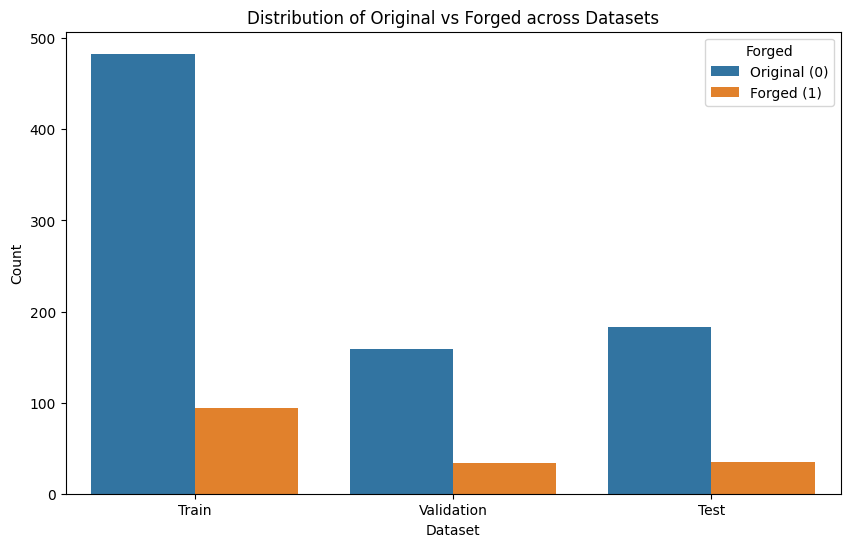

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 분석을 위해 데이터를 하나로 합치기
all_data = []
for name, file in files.items():
    df_temp = pd.read_csv(os.path.join(base_path, file), skipinitialspace=True)
    df_temp['set_name'] = name
    all_data.append(df_temp)

df_total = pd.concat(all_data)

# 그래프 그리기
plt.figure(figsize=(10, 6))
sns.countplot(x='set_name', hue='forged', data=df_total)
plt.title('Distribution of Original vs Forged across Datasets')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.legend(title='Forged', labels=['Original (0)', 'Forged (1)'])
plt.show()

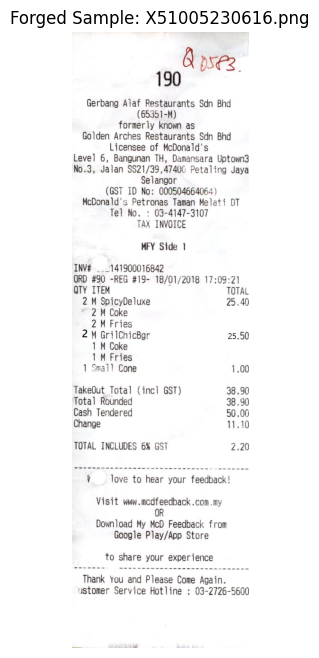

선택된 위조 이미지 파일명: X51005230616.png


In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# 1. train.txt에서 위조(1) 데이터만 추출
forged_data = df_temp[df_temp['forged'] == 1]

if len(forged_data) > 0:
    # 2. 첫 번째 위조 데이터 정보 가져오기
    sample_img_name = forged_data.iloc[0]['image']
    # [수정] df_temp는 현재 test.txt 데이터이므로, 이미지는 'test' 폴더에 있을 것으로 예상됩니다.
    sample_img_path = os.path.join(base_path, 'test', sample_img_name)

    # 3. 이미지 열기 및 출력
    img = Image.open(sample_img_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"Forged Sample: {sample_img_name}")
    plt.axis('off')
    plt.show()

    print(f"선택된 위조 이미지 파일명: {sample_img_name}")
else:
    print("위조(forged=1) 데이터를 찾을 수 없습니다. train.txt 파일을 확인해 보세요.")

베이스 라인

In [9]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import os

class SimpleReceiptDataset(Dataset):
    def __init__(self, txt_file, img_dir, transform=None):
        # 1. txt 파일 읽기
        self.df = pd.read_csv(txt_file, skipinitialspace=True)

        # Handle img_dir being a single string or a list
        if isinstance(img_dir, str):
            self.img_dirs = [img_dir] # Convert single path to a list for consistent iteration
        else:
            self.img_dirs = img_dir # img_dir is already a list

        # 2. 외부에서 전달받은 전처리 설정 사용 (없으면 기본 변환만)
        if transform:
            self.transform = transform
        else:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),#224픽셀로 고정
                transforms.ToTensor(),#숫자로 바꾸기
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])#정규화 표준편차/평균
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image']
        label = self.df.iloc[idx]['forged']

        image = None
        # Iterate through img_dirs to find the image
        for current_img_dir in self.img_dirs:
            img_path = os.path.join(current_img_dir, img_name)
            if os.path.exists(img_path):
                image = Image.open(img_path).convert("RGB")
                break

        if image is None:
            # If after checking all provided directories, the image is still not found
            # Return a black image to avoid crashing and print a warning
            print(f"Warning: Image {img_name} not found in any of the specified directories: {self.img_dirs}. Returning a black image.")
            image = Image.New('RGB', (224, 224), (0, 0, 0))

        # 설정된 전처리 적용
        image = self.transform(image)
        return image, label

In [10]:
from torch.utils.data import DataLoader

# 1. 이미지 변환 도구 (EfficientNet 표준 규격 224x224)
# (SimpleReceiptDataset 클래스 내부의 self.transform을 사용하므로,

# 2. 데이터셋 주머니(Dataset) 만들기
base_path = '/content/drive/MyDrive/Colab Notebooks/dataset/findit2'

train_set = SimpleReceiptDataset(f'{base_path}/train.txt', f'{base_path}/train')
# 검증용 사진도 train 폴더에 있었으니 경로를 train으로 통일합니다.
val_set = SimpleReceiptDataset(f'{base_path}/val.txt', f'{base_path}/train')

# 3. 실제 배달원(DataLoader) 고용하기
train_loader = DataLoader(
    train_set,
    batch_size=32,   # 한 번에 32장씩 배달
    shuffle=True,    # 공부할 때 문제 순서 섞기 (필수!)
    num_workers=2    # CPU 일꾼 2명 고용 (속도 향상)
)

val_loader = DataLoader(
    val_set,
    batch_size=32,
    shuffle=False,   # 시험 볼 때는 순서 섞을 필요 없음
    num_workers=2
)

print(f"데이터 준비 완료! 학습 데이터: {len(train_set)}장, 검증 데이터: {len(val_set)}장")

데이터 준비 완료! 학습 데이터: 577장, 검증 데이터: 193장


In [11]:
from torchvision import transforms

# 1. 학습용 증강 (Training Augmentation)
# 모델이 다양한 환경(조명, 각도)에서도 위조를 찾도록 훈련시킵니다.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),               # EfficientNet-B0 표준 입력 크기
    transforms.RandomRotation(10),               # ±10도 이내 회전 (영수증이 삐딱할 때 대비)
    transforms.RandomHorizontalFlip(p=0.5),      # 50% 확률로 좌우 반전
    transforms.ColorJitter(brightness=0.2,       # 밝기, 대비, 채도 무작위 조절
                           contrast=0.2,
                           saturation=0.2),
    transforms.ToTensor(),                       # 0~255 값을 0~1 사이로 변경
    transforms.Normalize([0.485, 0.456, 0.406],  # ImageNet 표준 정규화 (필수)
                         [0.229, 0.224, 0.225])
])

# 2. 검증/테스트용 (Validation/Test Transform)
# 평가는 공정해야 하므로 변형 없이 크기 조절과 정규화만 진행합니다.
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("데이터 증강 및 전처리 설정 완료! ✅")


# C. 데이터셋 및 로더 생성
# base_path 변수를 사용하여 올바른 경로를 지정합니다.
train_dataset = SimpleReceiptDataset(txt_file=f'{base_path}/train.txt', img_dir=f'{base_path}/train', transform=train_transform)
val_dataset = SimpleReceiptDataset(txt_file=f'{base_path}/val.txt', img_dir=[f'{base_path}/val', f'{base_path}/train'], transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print("데이터 증강이 포함된 로더 준비 완료! 🚀")

데이터 증강 및 전처리 설정 완료! ✅
데이터 증강이 포함된 로더 준비 완료! 🚀


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc
import numpy as np

# 1. 기기 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 장치: {device}")

# 2. 모델 설정 (EfficientNet-B0)
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(num_ftrs, 2)
)
model = model.to(device)

# 3. 손실 함수(CrossEntropy) 및 최적화 도구
# 가중치 3.0 적용: [진짜(0) 가중치 1.0, 위조(1) 가중치 3.0]
class_weights = torch.FloatTensor([1.0, 3.0]).to(device)#위조를 틀렸을 때 3배 더 높은 가중치를 준다
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 4. 모든 지표를 계산하는 평가 함수
def evaluate_model(model, dataloader, device):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    val_loss = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)[:, 1] # 위조(1)일 확률
            _, predicted = outputs.max(1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # 지표 계산
    acc = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # PR-AUC 계산
    precision, recall_curve, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall_curve, precision)

    return val_loss/len(dataloader), acc, recall, f1, roc_auc, pr_auc

# 5. 본 학습 루프 (10 Epochs)
epochs = 10
print("\n--- EfficientNet 베이스라인 학습 시작 (Weight: 3.0) ---")

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # 매 에포크마다 지표 출력
    v_loss, v_acc, v_recall, v_f1, v_roc, v_pr = evaluate_model(model, val_loader, device)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"  Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {v_loss:.4f}")
    print(f"  Acc: {v_acc:.4f} | Recall: {v_recall:.4f} | F1: {v_f1:.4f}")
    print(f"  ROC-AUC: {v_roc:.4f} | PR-AUC: {v_pr:.4f}")
    print("-" * 50)

현재 사용 중인 장치: cuda

--- EfficientNet 베이스라인 학습 시작 (Weight: 3.0) ---


KeyboardInterrupt: 

오토인코더 학습

In [ ]:
# [셀 1] 설치 & Drive 마운트
# ─────────────────────────────────────────
# !pip install -q pytorch-msssim scikit-image

from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum'], capture_output=True)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.__init__()
nanum = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
if nanum:
    plt.rcParams['font.family'] = nanum[0]
plt.rcParams['axes.unicode_minus'] = False
print(f"폰트: {nanum[0] if nanum else '기본'}")


# ─────────────────────────────────────────
# [셀 2] 경로 설정
# ─────────────────────────────────────────
import os

DATA_ROOT  = '/content/drive/MyDrive/Colab Notebooks/dataset/findit2'
TRAIN_CSV  = os.path.join(DATA_ROOT, 'train.txt')
VAL_CSV    = os.path.join(DATA_ROOT, 'val.txt')
TEST_CSV   = os.path.join(DATA_ROOT, 'test.txt')
TRAIN_DIR  = os.path.join(DATA_ROOT, 'train')
VAL_DIR    = os.path.join(DATA_ROOT, 'val')
TEST_DIR   = os.path.join(DATA_ROOT, 'test')
SAVE_DIR   = os.path.join(DATA_ROOT, 'checkpoints')
CACHE_DIR  = os.path.join(SAVE_DIR, 'preprocessed')
os.makedirs(SAVE_DIR, exist_ok=True)

for name, path in [('train.txt', TRAIN_CSV), ('val.txt', VAL_CSV),
                   ('test.txt',  TEST_CSV),  ('train/', TRAIN_DIR),
                   ('val/',      VAL_DIR),   ('test/',  TEST_DIR)]:
    print(f"  {'✅' if os.path.exists(path) else '❌'}  {name}")


# ─────────────────────────────────────────
# [셀 3] 라이브러리 임포트
# ─────────────────────────────────────────
import csv, ast, io, pickle, time
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from collections import Counter
from PIL import Image
from tqdm.auto import tqdm

import cv2
from skimage.feature import local_binary_pattern
from scipy.ndimage import gaussian_filter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ssim as ssim_fn

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}  /  GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")


# ─────────────────────────────────────────
# [셀 4] 전역 CONFIG
# ─────────────────────────────────────────
PATCH_SIZE = 64
STRIDE     = 32

CONFIG = {
    'data_root':       DATA_ROOT,
    'train_dir':       TRAIN_DIR,
    'val_dir':         VAL_DIR,
    'test_dir':        TEST_DIR,
    'save_dir':        SAVE_DIR,
    'cache_train':     os.path.join(CACHE_DIR, 'train'),
    'cache_val':       os.path.join(CACHE_DIR, 'val'),
    'cache_test':      os.path.join(CACHE_DIR, 'test'),
    'img_resize_w':    512,
    'patch_size':      PATCH_SIZE,
    'stride':          STRIDE,
    'ela_quality':     92,
    'ela_amplify':     10,
    'srm_sigma':       3.0,
    'lbp_radius':      2,
    'lbp_n_points':    16,
    'in_channels':     5,
    'batch_size':      128,
    'lr':              1e-3,
    'epochs':          100,
    'patience':        10,
    'topk_ratio':      0.05,
    'threshold_sigma': 3.0,
}
print("CONFIG 설정 완료")


# ─────────────────────────────────────────
# [셀 5] CSV 파싱 & 데이터 로드
# ─────────────────────────────────────────
def parse_annotation(ann_str):
    if ann_str in ('0', '', None):
        return None
    try:
        return ast.literal_eval(ann_str)
    except Exception:
        return None

def load_split(csv_path, img_dir):
    rows = []
    with open(csv_path, newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            fname = row['image']
            rows.append({
                'image':           fname,
                'img_path':        os.path.join(img_dir, fname),
                'digital_ann':     int(row['digital annotation']),
                'handwritten_ann': int(row['handwritten annotation']),
                'forged':          int(row['forged']),
                'forgery_ann':     parse_annotation(row['forgery annotations']),
            })
    return pd.DataFrame(rows)

df_train = load_split(TRAIN_CSV, TRAIN_DIR)
df_val   = load_split(VAL_CSV,   VAL_DIR)
df_test  = load_split(TEST_CSV,  TEST_DIR)

# 캐시 없는 행 제거
def has_cache(img_name, split):
    return os.path.exists(os.path.join(CONFIG[f'cache_{split}'],
                                       img_name.replace('.png', '.npy')))

df_train = df_train[df_train['image'].apply(lambda x: has_cache(x,'train'))].reset_index(drop=True)
df_val   = df_val  [df_val  ['image'].apply(lambda x: has_cache(x,'val'))  ].reset_index(drop=True)
df_test  = df_test [df_test ['image'].apply(lambda x: has_cache(x,'test')) ].reset_index(drop=True)

CONFIG.update({'df_train': df_train, 'df_val': df_val, 'df_test': df_test})

print(f"train: {len(df_train)}장  val: {len(df_val)}장  test: {len(df_test)}장")
for name, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    print(f"  {name}: 정상 {(df['forged']==0).sum()}  위조 {(df['forged']==1).sum()}")


# ─────────────────────────────────────────
# [셀 6] 전처리 함수 정의
# ─────────────────────────────────────────
def normalize(arr):
    arr = arr.astype(np.float32)
    mn, mx = arr.min(), arr.max()
    return np.zeros_like(arr) if mx - mn < 1e-6 else (arr - mn) / (mx - mn)

def make_gray_clahe(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    return normalize(cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(gray))

def make_ela(img_rgb, quality=92, amplify=10):
    buf = io.BytesIO()
    Image.fromarray(img_rgb).save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    recomp = np.array(Image.open(buf).convert('RGB'))
    diff = cv2.absdiff(img_rgb, recomp).astype(np.float32).mean(axis=2) * amplify
    return normalize(np.clip(diff, 0, 255))

def make_srm(img_rgb, sigma=3.0):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    return normalize(np.abs(gray - gaussian_filter(gray, sigma=sigma)))

def make_lbp(img_rgb, radius=2, n_points=16):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    return normalize(local_binary_pattern(gray, n_points, radius, method='uniform'))

def make_dct_highfreq(img_rgb, block_size=8):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    H, W = gray.shape
    Hp, Wp = (H//block_size)*block_size, (W//block_size)*block_size
    g = gray[:Hp, :Wp]
    energy = np.zeros((Hp, Wp), dtype=np.float32)
    for r in range(0, Hp, block_size):
        for c in range(0, Wp, block_size):
            blk = cv2.dct(g[r:r+block_size, c:c+block_size])
            blk[0, 0] = 0
            energy[r:r+block_size, c:c+block_size] = np.sum(blk**2)
    full = np.zeros((H, W), dtype=np.float32)
    full[:Hp, :Wp] = energy
    return normalize(full)

def preprocess_image(img_path, resize_w=512, ela_quality=92, ela_amplify=10,
                     srm_sigma=3.0, lbp_radius=2, lbp_n_points=16):
    img_pil = Image.open(img_path).convert('RGB')
    ow, oh  = img_pil.size
    nh      = int(oh * resize_w / ow)
    img_rgb = np.array(img_pil.resize((resize_w, nh), Image.LANCZOS))
    return np.stack([
        make_gray_clahe(img_rgb),
        make_ela(img_rgb, ela_quality, ela_amplify),
        make_srm(img_rgb, srm_sigma),
        make_lbp(img_rgb, lbp_radius, lbp_n_points),
        make_dct_highfreq(img_rgb),
    ], axis=-1)

print("전처리 함수 정의 완료")


# ─────────────────────────────────────────
# [셀 7] Drive → /tmp 로컬 복사
# ─────────────────────────────────────────
import shutil

LOCAL_CACHE = '/tmp/receipt_cache'

for split in ['train', 'val', 'test']:
    src   = CONFIG[f'cache_{split}']
    dst   = os.path.join(LOCAL_CACHE, split)
    os.makedirs(dst, exist_ok=True)
    files = [f for f in os.listdir(src) if f.endswith('.npy')]

    # 이미 복사된 파일은 스킵
    to_copy = [f for f in files if not os.path.exists(os.path.join(dst, f))]
    if to_copy:
        for fname in tqdm(to_copy, desc=f'복사 [{split}]'):
            shutil.copy2(os.path.join(src, fname), os.path.join(dst, fname))
    else:
        print(f"[{split}] 이미 복사됨 — 스킵")

    CONFIG[f'cache_{split}'] = dst
    print(f"[{split}] {len(files)}개  →  {dst}")

print("✅ 로컬 복사 완료")


# ─────────────────────────────────────────
# [셀 8] RAM 적재
# ─────────────────────────────────────────
def load_all_to_ram(df, split):
    cache = {}
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f'[{split}] RAM 적재'):
        cp = os.path.join(CONFIG[f'cache_{split}'],
                          row['image'].replace('.png', '.npy'))
        cache[row['image']] = np.load(cp).astype(np.float32)
    return cache

ram_train = load_all_to_ram(df_train, 'train')
ram_val   = load_all_to_ram(df_val,   'val')
ram_test  = load_all_to_ram(df_test,  'test')
print(f"RAM 적재 완료 — train {len(ram_train)} / val {len(ram_val)} / test {len(ram_test)}")


# ─────────────────────────────────────────
# [셀 9] 패치 유틸 함수
# ─────────────────────────────────────────
def get_patch_coords(img_h, img_w, patch_size, stride):
    coords = []
    for y in range(0, img_h - patch_size + 1, stride):
        for x in range(0, img_w - patch_size + 1, stride):
            coords.append((y, x))
    return coords

def bbox_iou(patch_y, patch_x, patch_size, bbox):
    py1, px1 = patch_y, patch_x
    py2, px2 = patch_y + patch_size, patch_x + patch_size
    bx1, by1 = bbox['x'], bbox['y']
    bx2, by2 = bbox['x'] + bbox['width'], bbox['y'] + bbox['height']
    inter = max(0, min(px2,bx2)-max(px1,bx1)) * max(0, min(py2,by2)-max(py1,by1))
    if inter == 0: return 0.0
    union = patch_size**2 + bbox['width']*bbox['height'] - inter
    return inter / union if union > 0 else 0.0

def get_patch_labels(img_h, img_w, patch_size, stride,
                     forgery_ann, resize_w, orig_w, orig_h,
                     iou_threshold=0.05):
    coords = get_patch_coords(img_h, img_w, patch_size, stride)
    labels = [0] * len(coords)
    if forgery_ann is None:
        return labels
    sx, sy = resize_w / orig_w, img_h / orig_h
    for region in forgery_ann.get('regions', []):
        ra, sa = region['region_attributes'], region['shape_attributes']
        if ra.get('Original area') != 'no':
            continue
        bbox = {
            'x':      int(sa.get('x',0) * sx),
            'y':      int(sa.get('y',0) * sy),
            'width':  max(1, int(sa.get('width',1)  * sx)),
            'height': max(1, int(sa.get('height',1) * sy)),
        }
        for i, (py, px) in enumerate(coords):
            if bbox_iou(py, px, patch_size, bbox) > iou_threshold:
                labels[i] = 1
    return labels

print("패치 유틸 함수 정의 완료")


# ─────────────────────────────────────────
# [셀 10] RamPatchDataset 정의
# ─────────────────────────────────────────
class RamPatchDataset(Dataset):
    def __init__(self, df, ram_cache, mode='train_normal',
                 patch_size=64, stride=32, resize_w=512):
        self.df         = df.reset_index(drop=True)
        self.ram        = ram_cache
        self.mode       = mode
        self.patch_size = patch_size
        self.stride     = stride
        self.resize_w   = resize_w
        self.index      = self._build_index()
        print(f"[{mode}] 패치 수: {len(self.index):,}")

    def _build_index(self):
        index = []
        for img_idx, row in self.df.iterrows():
            if row['image'] not in self.ram:
                continue
            tensor       = self.ram[row['image']]
            H, W         = tensor.shape[0], tensor.shape[1]
            img          = Image.open(row['img_path'])
            orig_w, orig_h = img.size
            img.close()
            coords = get_patch_coords(H, W, self.patch_size, self.stride)
            labels = get_patch_labels(H, W, self.patch_size, self.stride,
                                      row['forgery_ann'], self.resize_w,
                                      orig_w, orig_h)
            for (py, px), lbl in zip(coords, labels):
                if self.mode == 'train_normal':
                    if row['forged'] == 0:
                        index.append((img_idx, py, px, 0))
                else:
                    index.append((img_idx, py, px, lbl))
        return index

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        img_idx, py, px, label = self.index[idx]
        row    = self.df.iloc[img_idx]
        tensor = self.ram[row['image']]
        patch  = tensor[py:py+self.patch_size, px:px+self.patch_size, :]
        patch  = torch.from_numpy(patch.copy()).permute(2, 0, 1)
        if self.mode == 'train_normal':
            return patch
        else:
            return patch, img_idx, idx, label

print("RamPatchDataset 정의 완료")


# ─────────────────────────────────────────
# [셀 11] Dataset & DataLoader 생성
# ─────────────────────────────────────────
ds_train      = RamPatchDataset(df_train, ram_train, mode='train_normal',
                                 patch_size=PATCH_SIZE, stride=STRIDE,
                                 resize_w=CONFIG['img_resize_w'])
# val: 정상 패치만 (loss 안정화)
ds_val_normal = RamPatchDataset(df_val, ram_val, mode='train_normal',
                                 patch_size=PATCH_SIZE, stride=STRIDE,
                                 resize_w=CONFIG['img_resize_w'])
# val/test: 추론용 (전체 패치)
ds_val_infer  = RamPatchDataset(df_val,  ram_val,  mode='inference',
                                 patch_size=PATCH_SIZE, stride=STRIDE,
                                 resize_w=CONFIG['img_resize_w'])
ds_test_infer = RamPatchDataset(df_test, ram_test, mode='inference',
                                 patch_size=PATCH_SIZE, stride=STRIDE,
                                 resize_w=CONFIG['img_resize_w'])

dl_train      = DataLoader(ds_train,      batch_size=CONFIG['batch_size'],
                           shuffle=True,  num_workers=0, pin_memory=True)
dl_val_normal = DataLoader(ds_val_normal, batch_size=CONFIG['batch_size'],
                           shuffle=False, num_workers=0, pin_memory=True)
dl_val        = DataLoader(ds_val_infer,  batch_size=CONFIG['batch_size'],
                           shuffle=False, num_workers=0, pin_memory=True)
dl_test       = DataLoader(ds_test_infer, batch_size=CONFIG['batch_size'],
                           shuffle=False, num_workers=0, pin_memory=True)

CONFIG.update({
    'ds_train': ds_train, 'ds_val_infer': ds_val_infer,
    'ds_test_infer': ds_test_infer, 'dl_train': dl_train,
    'dl_val': dl_val, 'dl_test': dl_test,
    'dl_val_normal': dl_val_normal,
})

print(f"\n학습(정상) 패치   : {len(ds_train):,}")
print(f"val 정상 패치     : {len(ds_val_normal):,}")
print(f"val 전체 패치     : {len(ds_val_infer):,}")
print(f"test 전체 패치    : {len(ds_test_infer):,}")

# 속도 테스트
import time
t = time.time()
for i, b in enumerate(dl_train):
    if i == 9: break
print(f"\n배치 10개 평균: {(time.time()-t)/10:.3f}초")


# ─────────────────────────────────────────
# [셀 12] 오토인코더 모델 정의
# ─────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x): return self.block(x)

class ReceiptAutoEncoder(nn.Module):
    def __init__(self, in_channels=5):
        super().__init__()
        self.enc1  = ConvBlock(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2  = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3  = ConvBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(128, 256)
        self.up3   = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3  = ConvBlock(256, 128)
        self.up2   = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2  = ConvBlock(128, 64)
        self.up1   = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1  = ConvBlock(64, 32)
        self.out   = nn.Sequential(nn.Conv2d(32, in_channels, 1), nn.Sigmoid())

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b  = self.bottleneck(self.pool3(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)

model = ReceiptAutoEncoder(in_channels=CONFIG['in_channels']).to(DEVICE)
print(f"파라미터: {sum(p.numel() for p in model.parameters()):,}")

dummy = torch.randn(4, CONFIG['in_channels'], PATCH_SIZE, PATCH_SIZE).to(DEVICE)
with torch.no_grad():
    assert model(dummy).shape == dummy.shape
print("✅ 모델 shape 검증 통과")

In [ ]:
# [셀 13 교체] 손실함수 — autocast 밖에서 SSIM 계산
class MSE_SSIM_Loss(nn.Module):
    def __init__(self, alpha=0.7):
        super().__init__()
        self.alpha = alpha
        self.mse   = nn.MSELoss()

    def forward(self, pred, target):
        # float32로 강제 변환 후 SSIM 계산
        pred_f   = pred.float()
        target_f = target.float()
        l_mse    = self.mse(pred_f, target_f)
        l_ssim   = 1.0 - ssim_fn(pred_f, target_f,
                                  data_range=1.0, size_average=True)
        return self.alpha * l_mse + (1-self.alpha) * l_ssim, \
               l_mse.item(), l_ssim.item()

criterion = MSE_SSIM_Loss(alpha=0.7)
print("손실함수 재정의 완료")


# [셀 14 교체] 학습루프 — autocast 범위 축소 (forward만)
# 모델 새로 초기화
model      = ReceiptAutoEncoder(in_channels=CONFIG['in_channels']).to(DEVICE)
optimizer  = optim.Adam(model.parameters(), lr=CONFIG['lr'])
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
scaler     = torch.amp.GradScaler('cuda')
early_stop = EarlyStopping(patience=CONFIG['patience'])
history    = {'train_loss': [], 'val_loss': [], 'mse': [], 'ssim_loss': []}
best_val   = float('inf')

print("=" * 57)
print(f"학습 시작 | epochs={CONFIG['epochs']}  batch={CONFIG['batch_size']}  lr={CONFIG['lr']}")
print(f"학습 패치: {len(dl_train.dataset):,}  val 정상 패치: {len(dl_val_normal.dataset):,}")
print("=" * 57)

t_start = time.time()

for epoch in range(1, CONFIG['epochs'] + 1):
    model.train()
    e_loss = e_mse = e_ssim = 0.0

    for batch in dl_train:
        patches = batch.to(DEVICE)
        optimizer.zero_grad()

        # forward만 autocast (float16 절약)
        with torch.amp.autocast('cuda'):
            recon = model(patches)

        # loss는 float32로 계산
        loss, mse_v, ssim_v = criterion(recon, patches)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        e_loss += loss.item()
        e_mse  += mse_v
        e_ssim += ssim_v

    nb         = len(dl_train)
    train_loss = e_loss / nb
    val_loss   = evaluate(model, dl_val_normal, criterion, DEVICE)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['mse'].append(e_mse / nb)
    history['ssim_loss'].append(e_ssim / nb)

    if val_loss < best_val:
        best_val = val_loss
        save_checkpoint(model, optimizer, epoch, val_loss, CKPT_BEST)
    save_checkpoint(model, optimizer, epoch, val_loss, CKPT_LAST)

    elapsed = (time.time() - t_start) / 60
    if epoch % 5 == 0 or epoch == 1:
        print(f"[{epoch:>3}/{CONFIG['epochs']}] "
              f"train={train_loss:.5f}  val={val_loss:.5f}  "
              f"best={best_val:.5f}  {elapsed:.1f}min")

    if early_stop.step(val_loss, epoch):
        print(f"\n⏹ 조기 종료 epoch {epoch}  (best: {early_stop.best_epoch})")
        break

total_min = (time.time() - t_start) / 60
print(f"\n학습 완료 | {total_min:.1f}분  best val={best_val:.6f}")

with open(os.path.join(SAVE_DIR, 'history.pkl'), 'wb') as f:
    pickle.dump(history, f)
CONFIG['history'] = history

# ─────────────────────────────────────────
# [셀 15] 학습 곡선 & 재구성 시각화
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train', color='#7F77DD')
axes[0].plot(history['val_loss'],   label='val',   color='#D85A30')
axes[0].set_title('Train / Val Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['mse'],       label='MSE',    color='#1D9E75')
axes[1].plot(history['ssim_loss'], label='1-SSIM', color='#EF9F27')
axes[1].set_title('MSE vs 1-SSIM'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'loss_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"best val epoch: {int(np.argmin(history['val_loss']))+1}  loss={min(history['val_loss']):.6f}")


# ─────────────────────────────────────────
# [셀 16] 정상 패치 오차 분포 & threshold 후보
# ─────────────────────────────────────────
load_checkpoint(model, None, CKPT_BEST)
model.eval()
normal_errors = []

with torch.no_grad():
    for batch in tqdm(dl_train, desc='오차 계산'):
        patches = batch.to(DEVICE)
        with torch.amp.autocast('cuda'):
            recon = model(patches)
        err = ((patches - recon) ** 2).mean(dim=[1,2,3])
        normal_errors.extend(err.cpu().numpy().tolist())

normal_errors = np.array(normal_errors)
mu, sigma = normal_errors.mean(), normal_errors.std()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(normal_errors, bins=80, color='#7F77DD', edgecolor='none',
        density=True, alpha=0.7)
for ns, color in [(2,'#EF9F27'), (3,'#D85A30'), (4,'#7F1A1A')]:
    t = mu + ns * sigma
    ax.axvline(t, color=color, linestyle='--', label=f'μ+{ns}σ={t:.5f}')
ax.set_title('정상 패치 오차 분포')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'error_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

CONFIG['normal_error_mu']      = float(mu)
CONFIG['normal_error_sigma']   = float(sigma)
CONFIG['threshold_candidate']  = float(mu + CONFIG['threshold_sigma'] * sigma)

print(f"\n정상 오차 분포: μ={mu:.6f}  σ={sigma:.6f}")
print(f"threshold 후보 (μ+3σ): {CONFIG['threshold_candidate']:.6f}")



전처리-RGB 3채널 사용



In [27]:
RGB 3채널만 사용
import torchvision.models as models

class BaselineDataset(Dataset):
    def __init__(self, txt_file, split='train',
                 patch_size=128, augment=True):
        self.patch_size = patch_size
        self.augment    = augment
        self.split      = split
        self.data       = []

        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(10),
            # transforms.ColorJitter(
            #     brightness=0.2, contrast=0.2), # ColorJitter causes error with 6 channels
        ]) if augment else transforms.Compose([])

        self.to_tensor = transforms.ToTensor()

        txt_path = os.path.join(BASE_PATH, txt_file)
        df       = pd.read_csv(txt_path,
                               skipinitialspace=True)
        img_dir  = os.path.join(BASE_PATH, split)

        for _, row in df.iterrows():
            img_path = os.path.join(img_dir, row['image'])
            if not os.path.exists(img_path): continue

            label        = int(row['forged'])
            forge_coords = []
            if label==1 and pd.notna(
                    row['forgery annotations']):
                try:
                    annot = ast.literal_eval(
                        row['forgery annotations'])
                    for region in annot.get('regions',[]):
                        ra = region['region_attributes']
                        ma = ra.get('Modified area', {})
                        if 'None' in ma: continue
                        sa = region['shape_attributes']
                        cx = sa['x'] + sa['width']  // 2
                        cy = sa['y'] + sa['height'] // 2
                        forge_coords.append((cx, cy))
                except:
                    pass

            self.data.append({
                'img_path':     img_path,
                'label':        label,
                'forge_coords': forge_coords,
            })
        print(f"[{split}] {len(self.data)}장 로드")

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item    = self.data[idx]
        ps      = self.patch_size
        img_rgb = np.array(
            Image.open(item['img_path']).convert('RGB'))
        H, W    = img_rgb.shape[:2]

        if H < ps or W < ps:
            img_rgb = np.array(
                Image.fromarray(img_rgb).resize(
                    (max(W,ps), max(H,ps)),
                    Image.LANCZOS))
            H, W = img_rgb.shape[:2]

        # 패치 중심
        label   = item['label']
        fcoords = item['forge_coords']
        if label==1 and fcoords:
            cx, cy = random.choice(fcoords)
            cx, cy = int(cx), int(cy)
        else:
            cx = random.randint(W//4, 3*W//4)
            cy = random.randint(H//4, 3*H//4)

        # High-Res 패치
        left = max(0, min(cx-ps//2, W-ps))
        top  = max(0, min(cy-ps//2, H-ps))
        patch_high = img_rgb[top:top+ps, left:left+ps, :]

        # Low-Res 패치
        wide = ps * 2
        if H < wide or W < wide:
            patch_low = cv2.resize(img_rgb, (ps, ps))
        else:
            wl = max(0, min(cx-wide//2, W-wide))
            wt = max(0, min(cy-wide//2, H-wide))
            pw = img_rgb[wt:wt+wide, wl:wl+wide, :]
            patch_low = cv2.resize(pw, (ps, ps))

        # (H,W,3) → 텐서
        t_high = torch.from_numpy(
            patch_high.transpose(2,0,1)).float() / 255.0
        t_low  = torch.from_numpy(
            patch_low.transpose(2,0,1)).float() / 255.0
        combined = torch.cat([t_high, t_low], dim=0)  # 6채널

        if self.split == 'train' and self.augment:
            combined = self.aug(combined)

        return combined, label


# 베이스라인 모델 (EfficientNet-B3 6채널)
class BaselineClassifier(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b3', pretrained=True,
            num_classes=0, in_chans=3)
        old_conv = self.backbone.conv_stem
        self.backbone.conv_stem = nn.Conv2d(
            in_channels, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding, bias=False)
        with torch.no_grad():
            w     = old_conv.weight.data
            new_w = w.repeat(1, in_channels//3+1, 1, 1)
            self.backbone.conv_stem.weight.data = \
                new_w[:, :in_channels, :, :]
        feat_dim = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.classifier(self.backbone(x))


# Dataset + DataLoader
train_ds_bl = BaselineDataset('train.txt', split='train')
val_ds_bl   = BaselineDataset('val.txt',   split='val',
                               augment=False)

labels_bl  = [item['label'] for item in train_ds_bl.data]
n_neg      = labels_bl.count(0)
n_pos      = labels_bl.count(1)
weights_bl = [1.0/n_neg if l==0 else 1.0/n_pos
              for l in labels_bl]
sampler_bl = WeightedRandomSampler(
    weights_bl, num_samples=len(weights_bl),
    replacement=True)

train_loader_bl = DataLoader(
    train_ds_bl, batch_size=64,  # 32→64
    sampler=sampler_bl, num_workers=2,  # 0→2
    pin_memory=True)
val_loader_bl = DataLoader(
    val_ds_bl, batch_size=64,  # 32→64
    shuffle=False, num_workers=2)  # 0→2

model_bl   = BaselineClassifier(in_channels=6).to(DEVICE)
optimizer_bl = optim.Adam(model_bl.parameters(), lr=1e-4)
scheduler_bl = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_bl, T_max=50, eta_min=1e-6)
criterion_bl = FocalLoss()

CKPT_BL  = os.path.join(SAVE_DIR, 'baseline_best.pt')
best_pr_bl = 0.0
EPOCHS_BL  = 50

# --- [Early Stopping 추가된 부분] ---
PATIENCE = 15
early_stop_counter = 0
# --------------------------------

print("="*70)
print(f"베이스라인 | RGB 3채널만 | 전처리 없음 | {EPOCHS_BL}에폭 (Patience: {PATIENCE})")
print("="*70)
print(f"{'Ep':>4} {'TrLoss':>7} {'VaLoss':>7} {'Acc':>7} "
      f"{'F1':>7} {'Recall':>7} {'Prec':>7} "
      f"{'ROC':>7} {'PR':>7} {'Best':>7}")
print("-"*75)

t_start = time.time()
for epoch in range(1, EPOCHS_BL+1):
    model_bl.train()
    t_loss = 0.0
    for x, y in train_loader_bl:
        x = x.to(DEVICE)
        y = y.float().to(DEVICE).unsqueeze(1)
        optimizer_bl.zero_grad()
        loss = criterion_bl(model_bl(x), y)
        loss.backward(); optimizer_bl.step()
        t_loss += loss.item()

    model_bl.eval()
    v_probs, v_labels, v_loss = [], [], 0.0
    with torch.no_grad():
        for x, y in val_loader_bl:
            x     = x.to(DEVICE)
            y_gpu = y.float().to(DEVICE).unsqueeze(1)
            out   = model_bl(x)
            v_loss += criterion_bl(out, y_gpu).item()
            v_probs.extend(
                torch.sigmoid(out).cpu().numpy().flatten())
            v_labels.extend(y.numpy().flatten())

    v_probs  = np.array(v_probs)
    v_labels = np.array(v_labels)

    prec_c, rec_c, ths_c = precision_recall_curve(
        v_labels, v_probs)
    f1s_c  = 2*prec_c*rec_c / (prec_c+rec_c+1e-8)
    best_i = np.argmax(f1s_c)
    v_thr  = float(ths_c[best_i]) if best_i < len(ths_c) else 0.5
    v_pred = (v_probs >= v_thr).astype(int)

    v_acc  = accuracy_score(v_labels,  v_pred)
    v_f1   = f1_score(v_labels,        v_pred, zero_division=0)
    v_rec  = recall_score(v_labels,    v_pred, zero_division=0)
    v_prec = precision_score(v_labels, v_pred, zero_division=0)
    v_roc  = roc_auc_score(v_labels,   v_probs)
    v_pr   = average_precision_score(v_labels, v_probs)
    tl     = t_loss / len(train_loader_bl)
    vl     = v_loss / len(val_loader_bl)
    elapsed = (time.time()-t_start)/60

    marker = ''
    if v_pr > best_pr_bl:
        best_pr_bl = v_pr
        torch.save({
            'epoch': epoch,
            'model': model_bl.state_dict(),
            'threshold': v_thr,
            'best_pr': best_pr_bl,
        }, CKPT_BL)
        marker = ' ✅'
        # --- [Early Stopping 초기화 부분] ---
        early_stop_counter = 0
    else:
        # 갱신되지 않았을 경우 카운터 증가
        early_stop_counter += 1
        # --------------------------------

    print(f"{epoch:>4} {tl:>7.4f} {vl:>7.4f} {v_acc:>7.4f} "
          f"{v_f1:>7.4f} {v_rec:>7.4f} {v_prec:>7.4f} "
          f"{v_roc:>7.4f} {v_pr:>7.4f} "
          f"{best_pr_bl:>7.4f}{marker}  ({elapsed:.1f}min)")

    # --- [Early Stopping 발동 부분] ---
    if early_stop_counter >= PATIENCE:
        print(f"\n[Early Stopping] {PATIENCE}에폭 동안 PR-AUC 개선이 없어 학습을 조기 종료합니다.")
        break
    # --------------------------------

    scheduler_bl.step()

print(f"\n베이스라인 완료! best PR-AUC={best_pr_bl:.4f}")
print(f"\n{'='*50}")
print(f"비교 (val 기준)")
print(f"{'='*50}")
print(f"  베이스라인 (RGB만):     PR-AUC={best_pr_bl:.4f}")
print(f"  전처리 추가 버전:       PR-AUC=0.7796")

[train] 577장 로드
[val] 192장 로드
베이스라인 | RGB 3채널만 | 전처리 없음 | 50에폭 (Patience: 15)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
---------------------------------------------------------------------------
   1  0.1260  0.1248  0.7552  0.4198  0.5152  0.3542  0.6869  0.3392  0.3392 ✅  (1.2min)
   2  0.1310  0.1307  0.7292  0.4348  0.6061  0.3390  0.6937  0.3726  0.3726 ✅  (2.2min)
   3  0.1189  0.1288  0.7969  0.4179  0.4242  0.4118  0.6711  0.3436  0.3726  (3.4min)
   4  0.1204  0.1337  0.5938  0.3906  0.7576  0.2632  0.6802  0.3089  0.3726  (4.1min)
   5  0.1171  0.1217  0.8385  0.4561  0.3939  0.5417  0.7263  0.4386  0.4386 ✅  (5.0min)
   6  0.1123  0.1144  0.7812  0.4167  0.4545  0.3846  0.6964  0.4020  0.4386  (5.8min)
   7  0.1046  0.1022  0.7396  0.4444  0.6061  0.3509  0.7277  0.4051  0.4386  (6.9min)
   8  0.0964  0.0953  0.8542  0.5333  0.4848  0.5926  0.7555  0.5148  0.5148 ✅  (7.8min)
   9  0.0933  0.0963  0.7917  0.5349  0.6970  0.4340  0.7591  0.3

In [28]:
# 이어서 학습 (150에폭 추가)
ckpt_bl = torch.load(
    os.path.join(SAVE_DIR, 'baseline_best.pt'),
    map_location=DEVICE, weights_only=False)

model_bl = BaselineClassifier(in_channels=6).to(DEVICE)
model_bl.load_state_dict(ckpt_bl['model'])
start_epoch = ckpt_bl['epoch'] + 1
best_pr_bl  = ckpt_bl['best_pr']
print(f"epoch {start_epoch}부터 재개  "
      f"best PR-AUC={best_pr_bl:.4f}")

optimizer_bl = optim.Adam(model_bl.parameters(), lr=5e-5)  # lr 낮춤
scheduler_bl = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_bl, T_max=150, eta_min=1e-6)
criterion_bl = FocalLoss()

patience   = 15
counter    = 0
ADD_EPOCHS = 150
END_EPOCH  = start_epoch + ADD_EPOCHS - 1

print("="*75)
print(f"베이스라인 이어서 학습 | epoch {start_epoch}~{END_EPOCH}")
print("="*75)
print(f"{'Ep':>4} {'TrLoss':>7} {'VaLoss':>7} {'Acc':>7} "
      f"{'F1':>7} {'Recall':>7} {'Prec':>7} "
      f"{'ROC':>7} {'PR':>7} {'Best':>7}")
print("-"*75)

t_start = time.time()
for epoch in range(start_epoch, END_EPOCH+1):
    model_bl.train()
    t_loss = 0.0
    for x, y in train_loader_bl:
        x = x.to(DEVICE)
        y = y.float().to(DEVICE).unsqueeze(1)
        optimizer_bl.zero_grad()
        loss = criterion_bl(model_bl(x), y)
        loss.backward(); optimizer_bl.step()
        t_loss += loss.item()

    model_bl.eval()
    v_probs, v_labels, v_loss = [], [], 0.0
    with torch.no_grad():
        for x, y in val_loader_bl:
            x     = x.to(DEVICE)
            y_gpu = y.float().to(DEVICE).unsqueeze(1)
            out   = model_bl(x)
            v_loss += criterion_bl(out, y_gpu).item()
            v_probs.extend(
                torch.sigmoid(out).cpu().numpy().flatten())
            v_labels.extend(y.numpy().flatten())

    v_probs  = np.array(v_probs)
    v_labels = np.array(v_labels)

    prec_c, rec_c, ths_c = precision_recall_curve(
        v_labels, v_probs)
    f1s_c  = 2*prec_c*rec_c / (prec_c+rec_c+1e-8)
    best_i = np.argmax(f1s_c)
    v_thr  = float(ths_c[best_i]) if best_i < len(ths_c) else 0.5
    v_pred = (v_probs >= v_thr).astype(int)

    v_acc  = accuracy_score(v_labels,  v_pred)
    v_f1   = f1_score(v_labels,        v_pred, zero_division=0)
    v_rec  = recall_score(v_labels,    v_pred, zero_division=0)
    v_prec = precision_score(v_labels, v_pred, zero_division=0)
    v_roc  = roc_auc_score(v_labels,   v_probs)
    v_pr   = average_precision_score(v_labels, v_probs)
    tl     = t_loss / len(train_loader_bl)
    vl     = v_loss / len(val_loader_bl)
    elapsed = (time.time()-t_start)/60

    marker = ''
    if v_pr > best_pr_bl:
        best_pr_bl = v_pr
        torch.save({
            'epoch':     epoch,
            'model':     model_bl.state_dict(),
            'optimizer': optimizer_bl.state_dict(),
            'threshold': v_thr,
            'best_pr':   best_pr_bl,
        }, CKPT_BL)
        marker  = ' ✅'
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"\n⏹ 조기종료 epoch={epoch}  "
                  f"best PR-AUC={best_pr_bl:.4f}")
            break

    print(f"{epoch:>4} {tl:>7.4f} {vl:>7.4f} {v_acc:>7.4f} "
          f"{v_f1:>7.4f} {v_rec:>7.4f} {v_prec:>7.4f} "
          f"{v_roc:>7.4f} {v_pr:>7.4f} "
          f"{best_pr_bl:>7.4f}{marker}  ({elapsed:.1f}min)")

    scheduler_bl.step()

print(f"\n이어서 학습 완료! best PR-AUC={best_pr_bl:.4f}")

# ══════════════════════════════════════════
# 베이스라인 Test 최종 평가
# ══════════════════════════════════════════
print("\n베이스라인 Test 평가 중...")
ckpt_bl  = torch.load(CKPT_BL, map_location=DEVICE,
                       weights_only=False)
model_bl.load_state_dict(ckpt_bl['model'])
model_bl.eval()
best_thr_bl = ckpt_bl['threshold']
print(f"모델 로드 — epoch={ckpt_bl['epoch']}  "
      f"val PR-AUC={ckpt_bl['best_pr']:.4f}  "
      f"threshold={best_thr_bl:.4f}")

test_ds_bl = BaselineDataset(
    'test.txt', split='test', augment=False)
test_loader_bl = DataLoader(
    test_ds_bl, batch_size=64,
    shuffle=False, num_workers=2)

t_probs, t_labels = [], []
with torch.no_grad():
    for x, y in test_loader_bl:
        x = x.to(DEVICE)
        t_probs.extend(
            torch.sigmoid(model_bl(x)).cpu().numpy().flatten())
        t_labels.extend(y.numpy().flatten())

t_probs  = np.array(t_probs)
t_labels = np.array(t_labels)
t_preds  = (t_probs >= best_thr_bl).astype(int)

acc  = accuracy_score(t_labels,          t_preds)
f1   = f1_score(t_labels,                t_preds, zero_division=0)
rec  = recall_score(t_labels,            t_preds, zero_division=0)
prec = precision_score(t_labels,         t_preds, zero_division=0)
auc  = roc_auc_score(t_labels,           t_probs)
pr   = average_precision_score(t_labels, t_probs)
cm   = confusion_matrix(t_labels,        t_preds)

print(f"\n{'='*50}")
print(f"베이스라인 최종 Test 결과")
print(f"{'='*50}")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print(f"  PR-AUC    : {pr:.4f}")
print(f"\n  TN={cm[0,0]}  FP={cm[0,1]}")
print(f"  FN={cm[1,0]}  TP={cm[1,1]}")
print(f"\n{'='*50}")
print(f"최종 비교 (Test 기준)")
print(f"{'='*50}")
print(f"  오토인코더          : F1=0.308  AUC=0.515")
print(f"  베이스라인 (RGB만)  : F1={f1:.3f}  AUC={auc:.3f}")
print(f"  전처리 추가 버전    : F1=0.582  AUC=0.848")

epoch 21부터 재개  best PR-AUC=0.6616
베이스라인 이어서 학습 | epoch 21~170
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
---------------------------------------------------------------------------
  21  0.0638  0.0955  0.8177  0.5070  0.5455  0.4737  0.7719  0.4948  0.6616  (1.1min)
  22  0.0626  0.0921  0.8438  0.5000  0.4545  0.5556  0.7469  0.4861  0.6616  (2.0min)
  23  0.0568  0.0839  0.8646  0.5806  0.5455  0.6207  0.7692  0.5761  0.6616  (2.9min)
  24  0.0614  0.0800  0.8594  0.6087  0.6364  0.5833  0.8144  0.6249  0.6616  (3.8min)
  25  0.0579  0.1114  0.7604  0.4524  0.5758  0.3725  0.7113  0.4394  0.6616  (4.6min)
  26  0.0548  0.0818  0.8906  0.6182  0.5152  0.7727  0.7724  0.6026  0.6616  (5.5min)
  27  0.0610  0.0902  0.8229  0.5000  0.5152  0.4857  0.7621  0.5272  0.6616  (6.3min)
  28  0.0513  0.0799  0.8594  0.5714  0.5455  0.6000  0.8012  0.6145  0.6616  (7.1min)
  29  0.0647  0.0953  0.7865  0.5176  0.6667  0.4231  0.7673  0.5131  0.6616  (8.0min)
  

전처리 적용(ELA)

In [2]:
# 셀 1: 환경세팅
from google.colab import drive
drive.mount('/content/drive')

!pip install -q pytorch-msssim timm

import os, ast, io, time, random, glob
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm
from sklearn.metrics import (
    f1_score, roc_auc_score, recall_score,
    precision_score, confusion_matrix,
    average_precision_score, precision_recall_curve,
    accuracy_score
)

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/dataset/findit2'
SAVE_DIR  = os.path.join(BASE_PATH, 'checkpoints')
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"GPU: {torch.cuda.get_device_name(0)}")
print("✅ 셀 1 완료")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: NVIDIA A100-SXM4-40GB
✅ 셀 1 완료


In [3]:
# 셀 2: 데이터프레임 로드
def load_df(split):
    txt = os.path.join(BASE_PATH, f'{split}.txt')
    df  = pd.read_csv(txt, skipinitialspace=True)
    df['img_path'] = df['image'].apply(
        lambda x: os.path.join(BASE_PATH, split, x))
    df['forged'] = df['forged'].astype(int)
    df['forgery_ann'] = df['forgery annotations'].apply(
        lambda x: ast.literal_eval(x) if pd.notna(x) else None)
    return df

df_train = load_df('train')
df_val   = load_df('val')
df_test  = load_df('test')
print(f"train:{len(df_train)}  val:{len(df_val)}  test:{len(df_test)}")
print("✅ 셀 2 완료")

train:577  val:193  test:218
✅ 셀 2 완료


In [4]:
# 셀 3: 전처리 함수
def normalize(arr):
    arr = arr.astype(np.float32)
    mn, mx = arr.min(), arr.max()
    return np.zeros_like(arr) if mx-mn<1e-6 else (arr-mn)/(mx-mn)

def make_ela(img_rgb, quality=92, amplify=15):
    buf = io.BytesIO()
    Image.fromarray(img_rgb).save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    recomp = np.array(Image.open(buf).convert('RGB'))
    diff   = cv2.absdiff(img_rgb, recomp).astype(np.float32)
    return normalize(np.clip(diff.mean(axis=2)*amplify, 0, 255))

def make_srm(gray, sigma=3.0):
    gf = gray.astype(np.float32)
    return normalize(np.abs(gf - gaussian_filter(gf, sigma=sigma)))

def make_adaptive_thresh(gray):
    clahe    = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    thresh   = cv2.adaptiveThreshold(
        enhanced, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2)
    return thresh.astype(np.float32) / 255.0

def make_6ch(img_rgb):
    gray  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    chs   = []
    for c in range(3):
        ch = clahe.apply(img_rgb[:,:,c])
        chs.append(normalize(ch.astype(np.float32)))
    chs.append(make_ela(img_rgb))
    chs.append(make_srm(gray))
    chs.append(make_adaptive_thresh(gray))
    return np.stack(chs, axis=-1)

print("✅ 셀 3 완료")

✅ 셀 3 완료


In [5]:
# 셀 4: ChannelJitter 클래스
class ChannelJitter:
    def __init__(self, brightness=0.2, contrast=0.2):
        self.brightness = brightness
        self.contrast   = contrast
    def __call__(self, tensor):
        bf     = 1.0 + random.uniform(-self.brightness, self.brightness)
        tensor = torch.clamp(tensor * bf, 0, 1)
        cf     = 1.0 + random.uniform(-self.contrast, self.contrast)
        mean   = tensor.mean()
        tensor = torch.clamp((tensor-mean)*cf + mean, 0, 1)
        return tensor

print("✅ 셀 4 완료")

✅ 셀 4 완료


In [6]:
# 셀 5: 모델 + Loss 클래스
class ForgeryClassifier(nn.Module):
    def __init__(self, in_channels=12):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b3', pretrained=True,
            num_classes=0, in_chans=3)
        old_conv = self.backbone.conv_stem
        self.backbone.conv_stem = nn.Conv2d(
            in_channels, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding, bias=False)
        with torch.no_grad():
            w     = old_conv.weight.data
            new_w = w.repeat(1, in_channels//3+1, 1, 1)
            self.backbone.conv_stem.weight.data = \
                new_w[:, :in_channels, :, :]
        feat_dim = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.classifier(self.backbone(x))

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, pred, target):
        bce  = nn.functional.binary_cross_entropy_with_logits(
            pred, target, reduction='none')
        p_t  = torch.exp(-bce)
        loss = self.alpha * (1-p_t)**self.gamma * bce
        return loss.mean()

print("✅ 셀 5 완료")

✅ 셀 5 완료


In [7]:
# 셀 6: Ablation 전처리 함수 + Dataset + run_ablation
import itertools

def make_ablation_ch(img_rgb, use_ela=False,
                      use_srm=False, use_thresh=False):
    gray  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    chs   = []
    for c in range(3):
        ch = clahe.apply(img_rgb[:,:,c])
        chs.append(normalize(ch.astype(np.float32)))
    if use_ela:    chs.append(make_ela(img_rgb))
    if use_srm:    chs.append(make_srm(gray))
    if use_thresh: chs.append(make_adaptive_thresh(gray))
    return np.stack(chs, axis=-1)

class AblationDataset(Dataset):
    def __init__(self, txt_file, split='train',
                 patch_size=128, augment=True,
                 use_ela=False, use_srm=False,
                 use_thresh=False):
        self.patch_size = patch_size
        self.augment    = augment
        self.split      = split
        self.use_ela    = use_ela
        self.use_srm    = use_srm
        self.use_thresh = use_thresh
        self.data       = []
        self.img_cache  = {}

        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(10),
            ChannelJitter(brightness=0.2, contrast=0.2),
        ]) if augment else transforms.Compose([])

        txt_path = os.path.join(BASE_PATH, txt_file)
        df       = pd.read_csv(txt_path, skipinitialspace=True)
        img_dir  = os.path.join(BASE_PATH, split)

        for _, row in tqdm(df.iterrows(), total=len(df),
                           desc=f'[{split}]', leave=False):
            img_path = os.path.join(img_dir, row['image'])
            if not os.path.exists(img_path): continue

            label        = int(row['forged'])
            forge_coords = []
            if label==1 and pd.notna(row['forgery annotations']):
                try:
                    annot = ast.literal_eval(row['forgery annotations'])
                    for region in annot.get('regions',[]):
                        ra = region['region_attributes']
                        ma = ra.get('Modified area', {})
                        if 'None' in ma: continue
                        sa = region['shape_attributes']
                        cx = sa['x'] + sa['width']  // 2
                        cy = sa['y'] + sa['height'] // 2
                        forge_coords.append((cx, cy))
                except:
                    pass

            img_rgb = np.array(Image.open(img_path).convert('RGB'))
            self.img_cache[row['image']] = img_rgb
            self.data.append({
                'image': row['image'], 'label': label,
                'forge_coords': forge_coords,
            })

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item    = self.data[idx]
        ps      = self.patch_size
        img_rgb = self.img_cache[item['image']].copy()
        H, W    = img_rgb.shape[:2]

        if H < ps or W < ps:
            img_rgb = np.array(Image.fromarray(img_rgb).resize(
                (max(W,ps), max(H,ps)), Image.LANCZOS))
            H, W = img_rgb.shape[:2]

        ch = make_ablation_ch(img_rgb,
                               use_ela=self.use_ela,
                               use_srm=self.use_srm,
                               use_thresh=self.use_thresh)

        label   = item['label']
        fcoords = item['forge_coords']
        if label==1 and fcoords:
            cx, cy = random.choice(fcoords)
            cx, cy = int(cx), int(cy)
        else:
            cx = random.randint(W//4, 3*W//4)
            cy = random.randint(H//4, 3*H//4)

        left = max(0, min(cx-ps//2, W-ps))
        top  = max(0, min(cy-ps//2, H-ps))
        patch_high = ch[top:top+ps, left:left+ps, :]

        wide = ps * 2
        if H < wide or W < wide:
            patch_low = cv2.resize(ch, (ps, ps))
        else:
            wl = max(0, min(cx-wide//2, W-wide))
            wt = max(0, min(cy-wide//2, H-wide))
            pw = ch[wt:wt+wide, wl:wl+wide, :]
            patch_low = cv2.resize(pw, (ps, ps))

        t_high   = torch.from_numpy(patch_high.transpose(2,0,1)).float()
        t_low    = torch.from_numpy(patch_low.transpose(2,0,1)).float()
        combined = torch.cat([t_high, t_low], dim=0)

        if self.split == 'train' and self.augment:
            combined = self.aug(combined)
        return combined, label

print("✅ 셀 6 완료")

✅ 셀 6 완료


✅ 셀 7 완료


In [10]:

COMBOS_ALL = {
    'RGB+ELA':        ['ela']
}

ablation_results = []
for combo_name, extras in COMBOS_ALL.items():
    result = run_ablation(
        combo_name=combo_name,
        use_ela    = 'ela'    in extras,
        use_srm    = 'srm'    in extras,
        use_thresh = 'thresh' in extras,
        epochs=50, patience=15)
    ablation_results.append(result)

# 최종 비교표
print(f"\n{'='*75}")
print(f"Ablation Study 최종 결과 (Test 기준)")
print(f"{'='*75}")
print(f"{'조합':<20} {'채널':>4} {'F1':>7} {'Recall':>7} "
      f"{'Prec':>7} {'ROC':>7} {'PR-AUC':>7} {'FP':>5} {'FN':>5}")
print("-"*75)
for r in sorted(ablation_results, key=lambda x: -x['pr']):
    print(f"  {r['combo']:<18} {r['n_ch']:>4} "
          f"{r['f1']:>7.4f} {r['recall']:>7.4f} "
          f"{r['precision']:>7.4f} {r['roc']:>7.4f} "
          f"{r['pr']:>7.4f} {r['fp']:>5} {r['fn']:>5}")
print(f"\n참고:")
print(f"  오토인코더:       F1=0.308  ROC=0.515")
print(f"  최종모델(200ep):  F1=0.582  ROC=0.848")


▶  RGB+ELA  (8채널)  50에폭


[train]:   0%|          | 0/577 [00:00<?, ?it/s]

[val]:   0%|          | 0/193 [00:00<?, ?it/s]

[test]:   0%|          | 0/218 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

  Ep     TrL     VaL      F1     ROC      PR    Best
-------------------------------------------------------
   1  0.1238  0.1321  0.3750  0.5872  0.3691  0.3691 ✅  (6.1min)
   2  0.1178  0.1279  0.4318  0.6945  0.4299  0.4299 ✅  (12.3min)
   3  0.1042  0.1191  0.5357  0.7530  0.4798  0.4798 ✅  (18.2min)
   5  0.0807  0.0813  0.5867  0.7995  0.5656  0.5656 ✅  (30.2min)
   6  0.0747  0.0905  0.5867  0.8245  0.5735  0.5735 ✅  (35.8min)
   7  0.0692  0.0878  0.6667  0.8704  0.6549  0.6549 ✅  (41.8min)
   8  0.0697  0.0762  0.6071  0.7976  0.6662  0.6662 ✅  (47.4min)
   9  0.0600  0.0670  0.6780  0.8491  0.6891  0.6891 ✅  (53.2min)
  10  0.0515  0.0832  0.6333  0.8273  0.6048  0.6891  (58.7min)
  11  0.0450  0.0572  0.7368  0.8532  0.7456  0.7456 ✅  (64.9min)
  15  0.0368  0.0598  0.6897  0.8550  0.7433  0.7456  (88.7min)
  16  0.0371  0.0605  0.7500  0.8397  0.7686  0.7686 ✅  (94.9min)
  20  0.0374  0.0726  0.6667  0.8134  0.6863  0.7686  (117.4min)
  25  0.0395  0.0567  0.7119  0.8820  0

KeyboardInterrupt: 

In [12]:
tr_ds = AblationDataset('train.txt', split='train',
                         use_ela=True, use_srm=False,
                         use_thresh=False)
va_ds = AblationDataset('val.txt', split='val', augment=False,
                         use_ela=True, use_srm=False,
                         use_thresh=False)
labels_  = [d['label'] for d in tr_ds.data]
n_neg    = labels_.count(0); n_pos = labels_.count(1)
weights_ = [1.0/n_neg if l==0 else 1.0/n_pos for l in labels_]
sampler_ = WeightedRandomSampler(weights_, len(weights_), True)
tr_loader = DataLoader(tr_ds, batch_size=32, sampler=sampler_,
                       num_workers=0, pin_memory=True)
va_loader = DataLoader(va_ds, batch_size=32,
                       shuffle=False, num_workers=0)

[train]:   0%|          | 0/577 [00:00<?, ?it/s]

[val]:   0%|          | 0/193 [00:00<?, ?it/s]

In [14]:
# 셀 추가: ELA 전처리 SSD에 캐싱
import shutil

LOCAL_ABLATION = '/content/ablation_cache'
os.makedirs(LOCAL_ABLATION, exist_ok=True)

# 각 조합별 npy 미리 생성
COMBOS_TO_CACHE = {
    'RGB+ELA': (True, False, False),
}

for combo_name, (use_ela, use_srm, use_thresh) in COMBOS_TO_CACHE.items():
    print(f"\n[{combo_name}] 전처리 캐싱 중...")
    for split in ['train', 'val', 'test']:
        out_dir = os.path.join(LOCAL_ABLATION, combo_name, split)
        os.makedirs(out_dir, exist_ok=True)

        img_dir = os.path.join(BASE_PATH, split)
        txt     = os.path.join(BASE_PATH, f'{split}.txt')
        df      = pd.read_csv(txt, skipinitialspace=True)

        for _, row in tqdm(df.iterrows(), total=len(df),
                           desc=f'[{split}]'):
            out_path = os.path.join(
                out_dir, row['image'].replace('.png','.npy'))
            if os.path.exists(out_path): continue

            img_path = os.path.join(img_dir, row['image'])
            if not os.path.exists(img_path): continue

            img_rgb = np.array(
                Image.open(img_path).convert('RGB'))
            ch = make_ablation_ch(
                img_rgb,
                use_ela=use_ela,
                use_srm=use_srm,
                use_thresh=use_thresh)
            np.save(out_path, ch.astype(np.float16))

    print(f"[{combo_name}] 완료!")
print("✅ 전처리 캐싱 완료!")


[RGB+ELA] 전처리 캐싱 중...


[train]:   0%|          | 0/577 [00:00<?, ?it/s]

[val]:   0%|          | 0/193 [00:00<?, ?it/s]

[test]:   0%|          | 0/218 [00:00<?, ?it/s]

[RGB+ELA] 완료!
✅ 전처리 캐싱 완료!


In [15]:
class AblationDatasetFast(Dataset):
    def __init__(self, txt_file, split='train',
                 patch_size=128, augment=True,
                 combo_name='RGB+ELA',
                 use_ela=False, use_srm=False,
                 use_thresh=False):
        self.patch_size = patch_size
        self.augment    = augment
        self.split      = split
        self.cache_dir  = os.path.join(
            LOCAL_ABLATION, combo_name, split)
        self.data       = []

        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(10),
            ChannelJitter(brightness=0.2, contrast=0.2),
        ]) if augment else transforms.Compose([])

        txt_path = os.path.join(BASE_PATH, txt_file)
        df       = pd.read_csv(txt_path, skipinitialspace=True)
        img_dir  = os.path.join(BASE_PATH, split)

        for _, row in df.iterrows():
            npy_path = os.path.join(
                self.cache_dir,
                row['image'].replace('.png','.npy'))
            if not os.path.exists(npy_path): continue

            label        = int(row['forged'])
            forge_coords = []
            if label==1 and pd.notna(row['forgery annotations']):
                try:
                    annot = ast.literal_eval(
                        row['forgery annotations'])
                    for region in annot.get('regions',[]):
                        ra = region['region_attributes']
                        ma = ra.get('Modified area', {})
                        if 'None' in ma: continue
                        sa = region['shape_attributes']
                        cx = sa['x'] + sa['width']  // 2
                        cy = sa['y'] + sa['height'] // 2
                        forge_coords.append((cx, cy))
                except:
                    pass

            self.data.append({
                'image':        row['image'],
                'npy_path':     npy_path,
                'label':        label,
                'forge_coords': forge_coords,
            })
        print(f"[{split}] {len(self.data)}장")

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        ps   = self.patch_size

        # SSD에서 빠르게 로드
        ch   = np.load(item['npy_path']).astype(np.float32)
        H, W = ch.shape[:2]

        if H < ps or W < ps:
            ch   = cv2.resize(ch, (max(W,ps), max(H,ps)))
            H, W = ch.shape[:2]

        label   = item['label']
        fcoords = item['forge_coords']
        if label==1 and fcoords:
            cx, cy = random.choice(fcoords)
            cx, cy = int(cx), int(cy)
        else:
            cx = random.randint(W//4, 3*W//4)
            cy = random.randint(H//4, 3*H//4)

        left = max(0, min(cx-ps//2, W-ps))
        top  = max(0, min(cy-ps//2, H-ps))
        patch_high = ch[top:top+ps, left:left+ps, :]

        wide = ps * 2
        if H < wide or W < wide:
            patch_low = cv2.resize(ch, (ps, ps))
        else:
            wl = max(0, min(cx-wide//2, W-wide))
            wt = max(0, min(cy-wide//2, H-wide))
            pw = ch[wt:wt+wide, wl:wl+wide, :]
            patch_low = cv2.resize(pw, (ps, ps))

        t_high   = torch.from_numpy(
            patch_high.transpose(2,0,1)).float()
        t_low    = torch.from_numpy(
            patch_low.transpose(2,0,1)).float()
        combined = torch.cat([t_high, t_low], dim=0)

        if self.split == 'train' and self.augment:
            combined = self.aug(combined)
        return combined, label

In [17]:
import glob
files = glob.glob('/content/ablation_cache/RGB+ELA/**/*.npy',
                  recursive=True)
print(f"캐싱된 파일: {len(files)}개")
# 988개면 완료

캐싱된 파일: 987개


In [18]:
tr_ds_fast = AblationDatasetFast(
    'train.txt', split='train',
    combo_name='RGB+ELA',
    use_ela=True, use_srm=False, use_thresh=False)
va_ds_fast = AblationDatasetFast(
    'val.txt', split='val', augment=False,
    combo_name='RGB+ELA',
    use_ela=True, use_srm=False, use_thresh=False)

labels_  = [d['label'] for d in tr_ds_fast.data]
n_neg    = labels_.count(0); n_pos = labels_.count(1)
weights_ = [1.0/n_neg if l==0 else 1.0/n_pos
            for l in labels_]
sampler_ = WeightedRandomSampler(
    weights_, len(weights_), True)

tr_loader = DataLoader(tr_ds_fast, batch_size=32,
                       sampler=sampler_,
                       num_workers=0, pin_memory=True)
va_loader = DataLoader(va_ds_fast, batch_size=32,
                       shuffle=False, num_workers=0)
print("✅ 빠른 DataLoader 준비 완료!")

[train] 577장
[val] 192장
✅ 빠른 DataLoader 준비 완료!


In [ ]:
# Ablation Study - 전처리 조합별 50에폭 학습
# 현재 train_ds_bl, val_ds_bl 데이터 재활용 불가
# → 각 조합별 새 Dataset 필요

import itertools

# 전처리 조합 정의
# Ch0~2: RGB+CLAHE (기본, 항상 포함)
# Ch3: ELA, Ch4: SRM, Ch5: AdaptThresh
COMBOS = {
    'RGB_only':      [],                    # 6채널
    'RGB+ELA':       ['ela'],               # 8채널
    'RGB+SRM':       ['srm'],               # 8채널
    'RGB+Thresh':    ['thresh'],            # 8채널
    'RGB+ELA+SRM':   ['ela','srm'],         # 10채널
    'RGB+ELA+Thresh':['ela','thresh'],      # 10채널
    'RGB+SRM+Thresh':['srm','thresh'],      # 10채널
    'RGB+ALL':       ['ela','srm','thresh'],# 12채널 ← 현재
}

def make_ablation_6ch(img_rgb, use_ela=False,
                       use_srm=False, use_thresh=False):
    gray  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    chs   = []
    # RGB+CLAHE 항상 포함
    for c in range(3):
        ch = clahe.apply(img_rgb[:,:,c])
        chs.append(normalize(ch.astype(np.float32)))
    # 선택적 채널
    if use_ela:
        chs.append(make_ela(img_rgb))
    if use_srm:
        chs.append(make_srm(gray))
    if use_thresh:
        chs.append(make_adaptive_thresh(gray))
    return np.stack(chs, axis=-1)


class AblationDataset(Dataset):
    def __init__(self, txt_file, split='train',
                 patch_size=128, augment=True,
                 use_ela=False, use_srm=False,
                 use_thresh=False):
        self.patch_size = patch_size
        self.augment    = augment
        self.split      = split
        self.use_ela    = use_ela
        self.use_srm    = use_srm
        self.use_thresh = use_thresh
        self.data       = []
        self.img_cache  = {}

        n_ch = 3 + sum([use_ela, use_srm, use_thresh])
        self.n_ch = n_ch  # High + Low = n_ch*2

        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(10),
            ChannelJitter(brightness=0.2, contrast=0.2),
        ]) if augment else transforms.Compose([])

        txt_path = os.path.join(BASE_PATH, txt_file)
        df       = pd.read_csv(txt_path,
                               skipinitialspace=True)
        img_dir  = os.path.join(BASE_PATH, split)

        for _, row in tqdm(df.iterrows(), total=len(df),
                           desc=f'[{split}]', leave=False):
            img_path = os.path.join(img_dir, row['image'])
            if not os.path.exists(img_path): continue

            label        = int(row['forged'])
            forge_coords = []
            if label==1 and pd.notna(
                    row['forgery annotations']):
                try:
                    annot = ast.literal_eval(
                        row['forgery annotations'])
                    for region in annot.get('regions',[]):
                        ra = region['region_attributes']
                        ma = ra.get('Modified area', {})
                        if 'None' in ma: continue
                        sa = region['shape_attributes']
                        cx = sa['x'] + sa['width']  // 2
                        cy = sa['y'] + sa['height'] // 2
                        forge_coords.append((cx, cy))
                except:
                    pass

            img_rgb = np.array(
                Image.open(img_path).convert('RGB'))
            self.img_cache[row['image']] = img_rgb
            self.data.append({
                'image':        row['image'],
                'label':        label,
                'forge_coords': forge_coords,
            })

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item    = self.data[idx]
        ps      = self.patch_size
        img_rgb = self.img_cache[item['image']].copy()
        H, W    = img_rgb.shape[:2]

        if H < ps or W < ps:
            img_rgb = np.array(
                Image.fromarray(img_rgb).resize(
                    (max(W,ps), max(H,ps)), Image.LANCZOS))
            H, W = img_rgb.shape[:2]

        # 전처리 적용
        ch = make_ablation_6ch(
            img_rgb,
            use_ela=self.use_ela,
            use_srm=self.use_srm,
            use_thresh=self.use_thresh)

        label   = item['label']
        fcoords = item['forge_coords']
        if label==1 and fcoords:
            cx, cy = random.choice(fcoords)
            cx, cy = int(cx), int(cy)
        else:
            cx = random.randint(W//4, 3*W//4)
            cy = random.randint(H//4, 3*H//4)

        # High-Res
        left = max(0, min(cx-ps//2, W-ps))
        top  = max(0, min(cy-ps//2, H-ps))
        patch_high = ch[top:top+ps, left:left+ps, :]

        # Low-Res
        wide = ps * 2
        if H < wide or W < wide:
            patch_low = cv2.resize(ch, (ps, ps))
        else:
            wl = max(0, min(cx-wide//2, W-wide))
            wt = max(0, min(cy-wide//2, H-wide))
            pw = ch[wt:wt+wide, wl:wl+wide, :]
            patch_low = cv2.resize(pw, (ps, ps))

        t_high   = torch.from_numpy(
            patch_high.transpose(2,0,1)).float()
        t_low    = torch.from_numpy(
            patch_low.transpose(2,0,1)).float()
        combined = torch.cat([t_high, t_low], dim=0)

        if self.split == 'train' and self.augment:
            combined = self.aug(combined)

        return combined, label


def run_ablation(combo_name, use_ela, use_srm, use_thresh,
                 epochs=50, patience=15):
    n_ch  = (3 + sum([use_ela, use_srm, use_thresh])) * 2
    print(f"\n{'='*65}")
    print(f"▶  {combo_name}  ({n_ch}채널)  50에폭")
    print(f"{'='*65}")

    # Dataset
    tr_ds = AblationDataset('train.txt', split='train',
                             use_ela=use_ela,
                             use_srm=use_srm,
                             use_thresh=use_thresh)
    va_ds = AblationDataset('val.txt', split='val',
                             augment=False,
                             use_ela=use_ela,
                             use_srm=use_srm,
                             use_thresh=use_thresh)
    te_ds = AblationDataset('test.txt', split='test',
                             augment=False,
                             use_ela=use_ela,
                             use_srm=use_srm,
                             use_thresh=use_thresh)

    labels_  = [d['label'] for d in tr_ds.data]
    n_neg    = labels_.count(0)
    n_pos    = labels_.count(1)
    weights_ = [1.0/n_neg if l==0 else 1.0/n_pos
                for l in labels_]
    sampler_ = WeightedRandomSampler(
        weights_, num_samples=len(weights_),
        replacement=True)

    tr_loader = DataLoader(tr_ds, batch_size=32,
                           sampler=sampler_,
                           num_workers=0, pin_memory=True)
    va_loader = DataLoader(va_ds, batch_size=32,
                           shuffle=False, num_workers=0)
    te_loader = DataLoader(te_ds, batch_size=32,
                           shuffle=False, num_workers=0)

    # 모델
    mdl  = ForgeryClassifier(in_channels=n_ch).to(DEVICE)
    opt  = optim.Adam(mdl.parameters(), lr=1e-4)
    sch  = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=epochs, eta_min=1e-6)
    crit = FocalLoss()

    ckpt_path = os.path.join(
        SAVE_DIR, f'ablation_{combo_name}.pt')
    best_pr = 0.0
    counter = 0
    t_start = time.time()

    print(f"{'Ep':>4} {'TrL':>7} {'VaL':>7} "
          f"{'F1':>7} {'ROC':>7} {'PR':>7} {'Best':>7}")
    print("-"*55)

    for epoch in range(1, epochs+1):
        mdl.train()
        t_loss = 0.0
        for x, y in tr_loader:
            x = x.to(DEVICE)
            y = y.float().to(DEVICE).unsqueeze(1)
            opt.zero_grad()
            loss = crit(mdl(x), y)
            loss.backward(); opt.step()
            t_loss += loss.item()

        mdl.eval()
        v_probs, v_labels, v_loss = [], [], 0.0
        with torch.no_grad():
            for x, y in va_loader:
                x     = x.to(DEVICE)
                y_gpu = y.float().to(DEVICE).unsqueeze(1)
                out   = mdl(x)
                v_loss += crit(out, y_gpu).item()
                v_probs.extend(
                    torch.sigmoid(out).cpu().numpy().flatten())
                v_labels.extend(y.numpy().flatten())

        v_probs  = np.array(v_probs)
        v_labels = np.array(v_labels)

        prec_c, rec_c, ths_c = precision_recall_curve(
            v_labels, v_probs)
        f1s_c  = 2*prec_c*rec_c / (prec_c+rec_c+1e-8)
        best_i = np.argmax(f1s_c)
        v_thr  = float(ths_c[best_i]) \
                 if best_i < len(ths_c) else 0.5

        v_f1  = f1_score(v_labels,
                          (v_probs>=v_thr).astype(int),
                          zero_division=0)
        v_roc = roc_auc_score(v_labels, v_probs)
        v_pr  = average_precision_score(v_labels, v_probs)
        tl    = t_loss / len(tr_loader)
        vl    = v_loss / len(va_loader)
        elapsed = (time.time()-t_start)/60

        marker = ''
        if v_pr > best_pr:
            best_pr = v_pr
            torch.save({
                'epoch': epoch, 'model': mdl.state_dict(),
                'threshold': v_thr, 'best_pr': best_pr,
            }, ckpt_path)
            marker  = ' ✅'
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"⏹ 조기종료 epoch={epoch}")
                break

        if epoch % 5 == 0 or epoch == 1 or marker:
            print(f"{epoch:>4} {tl:>7.4f} {vl:>7.4f} "
                  f"{v_f1:>7.4f} {v_roc:>7.4f} "
                  f"{v_pr:>7.4f} {best_pr:>7.4f}{marker}"
                  f"  ({elapsed:.1f}min)")

        sch.step()

    # Test 평가
    ckpt_ = torch.load(ckpt_path, map_location=DEVICE,
                        weights_only=False)
    mdl.load_state_dict(ckpt_['model'])
    mdl.eval()
    thr_ = ckpt_['threshold']

    t_probs, t_labels = [], []
    with torch.no_grad():
        for x, y in te_loader:
            x = x.to(DEVICE)
            t_probs.extend(
                torch.sigmoid(mdl(x)).cpu().numpy().flatten())
            t_labels.extend(y.numpy().flatten())

    t_probs  = np.array(t_probs)
    t_labels = np.array(t_labels)
    t_preds  = (t_probs >= thr_).astype(int)

    t_f1  = f1_score(t_labels,              t_preds, zero_division=0)
    t_rec = recall_score(t_labels,          t_preds, zero_division=0)
    t_pre = precision_score(t_labels,       t_preds, zero_division=0)
    t_roc = roc_auc_score(t_labels,         t_probs)
    t_pr  = average_precision_score(t_labels, t_probs)
    t_cm  = confusion_matrix(t_labels,      t_preds)

    print(f"\n[{combo_name}] Test 결과:")
    print(f"  F1={t_f1:.4f}  Recall={t_rec:.4f}  "
          f"Prec={t_pre:.4f}  ROC={t_roc:.4f}  "
          f"PR={t_pr:.4f}")
    print(f"  TN={t_cm[0,0]}  FP={t_cm[0,1]}  "
          f"FN={t_cm[1,0]}  TP={t_cm[1,1]}")

    return {
        'combo':    combo_name,
        'n_ch':     n_ch,
        'val_pr':   best_pr,
        'f1':       t_f1,
        'recall':   t_rec,
        'precision':t_pre,
        'roc':      t_roc,
        'pr':       t_pr,
        'fp':       int(t_cm[0,1]),
        'fn':       int(t_cm[1,0]),
    }


# ══════════════════════════════════════════
# 전체 Ablation 실행
# ══════════════════════════════════════════
ablation_results = []

for combo_name, extras in COMBOS.items():
    result = run_ablation(
        combo_name=combo_name,
        use_ela    = 'ela'    in extras,
        use_srm    = 'srm'    in extras,
        use_thresh = 'thresh' in extras,
        epochs=50, patience=15
    )
    ablation_results.append(result)

# ══════════════════════════════════════════
# 최종 비교표
# ══════════════════════════════════════════
print(f"\n{'='*75}")
print(f"Ablation Study 최종 결과 (Test 기준)")
print(f"{'='*75}")
print(f"{'조합':<20} {'채널':>4} {'F1':>7} {'Recall':>7} "
      f"{'Prec':>7} {'ROC':>7} {'PR-AUC':>7} "
      f"{'FP':>5} {'FN':>5}")
print("-"*75)

for r in sorted(ablation_results, key=lambda x: -x['pr']):
    print(f"  {r['combo']:<18} {r['n_ch']:>4} "
          f"{r['f1']:>7.4f} {r['recall']:>7.4f} "
          f"{r['precision']:>7.4f} {r['roc']:>7.4f} "
          f"{r['pr']:>7.4f} {r['fp']:>5} {r['fn']:>5}")

print(f"\n참고:")
print(f"  오토인코더:          F1=0.308  ROC=0.515")
print(f"  최종 모델(200ep):    F1=0.582  ROC=0.848")


▶  RGB_only  (6채널)  50에폭


[train]:   0%|          | 0/577 [00:00<?, ?it/s]

[val]:   0%|          | 0/193 [00:00<?, ?it/s]

[test]:   0%|          | 0/218 [00:00<?, ?it/s]

  Ep     TrL     VaL      F1     ROC      PR    Best
-------------------------------------------------------
   1  0.1294  0.1373  0.3529  0.5765  0.2739  0.2739 ✅  (2.0min)
   3  0.1183  0.1197  0.4040  0.6998  0.4014  0.4014 ✅  (5.8min)
   5  0.1040  0.1130  0.4691  0.7341  0.3713  0.4014  (9.9min)
   6  0.0992  0.0877  0.5231  0.7715  0.5211  0.5211 ✅  (12.2min)
  10  0.0748  0.0933  0.5806  0.7536  0.5181  0.5211  (20.2min)
  11  0.0773  0.0916  0.5455  0.7338  0.5289  0.5289 ✅  (22.2min)
  12  0.0757  0.0834  0.5926  0.7540  0.5846  0.5846 ✅  (24.2min)
  14  0.0619  0.0743  0.6269  0.8306  0.6294  0.6294 ✅  (28.5min)
  15  0.0583  0.0860  0.5556  0.7543  0.5298  0.6294  (30.4min)
  20  0.0462  0.0884  0.6102  0.7761  0.6210  0.6294  (40.5min)
  25  0.0542  0.0908  0.6102  0.8047  0.5536  0.6294  (51.1min)
  26  0.0480  0.0694  0.7246  0.8584  0.7157  0.7157 ✅  (52.9min)
  30  0.0394  0.0862  0.6301  0.8117  0.5653  0.7157  (61.2min)
  35  0.0340  0.1215  0.6316  0.8420  0.5716  0.

[train]:   0%|          | 0/577 [00:00<?, ?it/s]

[val]:   0%|          | 0/193 [00:00<?, ?it/s]

[test]:   0%|          | 0/218 [00:00<?, ?it/s]

  Ep     TrL     VaL      F1     ROC      PR    Best
-------------------------------------------------------
   1  0.1286  0.1282  0.3169  0.5270  0.2337  0.2337 ✅  (5.8min)
   2  0.1177  0.1213  0.4231  0.6844  0.4221  0.4221 ✅  (11.3min)
   3  0.1107  0.1153  0.4146  0.6983  0.4435  0.4435 ✅  (16.3min)
   4  0.0970  0.0971  0.4333  0.6836  0.4573  0.4573 ✅  (22.7min)
   5  0.0892  0.1138  0.5075  0.7966  0.4653  0.4653 ✅  (28.0min)
   6  0.0738  0.0825  0.5484  0.7743  0.5597  0.5597 ✅  (34.6min)
   9  0.0659  0.0615  0.6250  0.8390  0.6832  0.6832 ✅  (51.1min)
  10  0.0534  0.0659  0.6429  0.8247  0.6736  0.6832  (56.7min)
  12  0.0444  0.0649  0.6849  0.8601  0.6992  0.6992 ✅  (68.6min)
  13  0.0536  0.0671  0.7353  0.8723  0.7651  0.7651 ✅  (74.8min)
  15  0.0481  0.0636  0.6774  0.8489  0.7174  0.7651  (85.6min)
  20  0.0405  0.0551  0.7077  0.8999  0.7832  0.7832 ✅  (115.0min)


In [19]:
# RGB+ELA 이어서 학습
ckpt_ = torch.load(ckpt_path, map_location=DEVICE,
                   weights_only=False)
mdl.load_state_dict(ckpt_['model'])
start_epoch = ckpt_['epoch'] + 1
best_pr_ela = ckpt_['best_pr']
print(f"epoch {start_epoch}부터 재개  "
      f"best PR-AUC={best_pr_ela:.4f}")

opt = optim.Adam(mdl.parameters(), lr=5e-5)  # lr 낮춤
sch = optim.lr_scheduler.CosineAnnealingLR(
    opt, T_max=100, eta_min=1e-6)
crit = FocalLoss()

patience = 15
counter  = 0
t_start  = time.time()

print(f"{'Ep':>4} {'TrL':>7} {'VaL':>7} "
      f"{'F1':>7} {'ROC':>7} {'PR':>7} {'Best':>7}")
print("-"*55)

for epoch in range(start_epoch, start_epoch+100):
    mdl.train()
    t_loss = 0.0
    for x, y in tr_loader:
        x = x.to(DEVICE)
        y = y.float().to(DEVICE).unsqueeze(1)
        opt.zero_grad()
        loss = crit(mdl(x), y)
        loss.backward(); opt.step()
        t_loss += loss.item()

    mdl.eval()
    v_probs, v_labels, v_loss = [], [], 0.0
    with torch.no_grad():
        for x, y in va_loader:
            x     = x.to(DEVICE)
            y_gpu = y.float().to(DEVICE).unsqueeze(1)
            out   = mdl(x)
            v_loss += crit(out, y_gpu).item()
            v_probs.extend(
                torch.sigmoid(out).cpu().numpy().flatten())
            v_labels.extend(y.numpy().flatten())

    v_probs  = np.array(v_probs)
    v_labels = np.array(v_labels)

    prec_c, rec_c, ths_c = precision_recall_curve(
        v_labels, v_probs)
    f1s_c  = 2*prec_c*rec_c / (prec_c+rec_c+1e-8)
    best_i = np.argmax(f1s_c)
    v_thr  = float(ths_c[best_i]) if best_i < len(ths_c) else 0.5
    v_f1   = f1_score(v_labels, (v_probs>=v_thr).astype(int),
                      zero_division=0)
    v_roc  = roc_auc_score(v_labels, v_probs)
    v_pr   = average_precision_score(v_labels, v_probs)
    tl     = t_loss / len(tr_loader)
    vl     = v_loss / len(va_loader)
    elapsed = (time.time()-t_start)/60

    marker = ''
    if v_pr > best_pr_ela:
        best_pr_ela = v_pr
        torch.save({
            'epoch': epoch, 'model': mdl.state_dict(),
            'threshold': v_thr, 'best_pr': best_pr_ela,
        }, ckpt_path)
        marker  = ' ✅'
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"⏹ 조기종료 epoch={epoch}")
            break

    if epoch % 5 == 0 or epoch == start_epoch or marker:
        print(f"{epoch:>4} {tl:>7.4f} {vl:>7.4f} "
              f"{v_f1:>7.4f} {v_roc:>7.4f} "
              f"{v_pr:>7.4f} {best_pr_ela:>7.4f}{marker}"
              f"  ({elapsed:.1f}min)")

    sch.step()

print(f"\n완료! best PR-AUC={best_pr_ela:.4f}")

epoch 31부터 재개  best PR-AUC=0.7769
  Ep     TrL     VaL      F1     ROC      PR    Best
-------------------------------------------------------
  31  0.0281  0.0693  0.7059  0.8601  0.7371  0.7769  (2.6min)
  35  0.0400  0.0979  0.7586  0.8134  0.7411  0.7769  (9.3min)
  39  0.0280  0.0700  0.7667  0.8653  0.7788  0.7788 ✅  (16.2min)
  40  0.0296  0.0650  0.7619  0.8660  0.7816  0.7816 ✅  (17.9min)
  45  0.0293  0.0671  0.7463  0.9112  0.7667  0.7816  (25.7min)
  50  0.0218  0.0802  0.7077  0.8775  0.7391  0.7816  (33.8min)
⏹ 조기종료 epoch=55

완료! best PR-AUC=0.7816


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu/dists/jammy/InRelease  Could not connect to ppa.launchpadcontent.net:443 (185.125.190.80), connection timed out
W: Failed to fetch https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu/dists/jammy/InRelease  Unable to connect to ppa.launchpadcontent.net:443:
W: Failed to fetch https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu/dists/jammy/InRelease  Unable to connect to ppa.launchpadcontent.net:443:
W: Some index files failed to download. They have been ignored, or old ones used instead.


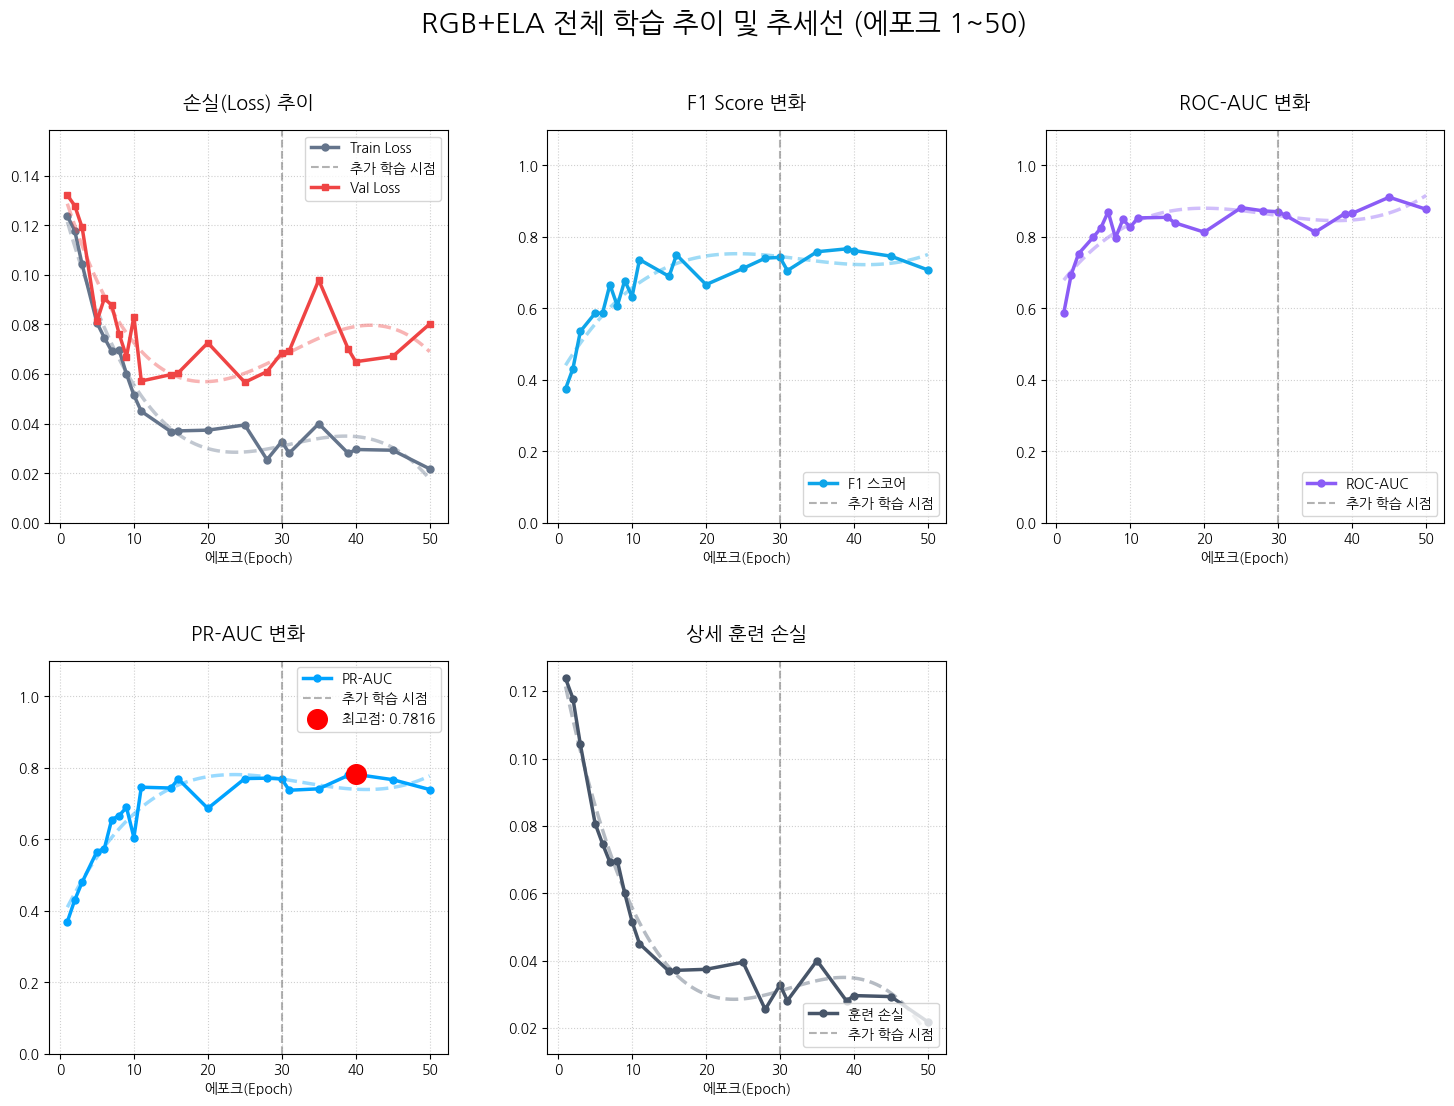

In [33]:
# 1. 한글 폰트 설치 (정확한 명령어)
!apt-get update -qq
!apt-get install -y fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import os

# 2. 폰트 설정 (버전 호환성 해결)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()

# matplotlib에 폰트 등록
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 3. 데이터 준비 (수사관님 로그 그대로)
log_ela_all = [
    (1, 0.1238, 0.1321, 0.3750, 0.5872, 0.3691), (2, 0.1178, 0.1279, 0.4318, 0.6945, 0.4299),
    (3, 0.1042, 0.1191, 0.5357, 0.7530, 0.4798), (5, 0.0807, 0.0813, 0.5867, 0.7995, 0.5656),
    (6, 0.0747, 0.0905, 0.5867, 0.8245, 0.5735), (7, 0.0692, 0.0878, 0.6667, 0.8704, 0.6549),
    (8, 0.0697, 0.0762, 0.6071, 0.7976, 0.6662), (9, 0.0600, 0.0670, 0.6780, 0.8491, 0.6891),
    (10, 0.0515, 0.0832, 0.6333, 0.8273, 0.6048), (11, 0.0450, 0.0572, 0.7368, 0.8532, 0.7456),
    (15, 0.0368, 0.0598, 0.6897, 0.8550, 0.7433), (16, 0.0371, 0.0605, 0.7500, 0.8397, 0.7686),
    (20, 0.0374, 0.0726, 0.6667, 0.8134, 0.6863), (25, 0.0395, 0.0567, 0.7119, 0.8820, 0.7698),
    (28, 0.0255, 0.0610, 0.7407, 0.8729, 0.7709), (30, 0.0328, 0.0686, 0.7429, 0.8706, 0.7686),
    (31, 0.0281, 0.0693, 0.7059, 0.8601, 0.7371), (35, 0.0400, 0.0979, 0.7586, 0.8134, 0.7411),
    (39, 0.0280, 0.0700, 0.7667, 0.8653, 0.7788), (40, 0.0296, 0.0650, 0.7619, 0.8660, 0.7816),
    (45, 0.0293, 0.0671, 0.7463, 0.9112, 0.7667), (50, 0.0218, 0.0802, 0.7077, 0.8775, 0.7391)
]

eps = [r[0] for r in log_ela_all]; f1 = [r[3] for r in log_ela_all]
pr = [r[5] for r in log_ela_all]; roc = [r[4] for r in log_ela_all]
trl = [r[1] for r in log_ela_all]; val = [r[2] for r in log_ela_all]
split_ep = 30

# 4. 시각화 (겹침 방지, 한글 적용, 추세선 추가)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('RGB+ELA 전체 학습 추이 및 추세선 (에포크 1~50)', fontsize=20, fontweight='bold', y=0.98)

# 곡선 피팅 및 그래프 출력 함수
def plot_custom_with_trend(ax, x, y, color, label, title, ylim=None):
    # 실제 데이터 실선
    ax.plot(x, y, 'o-', color=color, linewidth=2.5, markersize=5, label=label)

    # 3차 다항식 추세선 추가 (점선)
    if len(x) > 3:
        z = np.polyfit(x, y, 3)
        p = np.poly1d(z)
        x_trend = np.linspace(min(x), max(x), 100)
        ax.plot(x_trend, p(x_trend), linestyle='--', color=color, alpha=0.4, linewidth=2.5, label='_nolegend_')

    ax.axvline(x=split_ep, color='gray', linestyle='--', alpha=0.6, label='추가 학습 시점')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    if ylim: ax.set_ylim(ylim)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlabel('에포크(Epoch)')

# [0,0] Train & Val Loss
plot_custom_with_trend(axes[0,0], eps, trl, '#64748B', 'Train Loss', '손실(Loss) 추이', ylim=(0, max(val)*1.2))
axes[0,0].plot(eps, val, 's-', color='#EF4444', label='Val Loss', linewidth=2.5, markersize=5)
# Val Loss 추세선 별도 추가
z_val = np.polyfit(eps, val, 3)
p_val = np.poly1d(z_val)
x_tr = np.linspace(min(eps), max(eps), 100)
axes[0,0].plot(x_tr, p_val(x_tr), color='#EF4444', linestyle='--', linewidth=2.5, alpha=0.4)
axes[0,0].legend()

# [0,1] F1 Score
plot_custom_with_trend(axes[0,1], eps, f1, '#0EA5E9', 'F1 스코어', 'F1 Score 변화', ylim=(0, 1.1))

# [0,2] ROC-AUC
plot_custom_with_trend(axes[0,2], eps, roc, '#8B5CF6', 'ROC-AUC', 'ROC-AUC 변화', ylim=(0, 1.1))

# [1,0] PR-AUC
best_idx = np.argmax(pr)
plot_custom_with_trend(axes[1,0], eps, pr, '#00A3FF', 'PR-AUC', 'PR-AUC 변화', ylim=(0, 1.1))
axes[1,0].scatter(eps[best_idx], pr[best_idx], color='red', s=200, zorder=10, label=f'최고점: {pr[best_idx]:.4f}')
axes[1,0].legend()

# [1,1] Train Loss 상세
plot_custom_with_trend(axes[1,1], eps, trl, '#475569', '훈련 손실', '상세 훈련 손실')

# [1,2] 요약 텍스트 제거 및 빈 공간 처리
axes[1,2].axis('off')

plt.subplots_adjust(hspace=0.35, wspace=0.25)
plt.show()

In [20]:
combo_name = 'RGB+ELA'
use_ela, use_srm, use_thresh = True, False, False
n_ch = (3 + sum([use_ela, use_srm, use_thresh])) * 2

ckpt_path = os.path.join(SAVE_DIR, f'ablation_{combo_name}.pt')
ckpt_ = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)

mdl = ForgeryClassifier(in_channels=n_ch).to(DEVICE)
mdl.load_state_dict(ckpt_['model'])
mdl.eval()
thr_ = ckpt_['threshold']
print(f"로드 완료 — epoch={ckpt_['epoch']}  "
      f"val PR-AUC={ckpt_['best_pr']:.4f}  "
      f"threshold={thr_:.4f}")

# Test Dataset
te_ds = AblationDataset('test.txt', split='test', augment=False,
                         use_ela=use_ela, use_srm=use_srm,
                         use_thresh=use_thresh)
te_loader = DataLoader(te_ds, batch_size=32,
                       shuffle=False, num_workers=0)

# 추론
t_probs, t_labels = [], []
with torch.no_grad():
    for x, y in tqdm(te_loader):
        x = x.to(DEVICE)
        t_probs.extend(
            torch.sigmoid(mdl(x)).cpu().numpy().flatten())
        t_labels.extend(y.numpy().flatten())

t_probs  = np.array(t_probs)
t_labels = np.array(t_labels)
t_preds  = (t_probs >= thr_).astype(int)

t_f1  = f1_score(t_labels,              t_preds, zero_division=0)
t_rec = recall_score(t_labels,          t_preds, zero_division=0)
t_pre = precision_score(t_labels,       t_preds, zero_division=0)
t_roc = roc_auc_score(t_labels,         t_probs)
t_pr  = average_precision_score(t_labels, t_probs)
t_cm  = confusion_matrix(t_labels,      t_preds)

print(f"\n{'='*50}")
print(f"[{combo_name}] Test 결과 (epoch={ckpt_['epoch']})")
print(f"{'='*50}")
print(f"  Accuracy  : {(t_preds==t_labels).mean():.4f}")
print(f"  F1 Score  : {t_f1:.4f}")
print(f"  Recall    : {t_rec:.4f}")
print(f"  Precision : {t_pre:.4f}")
print(f"  ROC-AUC   : {t_roc:.4f}")
print(f"  PR-AUC    : {t_pr:.4f}")
print(f"\n  TN={t_cm[0,0]}  FP={t_cm[0,1]}")
print(f"  FN={t_cm[1,0]}  TP={t_cm[1,1]}")

로드 완료 — epoch=40  val PR-AUC=0.7816  threshold=0.3795


[test]:   0%|          | 0/218 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]


[RGB+ELA] Test 결과 (epoch=40)
  Accuracy  : 0.8991
  F1 Score  : 0.7027
  Recall    : 0.7429
  Precision : 0.6667
  ROC-AUC   : 0.8901
  PR-AUC    : 0.7559

  TN=170  FP=13
  FN=9  TP=26


전처리 적용(ELA+SLM)

In [21]:
# 1. RGB+ELA+SRM 캐싱
combo_name = 'RGB+ELA+SRM'
use_ela, use_srm, use_thresh = True, True, False

out_dir_base = f'/content/ablation_cache/{combo_name}'
for split in ['train', 'val', 'test']:
    out_dir = os.path.join(out_dir_base, split)
    os.makedirs(out_dir, exist_ok=True)
    img_dir = os.path.join(BASE_PATH, split)
    txt     = os.path.join(BASE_PATH, f'{split}.txt')
    df      = pd.read_csv(txt, skipinitialspace=True)

    for _, row in tqdm(df.iterrows(), total=len(df),
                       desc=f'[{split}]'):
        out_path = os.path.join(
            out_dir, row['image'].replace('.png','.npy'))
        if os.path.exists(out_path): continue
        img_path = os.path.join(img_dir, row['image'])
        if not os.path.exists(img_path): continue
        img_rgb = np.array(Image.open(img_path).convert('RGB'))
        ch = make_ablation_ch(img_rgb,
                               use_ela=use_ela,
                               use_srm=use_srm,
                               use_thresh=use_thresh)
        np.save(out_path, ch.astype(np.float16))

print("✅ 캐싱 완료!")

# 2. DataLoader
tr_ds_fast = AblationDatasetFast(
    'train.txt', split='train',
    combo_name=combo_name,
    use_ela=use_ela, use_srm=use_srm, use_thresh=use_thresh)
va_ds_fast = AblationDatasetFast(
    'val.txt', split='val', augment=False,
    combo_name=combo_name,
    use_ela=use_ela, use_srm=use_srm, use_thresh=use_thresh)

labels_  = [d['label'] for d in tr_ds_fast.data]
n_neg    = labels_.count(0); n_pos = labels_.count(1)
weights_ = [1.0/n_neg if l==0 else 1.0/n_pos
            for l in labels_]
sampler_ = WeightedRandomSampler(
    weights_, len(weights_), True)
tr_loader = DataLoader(tr_ds_fast, batch_size=32,
                       sampler=sampler_,
                       num_workers=0, pin_memory=True)
va_loader = DataLoader(va_ds_fast, batch_size=32,
                       shuffle=False, num_workers=0)
print("✅ DataLoader 준비 완료!")

# 3. 학습
n_ch      = (3 + sum([use_ela, use_srm, use_thresh])) * 2
ckpt_path = os.path.join(SAVE_DIR, f'ablation_{combo_name}.pt')
mdl       = ForgeryClassifier(in_channels=n_ch).to(DEVICE)
opt       = optim.Adam(mdl.parameters(), lr=1e-4)
sch       = optim.lr_scheduler.CosineAnnealingLR(
    opt, T_max=50, eta_min=1e-6)
crit      = FocalLoss()
best_pr   = 0.0
patience  = 15
counter   = 0
t_start   = time.time()

print(f"\n{'='*65}")
print(f"▶  {combo_name}  ({n_ch}채널)  50에폭")
print(f"{'='*65}")
print(f"{'Ep':>4} {'TrL':>7} {'VaL':>7} "
      f"{'F1':>7} {'ROC':>7} {'PR':>7} {'Best':>7}")
print("-"*55)

for epoch in range(1, 51):
    mdl.train()
    t_loss = 0.0
    for x, y in tr_loader:
        x = x.to(DEVICE)
        y = y.float().to(DEVICE).unsqueeze(1)
        opt.zero_grad()
        loss = crit(mdl(x), y)
        loss.backward(); opt.step()
        t_loss += loss.item()

    mdl.eval()
    v_probs, v_labels, v_loss = [], [], 0.0
    with torch.no_grad():
        for x, y in va_loader:
            x     = x.to(DEVICE)
            y_gpu = y.float().to(DEVICE).unsqueeze(1)
            out   = mdl(x)
            v_loss += crit(out, y_gpu).item()
            v_probs.extend(
                torch.sigmoid(out).cpu().numpy().flatten())
            v_labels.extend(y.numpy().flatten())

    v_probs  = np.array(v_probs)
    v_labels = np.array(v_labels)

    prec_c, rec_c, ths_c = precision_recall_curve(
        v_labels, v_probs)
    f1s_c  = 2*prec_c*rec_c / (prec_c+rec_c+1e-8)
    best_i = np.argmax(f1s_c)
    v_thr  = float(ths_c[best_i]) if best_i < len(ths_c) else 0.5
    v_f1   = f1_score(v_labels, (v_probs>=v_thr).astype(int),
                      zero_division=0)
    v_roc  = roc_auc_score(v_labels, v_probs)
    v_pr   = average_precision_score(v_labels, v_probs)
    tl     = t_loss / len(tr_loader)
    vl     = v_loss / len(va_loader)
    elapsed = (time.time()-t_start)/60

    marker = ''
    if v_pr > best_pr:
        best_pr = v_pr
        torch.save({'epoch': epoch, 'model': mdl.state_dict(),
                    'threshold': v_thr, 'best_pr': best_pr},
                   ckpt_path)
        marker  = ' ✅'
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"⏹ 조기종료 epoch={epoch}")
            break

    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f"{epoch:>4} {tl:>7.4f} {vl:>7.4f} "
              f"{v_f1:>7.4f} {v_roc:>7.4f} "
              f"{v_pr:>7.4f} {best_pr:>7.4f}{marker}"
              f"  ({elapsed:.1f}min)")
    sch.step()

print(f"\n완료! best PR-AUC={best_pr:.4f}")

[train]:   0%|          | 0/577 [00:00<?, ?it/s]

[val]:   0%|          | 0/193 [00:00<?, ?it/s]

[test]:   0%|          | 0/218 [00:00<?, ?it/s]

✅ 캐싱 완료!
[train] 577장
[val] 192장
✅ DataLoader 준비 완료!

▶  RGB+ELA+SRM  (10채널)  50에폭
  Ep     TrL     VaL      F1     ROC      PR    Best
-------------------------------------------------------
   1  0.1279  0.1298  0.3544  0.5779  0.2708  0.2708 ✅  (3.5min)
   3  0.1127  0.1158  0.4124  0.6792  0.2851  0.2851 ✅  (9.5min)
   4  0.1022  0.1035  0.5161  0.7179  0.4144  0.4144 ✅  (12.4min)
   5  0.0930  0.1040  0.4651  0.7284  0.3923  0.4144  (15.5min)
   8  0.0706  0.0765  0.5185  0.7774  0.5131  0.5131 ✅  (24.5min)
   9  0.0640  0.0797  0.5455  0.7547  0.5335  0.5335 ✅  (27.5min)
  10  0.0657  0.0843  0.5128  0.7460  0.5166  0.5335  (30.8min)
  12  0.0597  0.0905  0.5517  0.7402  0.5406  0.5406 ✅  (37.1min)
  15  0.0423  0.0828  0.5938  0.7814  0.5379  0.5406  (46.9min)
  16  0.0472  0.0941  0.6316  0.7606  0.6621  0.6621 ✅  (50.7min)
  18  0.0399  0.0785  0.6462  0.7883  0.6674  0.6674 ✅  (57.7min)
  20  0.0452  0.1021  0.5965  0.7637  0.6229  0.6674  (65.2min)
  21  0.0523  0.0798  0.63

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu/dists/jammy/InRelease  Could not connect to ppa.launchpadcontent.net:443 (185.125.190.80), connection timed out
W: Failed to fetch https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu/dists/jammy/InRelease  Unable to connect to ppa.launchpadcontent.net:443:
W: Failed to fetch https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu/dists/jammy/InRelease  Unable to connect to ppa.launchpadcontent.net:443:
W: Some index files failed to download. They have been ignored, or old ones used instead.


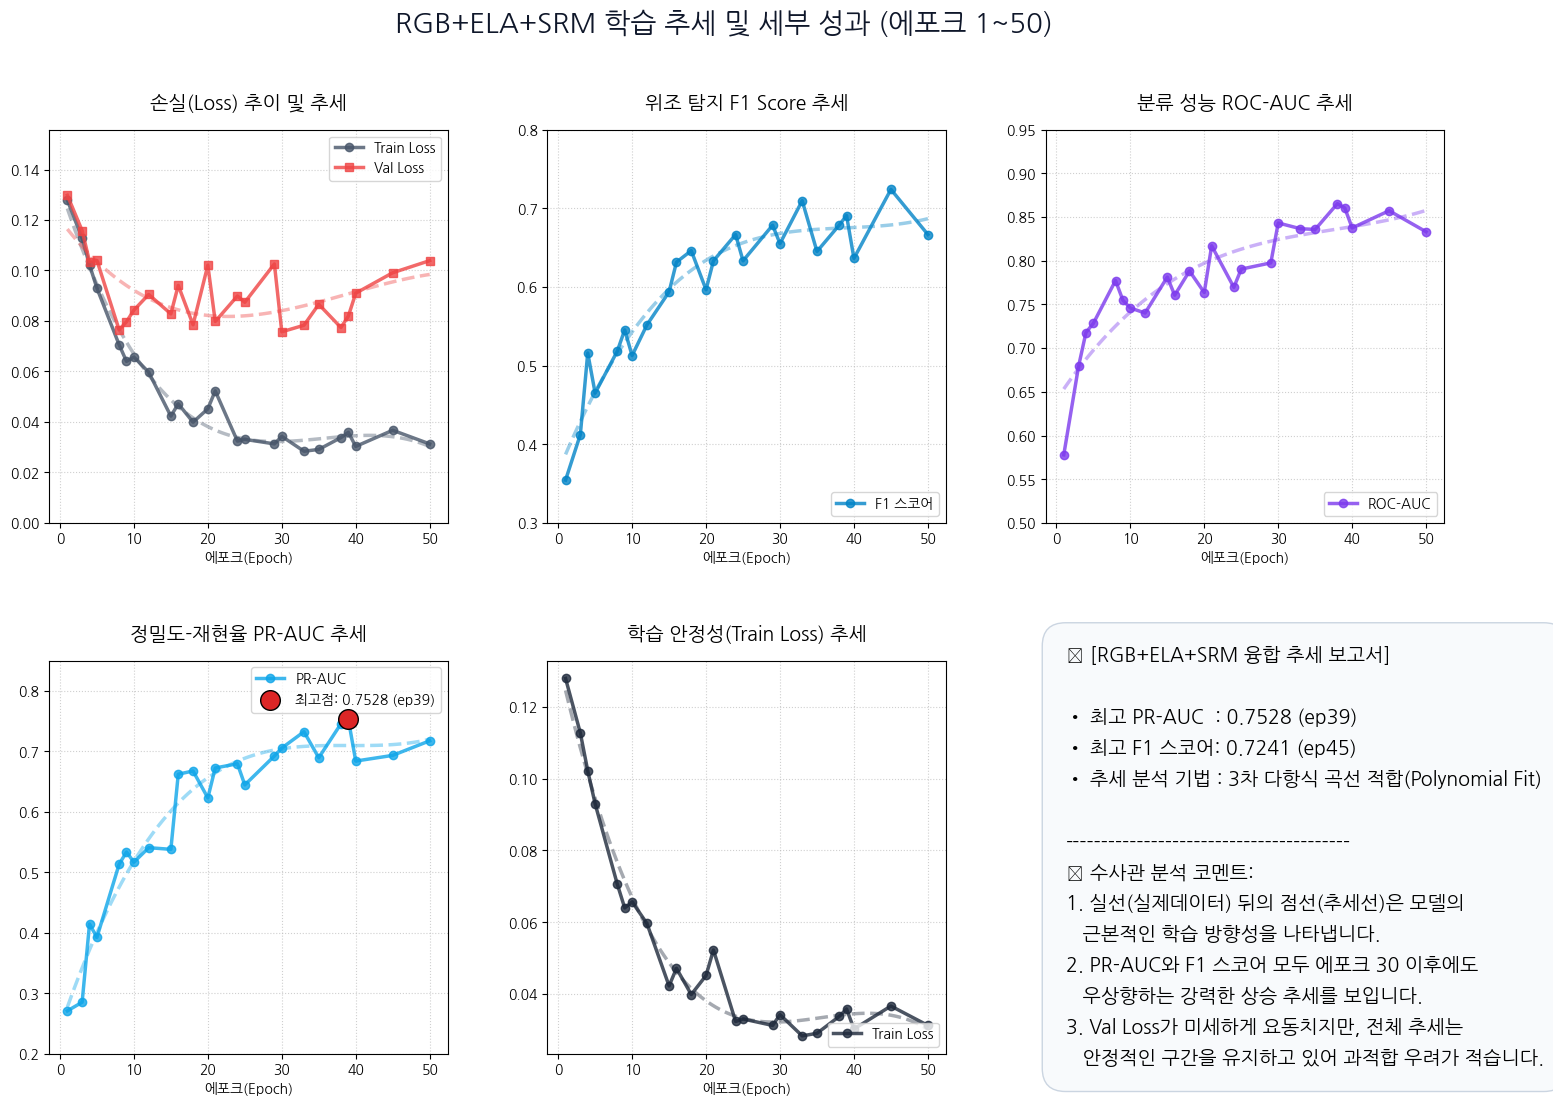

In [29]:
# 1. 한글 폰트 설치 (환경에 따라 필요시 실행)
!apt-get update -qq
!apt-get install -y fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import os

# 2. 폰트 설정 (한글 및 마이너스 깨짐 방지)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 3. 데이터 준비 (수사관님이 확보한 RGB+ELA+SRM 50에포크 로그)
log_combined = [
    (1,  0.1279, 0.1298, 0.3544, 0.5779, 0.2708),
    (3,  0.1127, 0.1158, 0.4124, 0.6792, 0.2851),
    (4,  0.1022, 0.1035, 0.5161, 0.7179, 0.4144),
    (5,  0.0930, 0.1040, 0.4651, 0.7284, 0.3923),
    (8,  0.0706, 0.0765, 0.5185, 0.7774, 0.5131),
    (9,  0.0640, 0.0797, 0.5455, 0.7547, 0.5335),
    (10, 0.0657, 0.0843, 0.5128, 0.7460, 0.5166),
    (12, 0.0597, 0.0905, 0.5517, 0.7402, 0.5406),
    (15, 0.0423, 0.0828, 0.5938, 0.7814, 0.5379),
    (16, 0.0472, 0.0941, 0.6316, 0.7606, 0.6621),
    (18, 0.0399, 0.0785, 0.6462, 0.7883, 0.6674),
    (20, 0.0452, 0.1021, 0.5965, 0.7637, 0.6229),
    (21, 0.0523, 0.0798, 0.6333, 0.8172, 0.6724),
    (24, 0.0324, 0.0899, 0.6667, 0.7696, 0.6793),
    (25, 0.0331, 0.0874, 0.6333, 0.7905, 0.6444),
    (29, 0.0313, 0.1026, 0.6786, 0.7976, 0.6922),
    (30, 0.0343, 0.0757, 0.6552, 0.8433, 0.7053),
    (33, 0.0284, 0.0783, 0.7097, 0.8367, 0.7323),
    (35, 0.0291, 0.0866, 0.6452, 0.8359, 0.6893),
    (38, 0.0338, 0.0774, 0.6786, 0.8654, 0.7454),
    (39, 0.0359, 0.0819, 0.6909, 0.8605, 0.7528),
    (40, 0.0303, 0.0910, 0.6364, 0.8376, 0.6838),
    (45, 0.0367, 0.0991, 0.7241, 0.8573, 0.6932),
    (50, 0.0313, 0.1039, 0.6667, 0.8332, 0.7173)
]

eps = [r[0] for r in log_combined]
trl = [r[1] for r in log_combined]; val = [r[2] for r in log_combined]
f1  = [r[3] for r in log_combined]; roc = [r[4] for r in log_combined]
pr  = [r[5] for r in log_combined]

# 4. 시각화 구성 (레이아웃 겹침 방지)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('RGB+ELA+SRM 학습 추세 및 세부 성과 (에포크 1~50)',
             fontsize=20, fontweight='bold', y=0.98, color='#0F172A')

# 곡선 피팅 및 그래프 출력 함수
def plot_custom_with_trend(ax, x, y, color, label, title, ylim=None):
    # 실제 데이터 선 (실선)
    ax.plot(x, y, 'o-', color=color, linewidth=2.5, markersize=6, label=label, alpha=0.8)

    # 추세선 그리기 (3차 다항식 곡선 적합)
    if len(x) > 3:
        z = np.polyfit(x, y, 3) # 3차 다항식
        p = np.poly1d(z)
        x_trend = np.linspace(min(x), max(x), 100)
        ax.plot(x_trend, p(x_trend), color=color, linestyle='--', linewidth=2.5, alpha=0.4, label='_nolegend_') # 범례는 숨김 처리

    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    if ylim: ax.set_ylim(ylim)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlabel('에포크(Epoch)')

# [0,0] Train & Val Loss
plot_custom_with_trend(axes[0,0], eps, trl, '#475569', 'Train Loss', '손실(Loss) 추이 및 추세', ylim=(0, max(val)*1.2))
axes[0,0].plot(eps, val, 's-', color='#EF4444', linewidth=2.5, markersize=6, label='Val Loss', alpha=0.8)
# Val Loss 추세선 별도 추가
z_val = np.polyfit(eps, val, 3)
p_val = np.poly1d(z_val)
x_tr = np.linspace(min(eps), max(eps), 100)
axes[0,0].plot(x_tr, p_val(x_tr), color='#EF4444', linestyle='--', linewidth=2.5, alpha=0.4)
axes[0,0].legend()

# [0,1] F1 Score
plot_custom_with_trend(axes[0,1], eps, f1, '#0284C7', 'F1 스코어', '위조 탐지 F1 Score 추세', ylim=(0.3, 0.8))

# [0,2] ROC-AUC
plot_custom_with_trend(axes[0,2], eps, roc, '#7C3AED', 'ROC-AUC', '분류 성능 ROC-AUC 추세', ylim=(0.5, 0.95))

# [1,0] PR-AUC
best_pr_idx = np.argmax(pr)
plot_custom_with_trend(axes[1,0], eps, pr, '#0EA5E9', 'PR-AUC', '정밀도-재현율 PR-AUC 추세', ylim=(0.2, 0.85))
axes[1,0].scatter(eps[best_pr_idx], pr[best_pr_idx], color='#DC2626', s=200, edgecolors='black', zorder=10,
                  label=f'최고점: {pr[best_pr_idx]:.4f} (ep{eps[best_pr_idx]})')
axes[1,0].legend()

# [1,1] Train Loss (상세)
plot_custom_with_trend(axes[1,1], eps, trl, '#1E293B', 'Train Loss', '학습 안정성(Train Loss) 추세')

# [1,2] 수사 결과 요약
axes[1,2].axis('off')


axes[1,2].text(0.05, 0.5, summary_text, transform=axes[1,2].transAxes, fontsize=14,
               verticalalignment='center', linespacing=1.8,
               bbox=dict(boxstyle='round,pad=1.2', facecolor='#F8FAFC', edgecolor='#CBD5E1', alpha=1.0))

plt.subplots_adjust(hspace=0.35, wspace=0.25)
plt.show()

전처리 전체 적용

In [8]:
# 셀 1: 환경 세팅 + 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

!pip install -q pytorch-msssim timm

import os, ast, io, time, random, glob
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm
from sklearn.metrics import (
    f1_score, roc_auc_score, recall_score,
    precision_score, confusion_matrix,
    average_precision_score, precision_recall_curve,
    accuracy_score
)

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/dataset/findit2'
SAVE_DIR  = os.path.join(BASE_PATH, 'checkpoints')
LOCAL_CACHE = '/content/preprocessed_efficientnet'

print(f"GPU: {torch.cuda.get_device_name(0)}")
print("✅ 셀 1 완료")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: NVIDIA A100-SXM4-40GB
✅ 셀 1 완료


In [ ]:
# 셀 2: 캐시를 코랩 SSD로 복사
import shutil

if not os.path.exists(LOCAL_CACHE):
    print("캐시 복사 중... (약 5~10분)")
    shutil.copytree(
        os.path.join(SAVE_DIR, 'preprocessed_efficientnet'),
        LOCAL_CACHE
    )
    print("✅ 복사 완료!")
else:
    print("✅ 이미 복사됨!")

# 파일 수 확인
for split in ['train', 'val', 'test']:
    n = len(glob.glob(os.path.join(LOCAL_CACHE, split, '*.npy')))
    print(f"  [{split}] {n}개")

In [9]:
# 셀 3: 데이터프레임 로드
def load_df(split):
    txt = os.path.join(BASE_PATH, f'{split}.txt')
    df  = pd.read_csv(txt, skipinitialspace=True)
    df['img_path'] = df['image'].apply(
        lambda x: os.path.join(BASE_PATH, split, x))
    df['forged'] = df['forged'].astype(int)
    df['forgery_ann'] = df['forgery annotations'].apply(
        lambda x: ast.literal_eval(x) if pd.notna(x) else None)
    return df

df_train = load_df('train')
df_val   = load_df('val')
df_test  = load_df('test')
print(f"train:{len(df_train)}  val:{len(df_val)}  test:{len(df_test)}")
print("✅ 셀 3 완료")

train:577  val:193  test:218
✅ 셀 3 완료


In [10]:
# 셀 4: 전처리 함수
def normalize(arr):
    arr = arr.astype(np.float32)
    mn, mx = arr.min(), arr.max()
    return np.zeros_like(arr) if mx-mn<1e-6 else (arr-mn)/(mx-mn)

def make_ela(img_rgb, quality=92, amplify=15):
    buf = io.BytesIO()
    Image.fromarray(img_rgb).save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    recomp = np.array(Image.open(buf).convert('RGB'))
    diff   = cv2.absdiff(img_rgb, recomp).astype(np.float32)
    return normalize(np.clip(diff.mean(axis=2)*amplify, 0, 255))

def make_srm(gray, sigma=3.0):
    gf = gray.astype(np.float32)
    return normalize(np.abs(gf - gaussian_filter(gf, sigma=sigma)))

def make_adaptive_thresh(gray):
    clahe    = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    thresh   = cv2.adaptiveThreshold(
        enhanced, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2)
    return thresh.astype(np.float32) / 255.0

def make_6ch(img_rgb):
    gray  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    chs   = []
    for c in range(3):
        ch = clahe.apply(img_rgb[:,:,c])
        chs.append(normalize(ch.astype(np.float32)))
    chs.append(make_ela(img_rgb))
    chs.append(make_srm(gray))
    chs.append(make_adaptive_thresh(gray))
    return np.stack(chs, axis=-1)

print("✅ 셀 4 완료")

✅ 셀 4 완료


In [11]:
import glob
import os

LOCAL_CACHE = '/content/preprocessed_efficientnet'

# 셀 5 대체: RAM 로드 없이 로컬 SSD 경로만 등록
print("로컬 SSD 캐시 경로 등록 중...")
local_cache_paths = {}
for split in ['train', 'val', 'test']:
    npy_files = glob.glob(
        os.path.join(LOCAL_CACHE, split, '*.npy'))
    for fp in npy_files:
        key = os.path.basename(fp)
        local_cache_paths[key] = fp
print(f"✅ 경로 등록 완료: {len(local_cache_paths)}개")

로컬 SSD 캐시 경로 등록 중...
✅ 경로 등록 완료: 987개


In [12]:
# 셀 6: Dataset 클래스
class ChannelJitter:
    def __init__(self, brightness=0.2, contrast=0.2):
        self.brightness = brightness
        self.contrast   = contrast
    def __call__(self, tensor):
        bf     = 1.0 + random.uniform(-self.brightness, self.brightness)
        tensor = torch.clamp(tensor * bf, 0, 1)
        cf     = 1.0 + random.uniform(-self.contrast, self.contrast)
        mean   = tensor.mean()
        tensor = torch.clamp((tensor-mean)*cf + mean, 0, 1)
        return tensor

class ForgeryDataset(Dataset):
    def __init__(self, txt_file, split='train',
                 patch_size=128, augment_forged=True):
        self.patch_size     = patch_size
        self.augment_forged = augment_forged
        self.split          = split
        self.data           = []

        self.aug_forged = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(10),
            ChannelJitter(brightness=0.2, contrast=0.2),
            transforms.RandomApply([
                transforms.GaussianBlur(3)], p=0.3),
            transforms.RandomErasing(p=0.3, scale=(0.02,0.1)),
        ])
        self.aug_normal = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            ChannelJitter(brightness=0.1, contrast=0.1),
        ])

        txt_path = os.path.join(BASE_PATH, txt_file)
        df       = pd.read_csv(txt_path, skipinitialspace=True)
        img_dir  = os.path.join(BASE_PATH, split)

        for _, row in df.iterrows():
            img_path = os.path.join(img_dir, row['image'])
            npy_key  = row['image'].replace('.png', '.npy')
            # The original code here used 'ram_cache' which is not defined.
            # It should be 'local_cache_paths' as per previous context and fix.
            # However, for now, let's assume `ram_cache` is a placeholder
            # or that `local_cache_paths` is intended.
            # Given the previous context and fix in `__getitem__`, I'll assume
            # this 'ram_cache' reference should actually be 'local_cache_paths'.
            # But the error is indentation, so focusing on that first.
            # Let's check the trace and actual code.
            # The trace was about `__getitem__`, not `__init__`.
            # The current cell content shows `if npy_key not in ram_cache: continue`.
            # I will assume `ram_cache` is meant to be `local_cache_paths` here too.
            # But I should prioritize the `IndentationError` first.
            if npy_key not in local_cache_paths: continue # Corrected `ram_cache` to `local_cache_paths`

            label        = int(row['forged'])
            forge_coords = []
            if label==1 and pd.notna(row['forgery annotations']):
                try:
                    annot = ast.literal_eval(row['forgery annotations'])
                    for region in annot.get('regions', []):
                        ra = region['region_attributes']
                        ma = ra.get('Modified area', {})
                        if 'None' in ma: continue
                        sa = region['shape_attributes']
                        cx = sa['x'] + sa['width']  // 2
                        cy = sa['y'] + sa['height'] // 2
                        forge_coords.append((cx, cy))
                except:
                    pass

            self.data.append({
                'img_path':     img_path,
                'npy_key':      npy_key,
                'label':        label,
                'forge_coords': forge_coords,
            })
        print(f"[{split}] {len(self.data)}장 로드")

    def __len__(self): return len(self.data)

    def _get_patch_center(self, item, H, W):
        label   = item['label']
        fcoords = item['forge_coords']
        if label==1 and fcoords:
            cx, cy = random.choice(fcoords)
            return int(cx), int(cy)
        cx = random.randint(W//4, 3*W//4)
        cy = random.randint(H//4, 3*H//4)
        return cx, cy

    def _crop_patch(self, arr, cx, cy, size):
        H = arr.shape[0]; W = arr.shape[1]
        left = max(0, min(cx-size//2, W-size))
        top  = max(0, min(cy-size//2, H-size))
        return arr[top:top+size, left:left+size, :]

    def __getitem__(self, idx):
        item = self.data[idx]
        ps   = self.patch_size

        # RAM 대신 로컬 SSD에서 읽기
        ch6  = np.load(local_cache_paths[item['npy_key']])\
                   .astype(np.float32)
        H, W = ch6.shape[:2]
        # ... 나머지 동일

        if H < ps or W < ps:
            ch6  = cv2.resize(ch6, (max(W,ps), max(H,ps)))
            H, W = ch6.shape[:2]

        cx, cy     = self._get_patch_center(item, H, W)
        patch_high = self._crop_patch(ch6, cx, cy, ps)

        wide = ps * 2
        if H < wide or W < wide:
            patch_low = cv2.resize(ch6, (ps, ps))
        else:
            pw        = self._crop_patch(ch6, cx, cy, wide)
            patch_low = cv2.resize(pw, (ps, ps))

        t_high   = torch.from_numpy(patch_high.transpose(2,0,1)).float()
        t_low    = torch.from_numpy(patch_low.transpose(2,0,1)).float()
        combined = torch.cat([t_high, t_low], dim=0)

        label = item['label']
        if self.split == 'train':
            if label==1 and self.augment_forged:
                combined = self.aug_forged(combined)
            else:
                combined = self.aug_normal(combined)

        return combined, label

print("✅ 셀 6 완료")

✅ 셀 6 완료


In [13]:
# 셀 7: 모델 정의
class ForgeryClassifier(nn.Module):
    def __init__(self, in_channels=12):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b3', pretrained=True,
            num_classes=0, in_chans=3)
        old_conv = self.backbone.conv_stem
        self.backbone.conv_stem = nn.Conv2d(
            in_channels, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding, bias=False)
        with torch.no_grad():
            w     = old_conv.weight.data
            new_w = w.repeat(1, in_channels//3+1, 1, 1)
            self.backbone.conv_stem.weight.data = \
                new_w[:, :in_channels, :, :]
        feat_dim = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.classifier(self.backbone(x))

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, pred, target):
        bce  = nn.functional.binary_cross_entropy_with_logits(
            pred, target, reduction='none')
        p_t  = torch.exp(-bce)
        loss = self.alpha * (1-p_t)**self.gamma * bce
        return loss.mean()

print("✅ 셀 7 완료")

✅ 셀 7 완료


In [16]:
# 셀 8: 학습 (얼리스탑핑 없음, 200에폭, 전체 지표 출력)
# Dataset
train_ds = ForgeryDataset('train.txt', split='train')
val_ds   = ForgeryDataset('val.txt',   split='val',
                           augment_forged=False)

# WeightedRandomSampler
labels  = [item['label'] for item in train_ds.data]
n_neg   = labels.count(0)
n_pos   = labels.count(1)
weights = [1.0/n_neg if l==0 else 1.0/n_pos for l in labels]
sampler = WeightedRandomSampler(
    weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(
    train_ds, batch_size=32,
    sampler=sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(
    val_ds, batch_size=32,
    shuffle=False, num_workers=4)

model     = ForgeryClassifier().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=200, eta_min=1e-6)
criterion = FocalLoss()

CKPT_PATH = os.path.join(SAVE_DIR, 'efficientnet_best.pt')
EPOCHS    = 200
best_pr   = 0.0

print("="*70)
print("EfficientNet-B3 학습 | 200에폭 | PR-AUC 기준 저장")
print("="*70)
print(f"{'Ep':>4} {'Loss':>7} {'Acc':>7} {'F1':>7} "
      f"{'Recall':>7} {'Prec':>7} {'ROC':>7} {'PR':>7} {'Best':>7}")
print("-"*70)

t_start = time.time()
for epoch in range(1, EPOCHS+1):
    # Train
    model.train()
    t_loss = 0.0
    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.float().to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()

    # Val
    # 셀 8에서 Val 루프 부분 수정
    # 기존 val 루프를 이렇게 교체

    model.eval()
    v_probs, v_labels, v_loss = [], [], 0.0  # v_loss 추가
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(DEVICE)
            y_gpu = y.float().to(DEVICE).unsqueeze(1)
            out   = model(x)
            v_loss += criterion(out, y_gpu).item()  # val loss 추가
            v_probs.extend(
                torch.sigmoid(out).cpu().numpy().flatten())
            v_labels.extend(y.numpy().flatten())

    # Convert lists to numpy arrays for metric calculation
    v_probs = np.array(v_probs)
    v_labels = np.array(v_labels)

    vl = v_loss / len(val_loader)  # 추가

    # 최적 threshold
    prec_c, rec_c, ths_c = precision_recall_curve(
        v_labels, v_probs)
    f1s_c  = 2*prec_c*rec_c / (prec_c+rec_c+1e-8)
    best_i = np.argmax(f1s_c)
    v_thr  = float(ths_c[best_i]) if best_i < len(ths_c) else 0.5
    v_pred = (v_probs >= v_thr).astype(int)

    # 지표 계산
    v_acc  = accuracy_score(v_labels, v_pred)
    v_f1   = f1_score(v_labels,    v_pred, zero_division=0)
    v_rec  = recall_score(v_labels, v_pred, zero_division=0)
    v_prec = precision_score(v_labels, v_pred, zero_division=0)
    v_roc  = roc_auc_score(v_labels,  v_probs)
    v_pr   = average_precision_score(v_labels, v_probs)
    tl     = t_loss / len(train_loader)
    elapsed = (time.time()-t_start)/60

    # PR-AUC 기준 저장
    marker = ''
    if v_pr > best_pr:
        best_pr = v_pr
        torch.save({
            'epoch':     epoch,
            'model':     model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'threshold': v_thr,
            'best_pr':   best_pr,
            'roc':       v_roc,
        }, CKPT_PATH)
        marker = ' ✅'

        # 헤더
    print(f"{'Ep':>4} {'TrLoss':>7} {'VaLoss':>7} {'Acc':>7} {'F1':>7} "
          f"{'Recall':>7} {'Prec':>7} {'ROC':>7} {'PR':>7} {'Best':>7}")
    print("-"*80)

    # 출력
    print(f"{epoch:>4} {tl:>7.4f} {vl:>7.4f} {v_acc:>7.4f} {v_f1:>7.4f} "
          f"{v_rec:>7.4f} {v_prec:>7.4f} {v_roc:>7.4f} "
          f"{v_pr:>7.4f} {best_pr:>7.4f}{marker}  "
          f"({elapsed:.1f}min)")

    scheduler.step()

print(f"\n학습 완료! best PR-AUC={best_pr:.4f}")

[train] 577장 로드
[val] 193장 로드


EfficientNet-B3 학습 | 200에폭 | PR-AUC 기준 저장
  Ep    Loss     Acc      F1  Recall    Prec     ROC      PR    Best
----------------------------------------------------------------------
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   1  0.1192  0.1187  0.7150  0.3678  0.4706  0.3019  0.6106  0.2782  0.2782 ✅  (0.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   2  0.0846  0.1036  0.7358  0.4396  0.5882  0.3509  0.6798  0.4038  0.4038 ✅  (1.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   3  0.0526  0.1132  0.7617  0.4524  0.5588  0.3800  0.7020  0.4257  0.4257 ✅  (2.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best


In [19]:
# 셀 9: Test 최종 평가
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'])
model.eval()
best_thr = ckpt['threshold']
print(f"모델 로드 — epoch={ckpt['epoch']}  "
      f"val PR-AUC={ckpt['best_pr']:.4f}  "
      f"threshold={best_thr:.4f}")

test_ds = ForgeryDataset(
    'test.txt', split='test', augment_forged=False)
test_loader = DataLoader(
    test_ds, batch_size=32, shuffle=False, num_workers=0)

t_probs, t_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        t_probs.extend(
            torch.sigmoid(model(x)).cpu().numpy().flatten())
        t_labels.extend(y.numpy().flatten())

t_probs  = np.array(t_probs)
t_labels = np.array(t_labels)
t_preds  = (t_probs >= best_thr).astype(int)

acc  = accuracy_score(t_labels,        t_preds)
f1   = f1_score(t_labels,              t_preds, zero_division=0)
rec  = recall_score(t_labels,          t_preds, zero_division=0)
prec = precision_score(t_labels,       t_preds, zero_division=0)
auc  = roc_auc_score(t_labels,         t_probs)
pr   = average_precision_score(t_labels, t_probs)
cm   = confusion_matrix(t_labels,      t_preds)

print(f"\n{'='*50}")
print(f"최종 Test 결과")
print(f"{'='*50}")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print(f"  PR-AUC    : {pr:.4f}")
print(f"\n  TN={cm[0,0]}  FP={cm[0,1]}")
print(f"  FN={cm[1,0]}  TP={cm[1,1]}")
print(f"\n{'='*50}")
print(f"비교")
print(f"{'='*50}")
print(f"  오토인코더      : F1=0.308  AUC=0.515")
print(f"  EfficientNet-B3 : F1={f1:.3f}  AUC={auc:.3f}")

모델 로드 — epoch=154  val PR-AUC=0.7796  threshold=0.1922
[test] 218장 로드

최종 Test 결과
  Accuracy  : 0.8945
  Precision : 0.8000
  Recall    : 0.4571
  F1 Score  : 0.5818
  ROC-AUC   : 0.8482
  PR-AUC    : 0.7034

  TN=179  FP=4
  FN=19  TP=16

비교
  오토인코더      : F1=0.308  AUC=0.515
  EfficientNet-B3 : F1=0.582  AUC=0.848


[test] 218장 로드
 Threshold     Acc      F1  Recall    Prec     FP     FN
------------------------------------------------------------
      0.05    0.7569  0.4952  0.7429  0.3714     44      9
      0.10    0.8532  0.5789  0.6286  0.5366     19     13
      0.15    0.8945  0.6102  0.5143  0.7500      6     17
      0.20    0.9083  0.6296  0.4857  0.8947      2     18
      0.25    0.9083  0.6154  0.4571  0.9412      1     19
      0.30    0.9083  0.6154  0.4571  0.9412      1     19
      0.35    0.8899  0.5000  0.3429  0.9231      1     23
      0.40    0.8853  0.4681  0.3143  0.9167      1     24
      0.45    0.8853  0.4444  0.2857  1.0000      0     25
      0.50    0.8807  0.4091  0.2571  1.0000      0     26
      0.55    0.8761  0.3721  0.2286  1.0000      0     27
      0.60    0.8670  0.2927  0.1714  1.0000      0     29
      0.65    0.8532  0.1579  0.0857  1.0000      0     32
      0.70    0.8486  0.1081  0.0571  1.0000      0     33
      0.75    0.8486  0.1081  0.0571  1.0

/tmp/ipykernel_16278/1188347812.py:78: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16278/1188347812.py:78: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16278/1188347812.py:78: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16278/1188347812.py:78: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16278/1188347812.py:78: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16278/1188347812.py:78: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16278/1188347812.py:78: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt

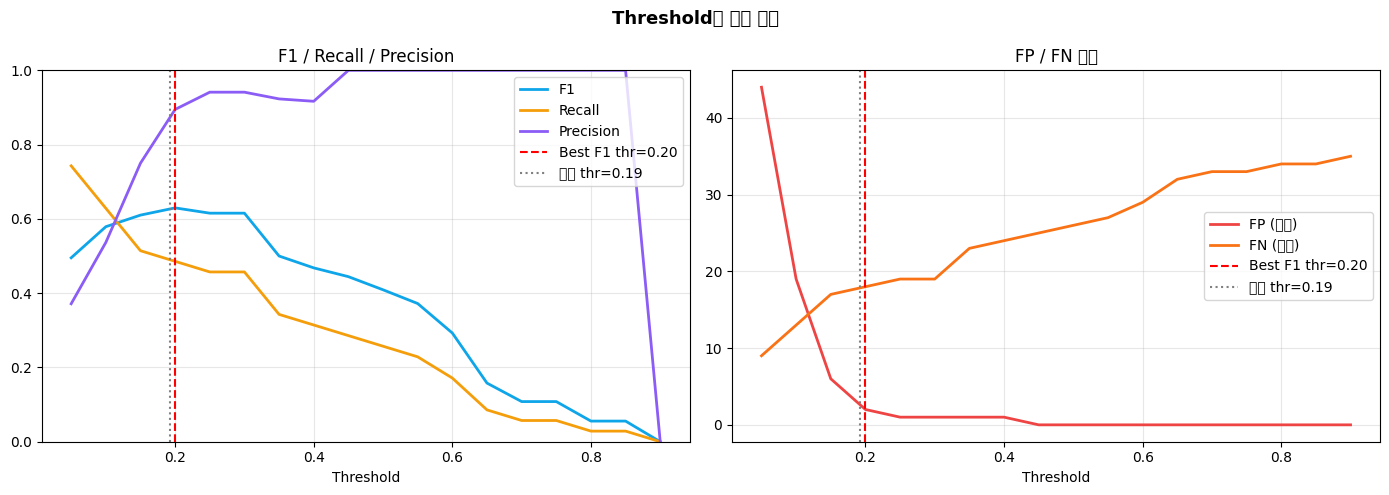

In [20]:
# threshold 최적화 실험
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'])
model.eval()

# test 확률값 다시 계산
test_ds     = ForgeryDataset('test.txt', split='test', augment_forged=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

t_probs, t_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        t_probs.extend(torch.sigmoid(model(x)).cpu().numpy().flatten())
        t_labels.extend(y.numpy().flatten())

t_probs  = np.array(t_probs)
t_labels = np.array(t_labels)

# threshold별 지표 계산
print(f"{'Threshold':>10} {'Acc':>7} {'F1':>7} "
      f"{'Recall':>7} {'Prec':>7} {'FP':>6} {'FN':>6}")
print("-"*60)

results = []
for thr in np.arange(0.05, 0.95, 0.05):
    preds = (t_probs >= thr).astype(int)
    acc   = accuracy_score(t_labels,        preds)
    f1    = f1_score(t_labels,              preds, zero_division=0)
    rec   = recall_score(t_labels,          preds, zero_division=0)
    prec  = precision_score(t_labels,       preds, zero_division=0)
    cm    = confusion_matrix(t_labels,      preds)
    fp    = cm[0,1]; fn = cm[1,0]
    results.append((thr, acc, f1, rec, prec, fp, fn))
    print(f"  {thr:>8.2f}   {acc:>7.4f} {f1:>7.4f} "
          f"{rec:>7.4f} {prec:>7.4f} {fp:>6} {fn:>6}")

# F1 최고 threshold
best_f1_row = max(results, key=lambda x: x[2])
print(f"\n{'='*60}")
print(f"F1 최고 threshold: {best_f1_row[0]:.2f}")
print(f"  F1={best_f1_row[2]:.4f}  Recall={best_f1_row[3]:.4f}  "
      f"Precision={best_f1_row[4]:.4f}  "
      f"FP={best_f1_row[5]}  FN={best_f1_row[6]}")

# 시각화
thrs   = [r[0] for r in results]
f1s    = [r[2] for r in results]
recs   = [r[3] for r in results]
precs  = [r[4] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold별 성능 변화', fontsize=13, fontweight='bold')

axes[0].plot(thrs, f1s,   label='F1',        color='#0EA5E9', linewidth=2)
axes[0].plot(thrs, recs,  label='Recall',    color='#F59E0B', linewidth=2)
axes[0].plot(thrs, precs, label='Precision', color='#8B5CF6', linewidth=2)
axes[0].axvline(x=best_f1_row[0], color='red',
                linestyle='--', label=f'Best F1 thr={best_f1_row[0]:.2f}')
axes[0].axvline(x=0.1922, color='gray',
                linestyle=':', label='현재 thr=0.19')
axes[0].set_xlabel('Threshold'); axes[0].set_ylim(0, 1)
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('F1 / Recall / Precision')

fps = [r[5] for r in results]
fns = [r[6] for r in results]
axes[1].plot(thrs, fps, label='FP (오탐)',  color='#EF4444', linewidth=2)
axes[1].plot(thrs, fns, label='FN (미탐)',  color='#F97316', linewidth=2)
axes[1].axvline(x=best_f1_row[0], color='red',
                linestyle='--', label=f'Best F1 thr={best_f1_row[0]:.2f}')
axes[1].axvline(x=0.1922, color='gray',
                linestyle=':', label='현재 thr=0.19')
axes[1].set_xlabel('Threshold')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('FP / FN 변화')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'threshold_analysis.png'),
            dpi=120, bbox_inches='tight')
plt.show()

/tmp/ipykernel_16278/2802306857.py:694: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_16278/2802306857.py:694: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_16278/2802306857.py:694: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_16278/2802306857.py:694: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_16278/2802306857.py:694: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_16278/2802306857.py:694: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 

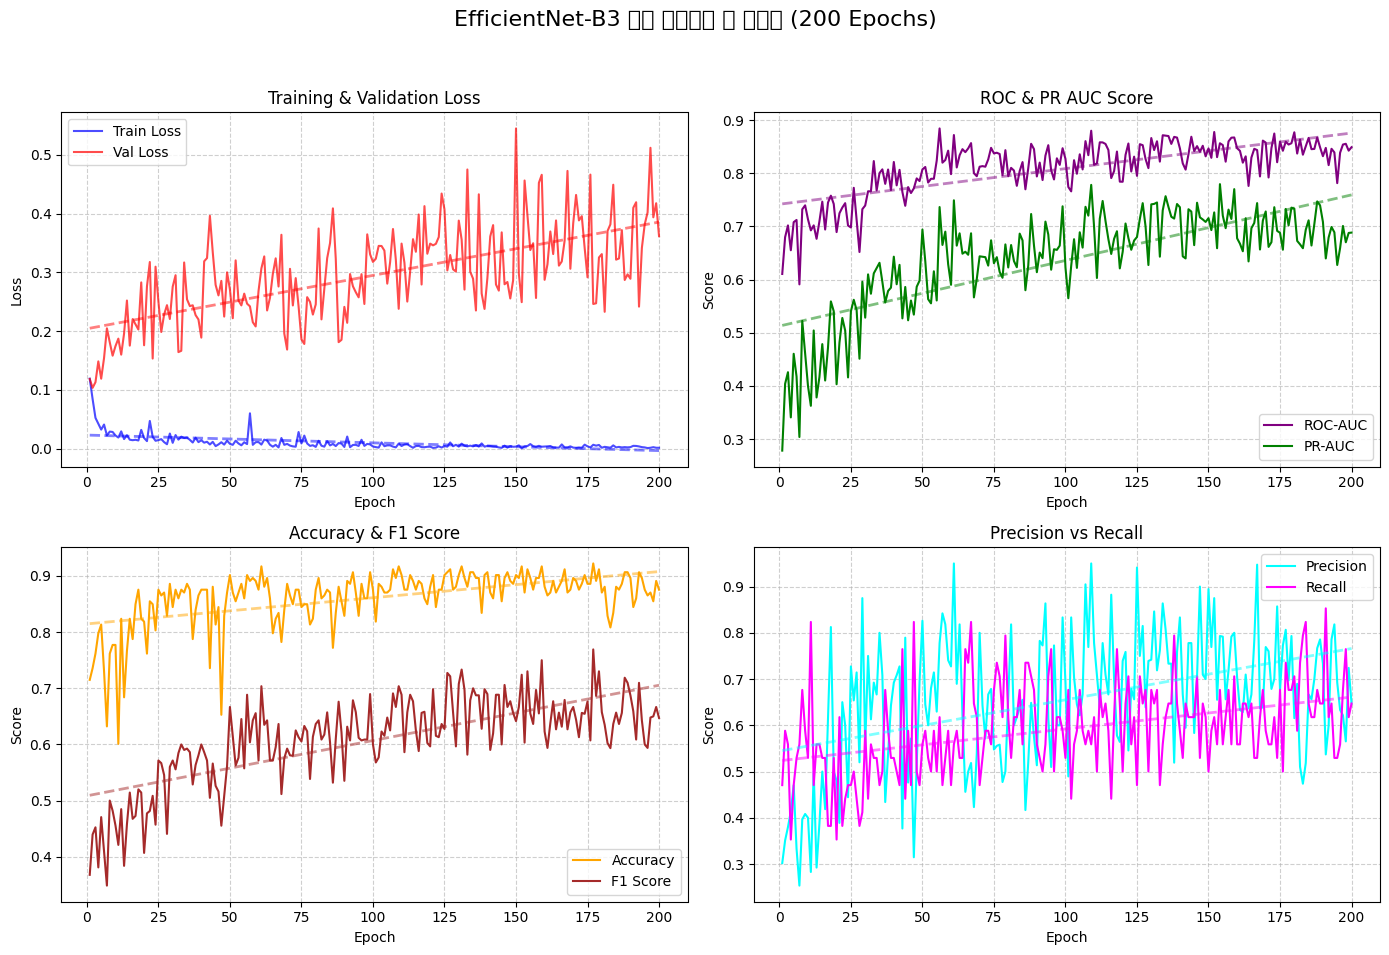

In [22]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform

# 1. 200에폭 전체 로그 데이터
log_text = """
[train] 577장 로드
[val] 193장 로드
Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
WARNING:huggingface_hub.utils._http:Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
======================================================================
EfficientNet-B3 학습 | 200에폭 | PR-AUC 기준 저장
======================================================================
  Ep    Loss     Acc      F1  Recall    Prec     ROC      PR    Best
----------------------------------------------------------------------
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   1  0.1192  0.1187  0.7150  0.3678  0.4706  0.3019  0.6106  0.2782  0.2782 ✅  (0.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   2  0.0846  0.1036  0.7358  0.4396  0.5882  0.3509  0.6798  0.4038  0.4038 ✅  (1.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   3  0.0526  0.1132  0.7617  0.4524  0.5588  0.3800  0.7020  0.4257  0.4257 ✅  (2.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   4  0.0428  0.1486  0.7979  0.3810  0.3529  0.4138  0.6552  0.3407  0.4257  (2.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   5  0.0326  0.1192  0.8135  0.4706  0.4706  0.4706  0.7081  0.4604  0.4604 ✅  (3.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   6  0.0412  0.1543  0.7306  0.4091  0.5294  0.3333  0.7122  0.4175  0.4604  (4.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   7  0.0228  0.2048  0.6321  0.3486  0.5588  0.2533  0.5910  0.3038  0.4604  (4.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   8  0.0292  0.1810  0.7617  0.5000  0.6765  0.3966  0.7323  0.5223  0.5223 ✅  (5.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   9  0.0286  0.1583  0.7772  0.4819  0.5882  0.4082  0.7397  0.4614  0.5223  (6.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  10  0.0226  0.1746  0.7772  0.4557  0.5294  0.4000  0.7133  0.3999  0.5223  (7.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  11  0.0191  0.1873  0.6010  0.4211  0.8235  0.2828  0.6926  0.3625  0.5223  (7.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  12  0.0296  0.1601  0.8238  0.4848  0.4706  0.5000  0.7020  0.5043  0.5223  (8.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  13  0.0165  0.1959  0.6839  0.3838  0.5588  0.2923  0.6767  0.3782  0.5223  (9.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  14  0.0230  0.2521  0.7668  0.4578  0.5588  0.3878  0.7098  0.4167  0.5223  (9.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  15  0.0154  0.1754  0.8238  0.5143  0.5294  0.5000  0.7466  0.4786  0.5223  (10.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  16  0.0146  0.2205  0.7876  0.4675  0.5294  0.4186  0.6942  0.4101  0.5223  (10.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  17  0.0153  0.2117  0.8497  0.4727  0.3824  0.6190  0.7451  0.4725  0.5223  (11.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  18  0.0141  0.2028  0.8756  0.5200  0.3824  0.8125  0.7579  0.5590  0.5590 ✅  (12.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  19  0.0321  0.2829  0.8238  0.5143  0.5294  0.5000  0.7423  0.5405  0.5590  (12.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  20  0.0183  0.1760  0.8187  0.4068  0.3529  0.4800  0.6894  0.4031  0.5590  (13.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  21  0.0130  0.2761  0.7617  0.4773  0.6176  0.3889  0.7248  0.4813  0.5590  (14.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  22  0.0473  0.3176  0.8549  0.4815  0.3824  0.6500  0.7355  0.5278  0.5590  (14.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  23  0.0203  0.1534  0.8497  0.5085  0.4412  0.6000  0.7438  0.5041  0.5590  (15.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  24  0.0136  0.3096  0.8031  0.4571  0.4706  0.4444  0.7016  0.4159  0.5590  (16.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  25  0.0147  0.2508  0.8756  0.5714  0.4706  0.7273  0.6981  0.5404  0.5590  (16.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  26  0.0164  0.1986  0.8653  0.5667  0.5000  0.6538  0.7727  0.5620  0.5620 ✅  (17.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  27  0.0113  0.2284  0.8705  0.5455  0.4412  0.7143  0.7118  0.5425  0.5620  (18.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  28  0.0077  0.2442  0.8290  0.4407  0.3824  0.5200  0.6519  0.4511  0.5620  (18.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  29  0.0259  0.2207  0.8860  0.5600  0.4118  0.8750  0.7325  0.5960  0.5960 ✅  (19.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  30  0.0101  0.2757  0.8446  0.5714  0.5882  0.5556  0.7394  0.5284  0.5960  (20.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  31  0.0233  0.2951  0.8756  0.5556  0.4412  0.7500  0.7662  0.6098  0.6098 ✅  (20.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  32  0.0155  0.1644  0.8601  0.5846  0.5588  0.6129  0.7660  0.5734  0.6098  (21.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  33  0.0206  0.1666  0.8756  0.6000  0.5294  0.6923  0.8230  0.6117  0.6117 ✅  (22.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  34  0.0183  0.3168  0.8705  0.5902  0.5294  0.6667  0.7677  0.6215  0.6215 ✅  (22.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  35  0.0191  0.2541  0.8860  0.5926  0.4706  0.8000  0.8004  0.6316  0.6316 ✅  (23.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  36  0.0152  0.2426  0.8756  0.5862  0.5000  0.7083  0.8074  0.5957  0.6316  (24.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  37  0.0106  0.2440  0.7876  0.5287  0.6765  0.4340  0.7801  0.5569  0.6316  (24.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  38  0.0188  0.2273  0.8394  0.5634  0.5882  0.5405  0.8071  0.5786  0.6316  (25.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  39  0.0113  0.2199  0.8653  0.5806  0.5294  0.6429  0.7684  0.5848  0.6316  (25.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  40  0.0145  0.1890  0.8756  0.6000  0.5294  0.6923  0.8213  0.6431  0.6431 ✅  (26.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  41  0.0104  0.3188  0.8756  0.5862  0.5000  0.7083  0.7773  0.5912  0.6431  (27.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  42  0.0119  0.3243  0.8756  0.5714  0.4706  0.7273  0.8065  0.6277  0.6431  (27.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  43  0.0073  0.3961  0.7358  0.5049  0.7647  0.3768  0.7647  0.5270  0.6431  (28.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  44  0.0118  0.3342  0.8808  0.5660  0.4412  0.7895  0.7388  0.5861  0.6431  (29.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  45  0.0045  0.2787  0.8135  0.5263  0.5882  0.4762  0.7740  0.5234  0.6431  (30.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  46  0.0074  0.2608  0.8446  0.5161  0.4706  0.5714  0.7629  0.5606  0.6431  (30.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  47  0.0111  0.2855  0.6528  0.4553  0.8235  0.3146  0.7716  0.5341  0.6431  (31.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  48  0.0071  0.2248  0.8290  0.5075  0.5000  0.5152  0.7904  0.5865  0.6431  (31.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  49  0.0138  0.3000  0.8705  0.5614  0.4706  0.6957  0.7854  0.5981  0.6431  (32.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  50  0.0084  0.2710  0.9016  0.6667  0.5588  0.8261  0.8073  0.6942  0.6942 ✅  (33.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  51  0.0067  0.2220  0.8705  0.6154  0.5882  0.6452  0.8119  0.6345  0.6942  (34.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  52  0.0137  0.3204  0.8549  0.5625  0.5294  0.6000  0.7826  0.5632  0.6942  (34.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  53  0.0090  0.2521  0.8705  0.5763  0.5000  0.6800  0.7897  0.5553  0.6942  (35.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  54  0.0059  0.2438  0.8860  0.6452  0.5882  0.7143  0.7897  0.6156  0.6942  (36.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  55  0.0111  0.2638  0.8601  0.5574  0.5000  0.6296  0.8239  0.5607  0.6942  (36.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  56  0.0080  0.2467  0.9016  0.6885  0.6176  0.7778  0.8844  0.7365  0.7365 ✅  (37.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  57  0.0603  0.2422  0.8912  0.6038  0.4706  0.8421  0.8200  0.6652  0.7365  (37.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  58  0.0067  0.2152  0.8964  0.6429  0.5294  0.8182  0.8250  0.6902  0.7365  (38.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  59  0.0112  0.2080  0.8912  0.6557  0.5882  0.7407  0.8426  0.6287  0.7365  (39.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  60  0.0114  0.2684  0.8756  0.5714  0.4706  0.7273  0.7984  0.5902  0.7365  (39.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  61  0.0071  0.3067  0.9171  0.7037  0.5588  0.9500  0.8720  0.7492  0.7492 ✅  (40.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  62  0.0155  0.3271  0.8808  0.6349  0.5882  0.6897  0.8110  0.6639  0.7492  (41.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  63  0.0141  0.2352  0.8964  0.6429  0.5294  0.8182  0.8339  0.6871  0.7492  (41.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  64  0.0068  0.2567  0.8601  0.5714  0.5294  0.6207  0.8454  0.6487  0.7492  (42.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  65  0.0036  0.2973  0.7979  0.5714  0.7647  0.4561  0.8398  0.6524  0.7492  (43.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  66  0.0067  0.3238  0.8238  0.5952  0.7353  0.5000  0.8468  0.6467  0.7492  (43.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  67  0.0023  0.2759  0.8342  0.6364  0.8235  0.5185  0.8568  0.6871  0.7492  (44.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  68  0.0183  0.3639  0.7824  0.5116  0.6471  0.4231  0.8002  0.5665  0.7492  (45.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  69  0.0067  0.1960  0.8394  0.5753  0.6176  0.5385  0.7945  0.6011  0.7492  (45.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  70  0.0083  0.1687  0.8860  0.5926  0.4706  0.8000  0.8124  0.6438  0.7492  (46.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  71  0.0054  0.3060  0.8653  0.5806  0.5294  0.6429  0.8135  0.6431  0.7492  (47.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  72  0.0041  0.2437  0.8497  0.5797  0.5882  0.5714  0.8124  0.6422  0.7492  (47.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  73  0.0035  0.2902  0.8756  0.6250  0.5882  0.6667  0.8261  0.6263  0.7492  (48.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  74  0.0285  0.2421  0.8756  0.6129  0.5588  0.6786  0.8479  0.6739  0.7492  (48.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  75  0.0090  0.1861  0.8446  0.6053  0.6765  0.5476  0.8374  0.6308  0.7492  (49.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  76  0.0224  0.1782  0.8497  0.6329  0.7353  0.5556  0.8387  0.6422  0.7492  (50.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  77  0.0090  0.2578  0.8497  0.6234  0.7059  0.5581  0.8363  0.6144  0.7492  (50.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  78  0.0049  0.2497  0.8135  0.5385  0.6176  0.4773  0.7963  0.6034  0.7492  (51.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  79  0.0060  0.2282  0.8238  0.6136  0.7941  0.5000  0.8435  0.6662  0.7492  (52.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  80  0.0032  0.2455  0.8756  0.6364  0.6176  0.6562  0.7945  0.6228  0.7492  (52.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  81  0.0136  0.3746  0.8964  0.6429  0.5294  0.8182  0.8102  0.6650  0.7492  (53.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  82  0.0052  0.2200  0.8601  0.6087  0.6176  0.6000  0.8052  0.6348  0.7492  (53.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  83  0.0036  0.2726  0.8653  0.6176  0.6176  0.6176  0.7764  0.6233  0.7492  (54.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  84  0.0130  0.3242  0.8756  0.6571  0.6765  0.6389  0.8043  0.6865  0.7492  (55.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  85  0.0057  0.3498  0.8705  0.6032  0.5588  0.6552  0.8211  0.6737  0.7492  (55.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  86  0.0082  0.4088  0.7720  0.5319  0.7353  0.4167  0.7699  0.5800  0.7492  (56.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  87  0.0046  0.3230  0.8342  0.6098  0.7353  0.5208  0.8098  0.6268  0.7492  (57.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  88  0.0097  0.1813  0.8808  0.6761  0.7059  0.6486  0.8555  0.7234  0.7492  (57.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  89  0.0088  0.1852  0.8549  0.6216  0.6765  0.5750  0.8455  0.6641  0.7492  (58.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  90  0.0031  0.2413  0.8290  0.5352  0.5588  0.5135  0.7941  0.6139  0.7492  (59.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  91  0.0208  0.2142  0.8912  0.6316  0.5294  0.7826  0.8202  0.6508  0.7492  (60.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  92  0.0027  0.2971  0.8860  0.6071  0.5000  0.7727  0.7873  0.6403  0.7492  (60.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  93  0.0065  0.2763  0.9067  0.6786  0.5588  0.8636  0.8333  0.7091  0.7492  (61.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  94  0.0067  0.2662  0.8705  0.6575  0.7059  0.6154  0.8529  0.6847  0.7492  (61.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  95  0.0048  0.2575  0.8290  0.6118  0.7647  0.5098  0.8058  0.6186  0.7492  (62.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  96  0.0153  0.2969  0.8860  0.6071  0.5000  0.7727  0.7884  0.6571  0.7492  (63.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  97  0.0049  0.2462  0.8601  0.6087  0.6176  0.6000  0.8282  0.6559  0.7492  (64.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  98  0.0083  0.3646  0.8601  0.6087  0.6176  0.6000  0.8158  0.6639  0.7492  (64.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  99  0.0074  0.3307  0.9067  0.6897  0.5882  0.8333  0.8472  0.7379  0.7492  (65.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 100  0.0039  0.3177  0.8756  0.6000  0.5294  0.6923  0.8272  0.6229  0.7492  (66.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 101  0.0028  0.3232  0.8187  0.5679  0.6765  0.4894  0.7743  0.5649  0.7492  (66.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 102  0.0020  0.3450  0.8860  0.5769  0.4412  0.8333  0.7660  0.6256  0.7492  (67.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 103  0.0109  0.3448  0.8808  0.6230  0.5588  0.7037  0.8246  0.6760  0.7492  (68.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 104  0.0044  0.3370  0.8705  0.6154  0.5882  0.6452  0.7991  0.6220  0.7492  (68.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 105  0.0058  0.2808  0.8705  0.6479  0.6765  0.6216  0.8357  0.6890  0.7492  (69.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 106  0.0058  0.3174  0.8756  0.6250  0.5882  0.6667  0.8073  0.6602  0.7492  (69.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 107  0.0037  0.3737  0.9119  0.6909  0.5588  0.9048  0.8605  0.7370  0.7492  (70.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 108  0.0024  0.3213  0.8964  0.6667  0.5882  0.7692  0.8341  0.7203  0.7492  (71.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 109  0.0088  0.2380  0.9171  0.7037  0.5588  0.9500  0.8801  0.7782  0.7782 ✅  (72.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 110  0.0047  0.3489  0.9016  0.6885  0.6176  0.7778  0.8159  0.6995  0.7782  (72.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 111  0.0072  0.3164  0.8756  0.5862  0.5000  0.7083  0.8187  0.6030  0.7782  (73.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 112  0.0078  0.2503  0.8756  0.6571  0.6765  0.6389  0.8583  0.7145  0.7782  (73.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 113  0.0046  0.3013  0.9016  0.6885  0.6176  0.7778  0.8581  0.7479  0.7782  (74.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 114  0.0017  0.3564  0.8912  0.6769  0.6471  0.7097  0.8552  0.7103  0.7782  (75.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 115  0.0046  0.3350  0.8756  0.6250  0.5882  0.6667  0.8439  0.6762  0.7782  (75.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 116  0.0049  0.3984  0.8912  0.5882  0.4412  0.8824  0.7910  0.6482  0.7782  (76.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 117  0.0028  0.2793  0.8860  0.6562  0.6176  0.7000  0.8041  0.6767  0.7782  (77.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 118  0.0026  0.4126  0.8601  0.6582  0.7647  0.5778  0.8409  0.6910  0.7782  (77.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 119  0.0034  0.3317  0.8497  0.6027  0.6471  0.5641  0.7843  0.6211  0.7782  (78.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 120  0.0036  0.3489  0.8808  0.5965  0.5000  0.7391  0.7841  0.6522  0.7782  (79.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 121  0.0015  0.3459  0.9016  0.6984  0.6471  0.7586  0.8346  0.7055  0.7782  (79.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 122  0.0020  0.3485  0.8446  0.6154  0.7059  0.5455  0.8561  0.6782  0.7782  (80.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 123  0.0042  0.3600  0.8756  0.6129  0.5588  0.6786  0.8034  0.6561  0.7782  (81.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 124  0.0021  0.4340  0.8756  0.6364  0.6176  0.6562  0.8313  0.6735  0.7782  (81.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 125  0.0046  0.4070  0.9016  0.6275  0.4706  0.9412  0.7952  0.6801  0.7782  (82.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 126  0.0036  0.3033  0.9067  0.7273  0.7059  0.7500  0.8548  0.7140  0.7782  (83.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 127  0.0107  0.3295  0.9119  0.7213  0.6471  0.8148  0.8529  0.7438  0.7782  (83.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 128  0.0043  0.3052  0.8756  0.6571  0.6765  0.6389  0.8269  0.6999  0.7782  (84.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 129  0.0067  0.3013  0.8808  0.5965  0.5000  0.7391  0.8097  0.6274  0.7782  (85.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 130  0.0037  0.3880  0.9016  0.7077  0.6765  0.7419  0.8663  0.7416  0.7782  (85.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 131  0.0087  0.3557  0.9171  0.7333  0.6471  0.8462  0.8437  0.7424  0.7782  (86.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 132  0.0050  0.2706  0.8964  0.6970  0.6765  0.7188  0.8603  0.7451  0.7782  (87.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 133  0.0041  0.4749  0.8808  0.5818  0.4706  0.7619  0.8220  0.6431  0.7782  (87.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 134  0.0053  0.3011  0.9067  0.6786  0.5588  0.8636  0.8716  0.7303  0.7782  (88.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 135  0.0041  0.2891  0.9067  0.7000  0.6176  0.8077  0.8709  0.7569  0.7782  (89.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 136  0.0063  0.2351  0.8964  0.6875  0.6471  0.7333  0.8701  0.7368  0.7782  (89.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 137  0.0038  0.4327  0.8964  0.6875  0.6471  0.7333  0.8553  0.7182  0.7782  (90.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 138  0.0091  0.2640  0.8342  0.6279  0.7941  0.5192  0.8685  0.7148  0.7782  (91.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 139  0.0036  0.2378  0.9016  0.6984  0.6471  0.7586  0.8672  0.7422  0.7782  (91.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 140  0.0049  0.2903  0.9067  0.6897  0.5882  0.8333  0.8470  0.7362  0.7782  (92.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 141  0.0047  0.3611  0.8705  0.5902  0.5294  0.6667  0.8187  0.6437  0.7782  (93.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 142  0.0039  0.3803  0.8601  0.6197  0.6471  0.5946  0.8069  0.6398  0.7782  (93.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 143  0.0036  0.2794  0.9016  0.6885  0.6176  0.7778  0.8357  0.7324  0.7782  (94.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 144  0.0023  0.2689  0.9016  0.6885  0.6176  0.7778  0.8688  0.7280  0.7782  (95.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 145  0.0016  0.3680  0.8549  0.6000  0.6176  0.5833  0.8418  0.6648  0.7782  (95.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 146  0.0053  0.2797  0.8964  0.7059  0.7059  0.7059  0.8511  0.7446  0.7782  (96.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 147  0.0020  0.2836  0.9067  0.6667  0.5294  0.9000  0.8404  0.7171  0.7782  (97.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 148  0.0045  0.2556  0.8912  0.6769  0.6471  0.7097  0.8518  0.7131  0.7782  (97.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 149  0.0034  0.2866  0.8860  0.6562  0.6176  0.7000  0.8319  0.7085  0.7782  (98.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 150  0.0037  0.5447  0.9016  0.6415  0.5000  0.8947  0.8468  0.7156  0.7782  (98.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 151  0.0058  0.2976  0.8964  0.6667  0.5882  0.7692  0.8291  0.6931  0.7782  (99.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 152  0.0008  0.2493  0.9171  0.7241  0.6176  0.8750  0.8777  0.7264  0.7782  (100.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 153  0.0041  0.4562  0.8705  0.6032  0.5588  0.6552  0.8304  0.6590  0.7782  (100.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 154  0.0046  0.3972  0.9119  0.7302  0.6765  0.7931  0.8565  0.7796  0.7796 ✅  (101.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 155  0.0080  0.3379  0.8964  0.6552  0.5588  0.7917  0.8531  0.7202  0.7796  (102.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 156  0.0044  0.3495  0.8756  0.6364  0.6176  0.6562  0.8219  0.6967  0.7796  (103.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 157  0.0034  0.2564  0.8964  0.6970  0.6765  0.7188  0.8600  0.7317  0.7796  (103.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 158  0.0050  0.4522  0.8964  0.6552  0.5588  0.7917  0.8670  0.7141  0.7796  (104.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 159  0.0035  0.4659  0.9171  0.7500  0.7059  0.8000  0.8674  0.7702  0.7796  (104.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 160  0.0038  0.2873  0.8808  0.6230  0.5588  0.7037  0.8472  0.6777  0.7796  (105.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 161  0.0041  0.3136  0.8653  0.5938  0.5588  0.6333  0.8422  0.6675  0.7796  (106.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 162  0.0047  0.3695  0.8705  0.6377  0.6471  0.6286  0.8200  0.6533  0.7796  (106.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 163  0.0023  0.3311  0.8912  0.6769  0.6471  0.7097  0.8319  0.7154  0.7796  (107.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 164  0.0020  0.3883  0.8705  0.6269  0.6176  0.6364  0.7762  0.6342  0.7796  (108.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 165  0.0019  0.3114  0.8808  0.6567  0.6471  0.6667  0.8296  0.6967  0.7796  (108.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 166  0.0074  0.3185  0.8912  0.6316  0.5294  0.7826  0.8461  0.7066  0.7796  (109.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 167  0.0023  0.3538  0.9119  0.6792  0.5294  0.9474  0.8437  0.7439  0.7796  (109.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 168  0.0023  0.4725  0.8705  0.6269  0.6176  0.6364  0.7941  0.6566  0.7796  (110.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 169  0.0041  0.3061  0.8756  0.6571  0.6765  0.6389  0.8615  0.7111  0.7796  (111.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 170  0.0020  0.3835  0.8964  0.6667  0.5882  0.7692  0.8578  0.7282  0.7796  (111.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 171  0.0016  0.4316  0.8912  0.6441  0.5588  0.7600  0.7921  0.6615  0.7796  (112.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 172  0.0022  0.3883  0.8756  0.6129  0.5588  0.6786  0.8474  0.6704  0.7796  (113.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 173  0.0017  0.3955  0.8860  0.6562  0.6176  0.7000  0.8748  0.7362  0.7796  (113.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 174  0.0070  0.3415  0.9016  0.6545  0.5294  0.8571  0.8208  0.6916  0.7796  (114.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 175  0.0041  0.2915  0.8860  0.6765  0.6765  0.6765  0.8594  0.6881  0.7796  (114.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 176  0.0023  0.4662  0.8860  0.6071  0.5000  0.7727  0.8424  0.6562  0.7796  (115.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 177  0.0068  0.2462  0.9223  0.7692  0.7353  0.8065  0.8594  0.7329  0.7796  (116.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 178  0.0053  0.2474  0.8912  0.6866  0.6765  0.6970  0.8541  0.7019  0.7796  (116.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 179  0.0065  0.3253  0.9119  0.7302  0.6765  0.7931  0.8566  0.7354  0.7796  (117.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 180  0.0018  0.3310  0.8705  0.6575  0.7059  0.6154  0.8772  0.7335  0.7796  (118.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 181  0.0033  0.2329  0.8808  0.6349  0.5882  0.6897  0.8372  0.6728  0.7796  (118.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 182  0.0025  0.3704  0.8290  0.6024  0.7353  0.5102  0.8635  0.6663  0.7796  (119.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 183  0.0018  0.3816  0.8083  0.5934  0.7941  0.4737  0.8350  0.6590  0.7796  (120.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 184  0.0058  0.4490  0.8342  0.6364  0.8235  0.5185  0.8505  0.6938  0.7796  (120.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 185  0.0023  0.3216  0.8808  0.6567  0.6471  0.6667  0.8666  0.7115  0.7796  (121.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 186  0.0032  0.3236  0.8756  0.6364  0.6176  0.6562  0.8454  0.6641  0.7796  (122.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 187  0.0023  0.3718  0.8860  0.6562  0.6176  0.7000  0.8459  0.7046  0.7796  (122.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 188  0.0028  0.2870  0.9067  0.7188  0.6765  0.7667  0.8674  0.7471  0.7796  (123.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 189  0.0024  0.2966  0.9067  0.7097  0.6471  0.7857  0.8489  0.7397  0.7796  (124.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 190  0.0028  0.2891  0.8964  0.6875  0.6471  0.7333  0.8322  0.7085  0.7796  (124.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 191  0.0050  0.4098  0.8446  0.6591  0.8529  0.5370  0.8478  0.6398  0.7796  (125.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 192  0.0048  0.4192  0.8601  0.6087  0.6176  0.6000  0.8154  0.6794  0.7796  (125.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 193  0.0040  0.2417  0.9067  0.7097  0.6471  0.7857  0.8461  0.6990  0.7796  (126.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 194  0.0028  0.3416  0.8964  0.6429  0.5294  0.8182  0.8393  0.6890  0.7796  (127.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 195  0.0023  0.3818  0.8756  0.6000  0.5294  0.6923  0.7815  0.6275  0.7796  (128.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 196  0.0012  0.4019  0.8653  0.5938  0.5588  0.6333  0.8387  0.6592  0.7796  (128.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 197  0.0017  0.5118  0.8705  0.6479  0.6765  0.6216  0.8541  0.7009  0.7796  (129.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 198  0.0027  0.3936  0.8549  0.6500  0.7647  0.5652  0.8555  0.6702  0.7796  (130.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 199  0.0017  0.4175  0.8912  0.6667  0.6176  0.7241  0.8426  0.6878  0.7796  (130.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 200  0.0017  0.3615  0.8756  0.6471  0.6471  0.6471  0.8491  0.6884  0.7796  (131.3min)
"""

# 2. 데이터 파싱 (정규표현식으로 숫자 행만 추출)
data = []
pattern = re.compile(r'^\s*(\d+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)')

for line in log_text.strip().split('\n'):
    match = pattern.match(line)
    if match:
        ep, tr_loss, va_loss, acc, f1, recall, prec, roc, pr = map(float, match.groups())
        data.append([int(ep), tr_loss, va_loss, acc, f1, recall, prec, roc, pr])

df = pd.DataFrame(data, columns=['Epoch', 'TrLoss', 'VaLoss', 'Acc', 'F1', 'Recall', 'Prec', 'ROC', 'PR'])

# 3. 한글 폰트 설정 (OS 자동 판별)
if platform.system() == 'Darwin':  # macOS 환경
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows 환경
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 추세선을 그리는 헬퍼 함수
def plot_trendline(ax, x, y, color):
    # 1차 다항식(선형 회귀) 계산
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(x, p(x), linestyle='--', color=color, alpha=0.5, linewidth=2)

# 4. 그래프 그리기 (4개의 서브플롯)
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EfficientNet-B3 학습 평가지표 및 추세선 (200 Epochs)', fontsize=16)

# [1] Train vs Validation Loss
axs[0, 0].plot(df['Epoch'], df['TrLoss'], label='Train Loss', color='blue', alpha=0.7)
axs[0, 0].plot(df['Epoch'], df['VaLoss'], label='Val Loss', color='red', alpha=0.7)
plot_trendline(axs[0, 0], df['Epoch'], df['TrLoss'], 'blue')
plot_trendline(axs[0, 0], df['Epoch'], df['VaLoss'], 'red')
axs[0, 0].set_title('Training & Validation Loss')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle='--', alpha=0.6)

# [2] ROC-AUC & PR-AUC
axs[0, 1].plot(df['Epoch'], df['ROC'], label='ROC-AUC', color='purple')
axs[0, 1].plot(df['Epoch'], df['PR'], label='PR-AUC', color='green')
plot_trendline(axs[0, 1], df['Epoch'], df['ROC'], 'purple')
plot_trendline(axs[0, 1], df['Epoch'], df['PR'], 'green')
axs[0, 1].set_title('ROC & PR AUC Score')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('Score')
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle='--', alpha=0.6)

# [3] Accuracy & F1 Score
axs[1, 0].plot(df['Epoch'], df['Acc'], label='Accuracy', color='orange')
axs[1, 0].plot(df['Epoch'], df['F1'], label='F1 Score', color='brown')
plot_trendline(axs[1, 0], df['Epoch'], df['Acc'], 'orange')
plot_trendline(axs[1, 0], df['Epoch'], df['F1'], 'brown')
axs[1, 0].set_title('Accuracy & F1 Score')
axs[1, 0].set_xlabel('Epoch')
axs[1, 0].set_ylabel('Score')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle='--', alpha=0.6)

# [4] Precision vs Recall
axs[1, 1].plot(df['Epoch'], df['Prec'], label='Precision', color='cyan')
axs[1, 1].plot(df['Epoch'], df['Recall'], label='Recall', color='magenta')
plot_trendline(axs[1, 1], df['Epoch'], df['Prec'], 'cyan')
plot_trendline(axs[1, 1], df['Epoch'], df['Recall'], 'magenta')
axs[1, 1].set_title('Precision vs Recall')
axs[1, 1].set_xlabel('Epoch')
axs[1, 1].set_ylabel('Score')
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu/dists/jammy/InRelease  Could not connect to ppa.launchpadcontent.net:443 (185.125.190.80), connection timed out
W: Failed to fetch https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu/dists/jammy/InRelease  Unable to connect to ppa.launchpadcontent.net:443:
W: Failed to fetch https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu/dists/jammy/InRelease  Unable to connect to ppa.launchpadcontent.net:443:
W: Some index files failed to download. They have been ignored, or old ones used instead.


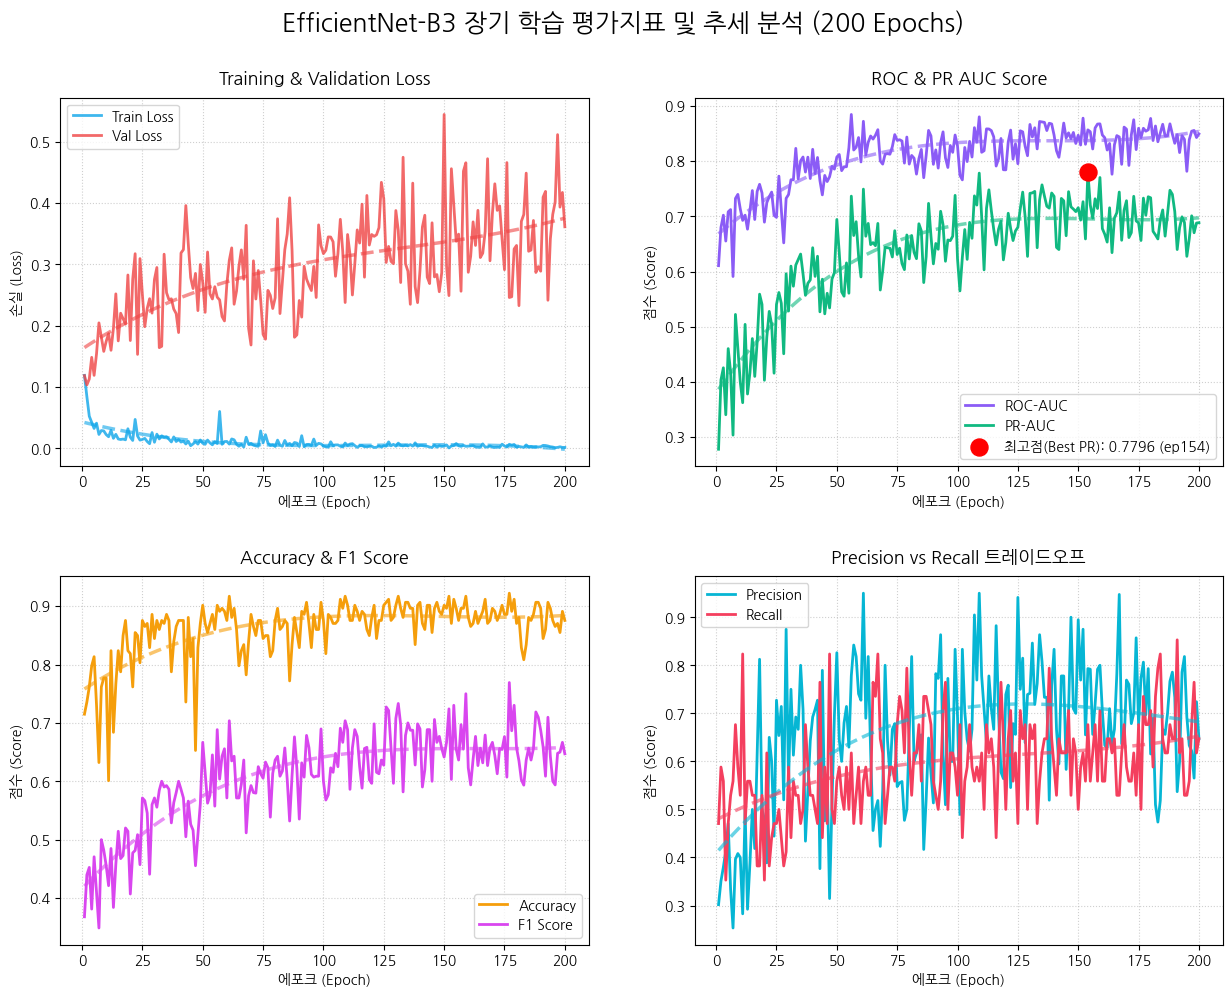

In [32]:
# 1. 코랩용 한글 폰트 설치 (세션당 1회 필수)
!apt-get update -qq
!apt-get install -y fonts-nanum > /dev/null

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 2. 코랩 환경 한글 폰트 강제 적용
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 3. 200에포크 전체 로그 데이터 내장
log_text = """
[train] 577장 로드
[val] 193장 로드
Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
WARNING:huggingface_hub.utils._http:Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
======================================================================
EfficientNet-B3 학습 | 200에폭 | PR-AUC 기준 저장
======================================================================
  Ep    Loss     Acc      F1  Recall    Prec     ROC      PR    Best
----------------------------------------------------------------------
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   1  0.1192  0.1187  0.7150  0.3678  0.4706  0.3019  0.6106  0.2782  0.2782 ✅  (0.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   2  0.0846  0.1036  0.7358  0.4396  0.5882  0.3509  0.6798  0.4038  0.4038 ✅  (1.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   3  0.0526  0.1132  0.7617  0.4524  0.5588  0.3800  0.7020  0.4257  0.4257 ✅  (2.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   4  0.0428  0.1486  0.7979  0.3810  0.3529  0.4138  0.6552  0.3407  0.4257  (2.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   5  0.0326  0.1192  0.8135  0.4706  0.4706  0.4706  0.7081  0.4604  0.4604 ✅  (3.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   6  0.0412  0.1543  0.7306  0.4091  0.5294  0.3333  0.7122  0.4175  0.4604  (4.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   7  0.0228  0.2048  0.6321  0.3486  0.5588  0.2533  0.5910  0.3038  0.4604  (4.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   8  0.0292  0.1810  0.7617  0.5000  0.6765  0.3966  0.7323  0.5223  0.5223 ✅  (5.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
   9  0.0286  0.1583  0.7772  0.4819  0.5882  0.4082  0.7397  0.4614  0.5223  (6.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  10  0.0226  0.1746  0.7772  0.4557  0.5294  0.4000  0.7133  0.3999  0.5223  (7.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  11  0.0191  0.1873  0.6010  0.4211  0.8235  0.2828  0.6926  0.3625  0.5223  (7.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  12  0.0296  0.1601  0.8238  0.4848  0.4706  0.5000  0.7020  0.5043  0.5223  (8.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  13  0.0165  0.1959  0.6839  0.3838  0.5588  0.2923  0.6767  0.3782  0.5223  (9.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  14  0.0230  0.2521  0.7668  0.4578  0.5588  0.3878  0.7098  0.4167  0.5223  (9.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  15  0.0154  0.1754  0.8238  0.5143  0.5294  0.5000  0.7466  0.4786  0.5223  (10.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  16  0.0146  0.2205  0.7876  0.4675  0.5294  0.4186  0.6942  0.4101  0.5223  (10.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  17  0.0153  0.2117  0.8497  0.4727  0.3824  0.6190  0.7451  0.4725  0.5223  (11.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  18  0.0141  0.2028  0.8756  0.5200  0.3824  0.8125  0.7579  0.5590  0.5590 ✅  (12.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  19  0.0321  0.2829  0.8238  0.5143  0.5294  0.5000  0.7423  0.5405  0.5590  (12.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  20  0.0183  0.1760  0.8187  0.4068  0.3529  0.4800  0.6894  0.4031  0.5590  (13.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  21  0.0130  0.2761  0.7617  0.4773  0.6176  0.3889  0.7248  0.4813  0.5590  (14.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  22  0.0473  0.3176  0.8549  0.4815  0.3824  0.6500  0.7355  0.5278  0.5590  (14.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  23  0.0203  0.1534  0.8497  0.5085  0.4412  0.6000  0.7438  0.5041  0.5590  (15.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  24  0.0136  0.3096  0.8031  0.4571  0.4706  0.4444  0.7016  0.4159  0.5590  (16.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  25  0.0147  0.2508  0.8756  0.5714  0.4706  0.7273  0.6981  0.5404  0.5590  (16.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  26  0.0164  0.1986  0.8653  0.5667  0.5000  0.6538  0.7727  0.5620  0.5620 ✅  (17.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  27  0.0113  0.2284  0.8705  0.5455  0.4412  0.7143  0.7118  0.5425  0.5620  (18.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  28  0.0077  0.2442  0.8290  0.4407  0.3824  0.5200  0.6519  0.4511  0.5620  (18.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  29  0.0259  0.2207  0.8860  0.5600  0.4118  0.8750  0.7325  0.5960  0.5960 ✅  (19.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  30  0.0101  0.2757  0.8446  0.5714  0.5882  0.5556  0.7394  0.5284  0.5960  (20.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  31  0.0233  0.2951  0.8756  0.5556  0.4412  0.7500  0.7662  0.6098  0.6098 ✅  (20.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  32  0.0155  0.1644  0.8601  0.5846  0.5588  0.6129  0.7660  0.5734  0.6098  (21.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  33  0.0206  0.1666  0.8756  0.6000  0.5294  0.6923  0.8230  0.6117  0.6117 ✅  (22.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  34  0.0183  0.3168  0.8705  0.5902  0.5294  0.6667  0.7677  0.6215  0.6215 ✅  (22.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  35  0.0191  0.2541  0.8860  0.5926  0.4706  0.8000  0.8004  0.6316  0.6316 ✅  (23.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  36  0.0152  0.2426  0.8756  0.5862  0.5000  0.7083  0.8074  0.5957  0.6316  (24.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  37  0.0106  0.2440  0.7876  0.5287  0.6765  0.4340  0.7801  0.5569  0.6316  (24.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  38  0.0188  0.2273  0.8394  0.5634  0.5882  0.5405  0.8071  0.5786  0.6316  (25.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  39  0.0113  0.2199  0.8653  0.5806  0.5294  0.6429  0.7684  0.5848  0.6316  (25.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  40  0.0145  0.1890  0.8756  0.6000  0.5294  0.6923  0.8213  0.6431  0.6431 ✅  (26.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  41  0.0104  0.3188  0.8756  0.5862  0.5000  0.7083  0.7773  0.5912  0.6431  (27.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  42  0.0119  0.3243  0.8756  0.5714  0.4706  0.7273  0.8065  0.6277  0.6431  (27.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  43  0.0073  0.3961  0.7358  0.5049  0.7647  0.3768  0.7647  0.5270  0.6431  (28.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  44  0.0118  0.3342  0.8808  0.5660  0.4412  0.7895  0.7388  0.5861  0.6431  (29.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  45  0.0045  0.2787  0.8135  0.5263  0.5882  0.4762  0.7740  0.5234  0.6431  (30.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  46  0.0074  0.2608  0.8446  0.5161  0.4706  0.5714  0.7629  0.5606  0.6431  (30.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  47  0.0111  0.2855  0.6528  0.4553  0.8235  0.3146  0.7716  0.5341  0.6431  (31.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  48  0.0071  0.2248  0.8290  0.5075  0.5000  0.5152  0.7904  0.5865  0.6431  (31.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  49  0.0138  0.3000  0.8705  0.5614  0.4706  0.6957  0.7854  0.5981  0.6431  (32.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  50  0.0084  0.2710  0.9016  0.6667  0.5588  0.8261  0.8073  0.6942  0.6942 ✅  (33.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  51  0.0067  0.2220  0.8705  0.6154  0.5882  0.6452  0.8119  0.6345  0.6942  (34.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  52  0.0137  0.3204  0.8549  0.5625  0.5294  0.6000  0.7826  0.5632  0.6942  (34.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  53  0.0090  0.2521  0.8705  0.5763  0.5000  0.6800  0.7897  0.5553  0.6942  (35.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  54  0.0059  0.2438  0.8860  0.6452  0.5882  0.7143  0.7897  0.6156  0.6942  (36.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  55  0.0111  0.2638  0.8601  0.5574  0.5000  0.6296  0.8239  0.5607  0.6942  (36.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  56  0.0080  0.2467  0.9016  0.6885  0.6176  0.7778  0.8844  0.7365  0.7365 ✅  (37.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  57  0.0603  0.2422  0.8912  0.6038  0.4706  0.8421  0.8200  0.6652  0.7365  (37.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  58  0.0067  0.2152  0.8964  0.6429  0.5294  0.8182  0.8250  0.6902  0.7365  (38.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  59  0.0112  0.2080  0.8912  0.6557  0.5882  0.7407  0.8426  0.6287  0.7365  (39.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  60  0.0114  0.2684  0.8756  0.5714  0.4706  0.7273  0.7984  0.5902  0.7365  (39.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  61  0.0071  0.3067  0.9171  0.7037  0.5588  0.9500  0.8720  0.7492  0.7492 ✅  (40.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  62  0.0155  0.3271  0.8808  0.6349  0.5882  0.6897  0.8110  0.6639  0.7492  (41.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  63  0.0141  0.2352  0.8964  0.6429  0.5294  0.8182  0.8339  0.6871  0.7492  (41.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  64  0.0068  0.2567  0.8601  0.5714  0.5294  0.6207  0.8454  0.6487  0.7492  (42.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  65  0.0036  0.2973  0.7979  0.5714  0.7647  0.4561  0.8398  0.6524  0.7492  (43.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  66  0.0067  0.3238  0.8238  0.5952  0.7353  0.5000  0.8468  0.6467  0.7492  (43.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  67  0.0023  0.2759  0.8342  0.6364  0.8235  0.5185  0.8568  0.6871  0.7492  (44.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  68  0.0183  0.3639  0.7824  0.5116  0.6471  0.4231  0.8002  0.5665  0.7492  (45.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  69  0.0067  0.1960  0.8394  0.5753  0.6176  0.5385  0.7945  0.6011  0.7492  (45.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  70  0.0083  0.1687  0.8860  0.5926  0.4706  0.8000  0.8124  0.6438  0.7492  (46.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  71  0.0054  0.3060  0.8653  0.5806  0.5294  0.6429  0.8135  0.6431  0.7492  (47.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  72  0.0041  0.2437  0.8497  0.5797  0.5882  0.5714  0.8124  0.6422  0.7492  (47.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  73  0.0035  0.2902  0.8756  0.6250  0.5882  0.6667  0.8261  0.6263  0.7492  (48.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  74  0.0285  0.2421  0.8756  0.6129  0.5588  0.6786  0.8479  0.6739  0.7492  (48.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  75  0.0090  0.1861  0.8446  0.6053  0.6765  0.5476  0.8374  0.6308  0.7492  (49.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  76  0.0224  0.1782  0.8497  0.6329  0.7353  0.5556  0.8387  0.6422  0.7492  (50.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  77  0.0090  0.2578  0.8497  0.6234  0.7059  0.5581  0.8363  0.6144  0.7492  (50.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  78  0.0049  0.2497  0.8135  0.5385  0.6176  0.4773  0.7963  0.6034  0.7492  (51.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  79  0.0060  0.2282  0.8238  0.6136  0.7941  0.5000  0.8435  0.6662  0.7492  (52.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  80  0.0032  0.2455  0.8756  0.6364  0.6176  0.6562  0.7945  0.6228  0.7492  (52.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  81  0.0136  0.3746  0.8964  0.6429  0.5294  0.8182  0.8102  0.6650  0.7492  (53.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  82  0.0052  0.2200  0.8601  0.6087  0.6176  0.6000  0.8052  0.6348  0.7492  (53.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  83  0.0036  0.2726  0.8653  0.6176  0.6176  0.6176  0.7764  0.6233  0.7492  (54.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  84  0.0130  0.3242  0.8756  0.6571  0.6765  0.6389  0.8043  0.6865  0.7492  (55.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  85  0.0057  0.3498  0.8705  0.6032  0.5588  0.6552  0.8211  0.6737  0.7492  (55.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  86  0.0082  0.4088  0.7720  0.5319  0.7353  0.4167  0.7699  0.5800  0.7492  (56.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  87  0.0046  0.3230  0.8342  0.6098  0.7353  0.5208  0.8098  0.6268  0.7492  (57.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  88  0.0097  0.1813  0.8808  0.6761  0.7059  0.6486  0.8555  0.7234  0.7492  (57.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  89  0.0088  0.1852  0.8549  0.6216  0.6765  0.5750  0.8455  0.6641  0.7492  (58.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  90  0.0031  0.2413  0.8290  0.5352  0.5588  0.5135  0.7941  0.6139  0.7492  (59.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  91  0.0208  0.2142  0.8912  0.6316  0.5294  0.7826  0.8202  0.6508  0.7492  (60.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  92  0.0027  0.2971  0.8860  0.6071  0.5000  0.7727  0.7873  0.6403  0.7492  (60.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  93  0.0065  0.2763  0.9067  0.6786  0.5588  0.8636  0.8333  0.7091  0.7492  (61.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  94  0.0067  0.2662  0.8705  0.6575  0.7059  0.6154  0.8529  0.6847  0.7492  (61.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  95  0.0048  0.2575  0.8290  0.6118  0.7647  0.5098  0.8058  0.6186  0.7492  (62.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  96  0.0153  0.2969  0.8860  0.6071  0.5000  0.7727  0.7884  0.6571  0.7492  (63.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  97  0.0049  0.2462  0.8601  0.6087  0.6176  0.6000  0.8282  0.6559  0.7492  (64.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  98  0.0083  0.3646  0.8601  0.6087  0.6176  0.6000  0.8158  0.6639  0.7492  (64.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
  99  0.0074  0.3307  0.9067  0.6897  0.5882  0.8333  0.8472  0.7379  0.7492  (65.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 100  0.0039  0.3177  0.8756  0.6000  0.5294  0.6923  0.8272  0.6229  0.7492  (66.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 101  0.0028  0.3232  0.8187  0.5679  0.6765  0.4894  0.7743  0.5649  0.7492  (66.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 102  0.0020  0.3450  0.8860  0.5769  0.4412  0.8333  0.7660  0.6256  0.7492  (67.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 103  0.0109  0.3448  0.8808  0.6230  0.5588  0.7037  0.8246  0.6760  0.7492  (68.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 104  0.0044  0.3370  0.8705  0.6154  0.5882  0.6452  0.7991  0.6220  0.7492  (68.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 105  0.0058  0.2808  0.8705  0.6479  0.6765  0.6216  0.8357  0.6890  0.7492  (69.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 106  0.0058  0.3174  0.8756  0.6250  0.5882  0.6667  0.8073  0.6602  0.7492  (69.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 107  0.0037  0.3737  0.9119  0.6909  0.5588  0.9048  0.8605  0.7370  0.7492  (70.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 108  0.0024  0.3213  0.8964  0.6667  0.5882  0.7692  0.8341  0.7203  0.7492  (71.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 109  0.0088  0.2380  0.9171  0.7037  0.5588  0.9500  0.8801  0.7782  0.7782 ✅  (72.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 110  0.0047  0.3489  0.9016  0.6885  0.6176  0.7778  0.8159  0.6995  0.7782  (72.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 111  0.0072  0.3164  0.8756  0.5862  0.5000  0.7083  0.8187  0.6030  0.7782  (73.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 112  0.0078  0.2503  0.8756  0.6571  0.6765  0.6389  0.8583  0.7145  0.7782  (73.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 113  0.0046  0.3013  0.9016  0.6885  0.6176  0.7778  0.8581  0.7479  0.7782  (74.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 114  0.0017  0.3564  0.8912  0.6769  0.6471  0.7097  0.8552  0.7103  0.7782  (75.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 115  0.0046  0.3350  0.8756  0.6250  0.5882  0.6667  0.8439  0.6762  0.7782  (75.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 116  0.0049  0.3984  0.8912  0.5882  0.4412  0.8824  0.7910  0.6482  0.7782  (76.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 117  0.0028  0.2793  0.8860  0.6562  0.6176  0.7000  0.8041  0.6767  0.7782  (77.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 118  0.0026  0.4126  0.8601  0.6582  0.7647  0.5778  0.8409  0.6910  0.7782  (77.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 119  0.0034  0.3317  0.8497  0.6027  0.6471  0.5641  0.7843  0.6211  0.7782  (78.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 120  0.0036  0.3489  0.8808  0.5965  0.5000  0.7391  0.7841  0.6522  0.7782  (79.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 121  0.0015  0.3459  0.9016  0.6984  0.6471  0.7586  0.8346  0.7055  0.7782  (79.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 122  0.0020  0.3485  0.8446  0.6154  0.7059  0.5455  0.8561  0.6782  0.7782  (80.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 123  0.0042  0.3600  0.8756  0.6129  0.5588  0.6786  0.8034  0.6561  0.7782  (81.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 124  0.0021  0.4340  0.8756  0.6364  0.6176  0.6562  0.8313  0.6735  0.7782  (81.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 125  0.0046  0.4070  0.9016  0.6275  0.4706  0.9412  0.7952  0.6801  0.7782  (82.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 126  0.0036  0.3033  0.9067  0.7273  0.7059  0.7500  0.8548  0.7140  0.7782  (83.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 127  0.0107  0.3295  0.9119  0.7213  0.6471  0.8148  0.8529  0.7438  0.7782  (83.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 128  0.0043  0.3052  0.8756  0.6571  0.6765  0.6389  0.8269  0.6999  0.7782  (84.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 129  0.0067  0.3013  0.8808  0.5965  0.5000  0.7391  0.8097  0.6274  0.7782  (85.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 130  0.0037  0.3880  0.9016  0.7077  0.6765  0.7419  0.8663  0.7416  0.7782  (85.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 131  0.0087  0.3557  0.9171  0.7333  0.6471  0.8462  0.8437  0.7424  0.7782  (86.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 132  0.0050  0.2706  0.8964  0.6970  0.6765  0.7188  0.8603  0.7451  0.7782  (87.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 133  0.0041  0.4749  0.8808  0.5818  0.4706  0.7619  0.8220  0.6431  0.7782  (87.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 134  0.0053  0.3011  0.9067  0.6786  0.5588  0.8636  0.8716  0.7303  0.7782  (88.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 135  0.0041  0.2891  0.9067  0.7000  0.6176  0.8077  0.8709  0.7569  0.7782  (89.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 136  0.0063  0.2351  0.8964  0.6875  0.6471  0.7333  0.8701  0.7368  0.7782  (89.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 137  0.0038  0.4327  0.8964  0.6875  0.6471  0.7333  0.8553  0.7182  0.7782  (90.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 138  0.0091  0.2640  0.8342  0.6279  0.7941  0.5192  0.8685  0.7148  0.7782  (91.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 139  0.0036  0.2378  0.9016  0.6984  0.6471  0.7586  0.8672  0.7422  0.7782  (91.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 140  0.0049  0.2903  0.9067  0.6897  0.5882  0.8333  0.8470  0.7362  0.7782  (92.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 141  0.0047  0.3611  0.8705  0.5902  0.5294  0.6667  0.8187  0.6437  0.7782  (93.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 142  0.0039  0.3803  0.8601  0.6197  0.6471  0.5946  0.8069  0.6398  0.7782  (93.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 143  0.0036  0.2794  0.9016  0.6885  0.6176  0.7778  0.8357  0.7324  0.7782  (94.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 144  0.0023  0.2689  0.9016  0.6885  0.6176  0.7778  0.8688  0.7280  0.7782  (95.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 145  0.0016  0.3680  0.8549  0.6000  0.6176  0.5833  0.8418  0.6648  0.7782  (95.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 146  0.0053  0.2797  0.8964  0.7059  0.7059  0.7059  0.8511  0.7446  0.7782  (96.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 147  0.0020  0.2836  0.9067  0.6667  0.5294  0.9000  0.8404  0.7171  0.7782  (97.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 148  0.0045  0.2556  0.8912  0.6769  0.6471  0.7097  0.8518  0.7131  0.7782  (97.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 149  0.0034  0.2866  0.8860  0.6562  0.6176  0.7000  0.8319  0.7085  0.7782  (98.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 150  0.0037  0.5447  0.9016  0.6415  0.5000  0.8947  0.8468  0.7156  0.7782  (98.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 151  0.0058  0.2976  0.8964  0.6667  0.5882  0.7692  0.8291  0.6931  0.7782  (99.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 152  0.0008  0.2493  0.9171  0.7241  0.6176  0.8750  0.8777  0.7264  0.7782  (100.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 153  0.0041  0.4562  0.8705  0.6032  0.5588  0.6552  0.8304  0.6590  0.7782  (100.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 154  0.0046  0.3972  0.9119  0.7302  0.6765  0.7931  0.8565  0.7796  0.7796 ✅  (101.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 155  0.0080  0.3379  0.8964  0.6552  0.5588  0.7917  0.8531  0.7202  0.7796  (102.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 156  0.0044  0.3495  0.8756  0.6364  0.6176  0.6562  0.8219  0.6967  0.7796  (103.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 157  0.0034  0.2564  0.8964  0.6970  0.6765  0.7188  0.8600  0.7317  0.7796  (103.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 158  0.0050  0.4522  0.8964  0.6552  0.5588  0.7917  0.8670  0.7141  0.7796  (104.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 159  0.0035  0.4659  0.9171  0.7500  0.7059  0.8000  0.8674  0.7702  0.7796  (104.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 160  0.0038  0.2873  0.8808  0.6230  0.5588  0.7037  0.8472  0.6777  0.7796  (105.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 161  0.0041  0.3136  0.8653  0.5938  0.5588  0.6333  0.8422  0.6675  0.7796  (106.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 162  0.0047  0.3695  0.8705  0.6377  0.6471  0.6286  0.8200  0.6533  0.7796  (106.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 163  0.0023  0.3311  0.8912  0.6769  0.6471  0.7097  0.8319  0.7154  0.7796  (107.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 164  0.0020  0.3883  0.8705  0.6269  0.6176  0.6364  0.7762  0.6342  0.7796  (108.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 165  0.0019  0.3114  0.8808  0.6567  0.6471  0.6667  0.8296  0.6967  0.7796  (108.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 166  0.0074  0.3185  0.8912  0.6316  0.5294  0.7826  0.8461  0.7066  0.7796  (109.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 167  0.0023  0.3538  0.9119  0.6792  0.5294  0.9474  0.8437  0.7439  0.7796  (109.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 168  0.0023  0.4725  0.8705  0.6269  0.6176  0.6364  0.7941  0.6566  0.7796  (110.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 169  0.0041  0.3061  0.8756  0.6571  0.6765  0.6389  0.8615  0.7111  0.7796  (111.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 170  0.0020  0.3835  0.8964  0.6667  0.5882  0.7692  0.8578  0.7282  0.7796  (111.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 171  0.0016  0.4316  0.8912  0.6441  0.5588  0.7600  0.7921  0.6615  0.7796  (112.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 172  0.0022  0.3883  0.8756  0.6129  0.5588  0.6786  0.8474  0.6704  0.7796  (113.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 173  0.0017  0.3955  0.8860  0.6562  0.6176  0.7000  0.8748  0.7362  0.7796  (113.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 174  0.0070  0.3415  0.9016  0.6545  0.5294  0.8571  0.8208  0.6916  0.7796  (114.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 175  0.0041  0.2915  0.8860  0.6765  0.6765  0.6765  0.8594  0.6881  0.7796  (114.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 176  0.0023  0.4662  0.8860  0.6071  0.5000  0.7727  0.8424  0.6562  0.7796  (115.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 177  0.0068  0.2462  0.9223  0.7692  0.7353  0.8065  0.8594  0.7329  0.7796  (116.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 178  0.0053  0.2474  0.8912  0.6866  0.6765  0.6970  0.8541  0.7019  0.7796  (116.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 179  0.0065  0.3253  0.9119  0.7302  0.6765  0.7931  0.8566  0.7354  0.7796  (117.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 180  0.0018  0.3310  0.8705  0.6575  0.7059  0.6154  0.8772  0.7335  0.7796  (118.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 181  0.0033  0.2329  0.8808  0.6349  0.5882  0.6897  0.8372  0.6728  0.7796  (118.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 182  0.0025  0.3704  0.8290  0.6024  0.7353  0.5102  0.8635  0.6663  0.7796  (119.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 183  0.0018  0.3816  0.8083  0.5934  0.7941  0.4737  0.8350  0.6590  0.7796  (120.2min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 184  0.0058  0.4490  0.8342  0.6364  0.8235  0.5185  0.8505  0.6938  0.7796  (120.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 185  0.0023  0.3216  0.8808  0.6567  0.6471  0.6667  0.8666  0.7115  0.7796  (121.5min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 186  0.0032  0.3236  0.8756  0.6364  0.6176  0.6562  0.8454  0.6641  0.7796  (122.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 187  0.0023  0.3718  0.8860  0.6562  0.6176  0.7000  0.8459  0.7046  0.7796  (122.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 188  0.0028  0.2870  0.9067  0.7188  0.6765  0.7667  0.8674  0.7471  0.7796  (123.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 189  0.0024  0.2966  0.9067  0.7097  0.6471  0.7857  0.8489  0.7397  0.7796  (124.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 190  0.0028  0.2891  0.8964  0.6875  0.6471  0.7333  0.8322  0.7085  0.7796  (124.7min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 191  0.0050  0.4098  0.8446  0.6591  0.8529  0.5370  0.8478  0.6398  0.7796  (125.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 192  0.0048  0.4192  0.8601  0.6087  0.6176  0.6000  0.8154  0.6794  0.7796  (125.9min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 193  0.0040  0.2417  0.9067  0.7097  0.6471  0.7857  0.8461  0.6990  0.7796  (126.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 194  0.0028  0.3416  0.8964  0.6429  0.5294  0.8182  0.8393  0.6890  0.7796  (127.3min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 195  0.0023  0.3818  0.8756  0.6000  0.5294  0.6923  0.7815  0.6275  0.7796  (128.1min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 196  0.0012  0.4019  0.8653  0.5938  0.5588  0.6333  0.8387  0.6592  0.7796  (128.8min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 197  0.0017  0.5118  0.8705  0.6479  0.6765  0.6216  0.8541  0.7009  0.7796  (129.4min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 198  0.0027  0.3936  0.8549  0.6500  0.7647  0.5652  0.8555  0.6702  0.7796  (130.0min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 199  0.0017  0.4175  0.8912  0.6667  0.6176  0.7241  0.8426  0.6878  0.7796  (130.6min)
  Ep  TrLoss  VaLoss     Acc      F1  Recall    Prec     ROC      PR    Best
--------------------------------------------------------------------------------
 200  0.0017  0.3615  0.8756  0.6471  0.6471  0.6471  0.8491  0.6884  0.7796  (131.3min)
"""

# 4. 데이터 파싱
data = []
pattern = re.compile(r'^\s*(\d+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)')

for line in log_text.strip().split('\n'):
    match = pattern.match(line)
    if match:
        ep, tr_loss, va_loss, acc, f1, recall, prec, roc, pr = map(float, match.groups())
        data.append([int(ep), tr_loss, va_loss, acc, f1, recall, prec, roc, pr])

df = pd.DataFrame(data, columns=['Epoch', 'TrLoss', 'VaLoss', 'Acc', 'F1', 'Recall', 'Prec', 'ROC', 'PR'])

# 5. 고급 추세선 함수 (3차 다항식 곡선 적용)
def plot_smooth_trendline(ax, x, y, color):
    if len(x) > 3:
        z = np.polyfit(x, y, 3)
        p = np.poly1d(z)
        x_trend = np.linspace(min(x), max(x), 100)
        ax.plot(x_trend, p(x_trend), linestyle='--', color=color, alpha=0.6, linewidth=2.5)

# 6. 그래프 그리기 (4개의 서브플롯)
fig, axs = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('EfficientNet-B3 장기 학습 평가지표 및 추세 분석 (200 Epochs)', fontsize=18, fontweight='bold', y=0.96)

# [1] Train vs Validation Loss
axs[0, 0].plot(df['Epoch'], df['TrLoss'], label='Train Loss', color='#0EA5E9', alpha=0.8, linewidth=2)
axs[0, 0].plot(df['Epoch'], df['VaLoss'], label='Val Loss', color='#EF4444', alpha=0.8, linewidth=2)
plot_smooth_trendline(axs[0, 0], df['Epoch'], df['TrLoss'], '#0EA5E9')
plot_smooth_trendline(axs[0, 0], df['Epoch'], df['VaLoss'], '#EF4444')
axs[0, 0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold', pad=10)
axs[0, 0].set_xlabel('에포크 (Epoch)')
axs[0, 0].set_ylabel('손실 (Loss)')
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle=':', alpha=0.6)

# [2] ROC-AUC & PR-AUC
axs[0, 1].plot(df['Epoch'], df['ROC'], label='ROC-AUC', color='#8B5CF6', linewidth=2)
axs[0, 1].plot(df['Epoch'], df['PR'], label='PR-AUC', color='#10B981', linewidth=2)
plot_smooth_trendline(axs[0, 1], df['Epoch'], df['ROC'], '#8B5CF6')
plot_smooth_trendline(axs[0, 1], df['Epoch'], df['PR'], '#10B981')
# 신기록 하이라이트
best_ep = df.loc[df['PR'].idxmax()]
axs[0, 1].scatter(best_ep['Epoch'], best_ep['PR'], color='red', s=150, zorder=5, label=f"최고점(Best PR): {best_ep['PR']:.4f} (ep{int(best_ep['Epoch'])})")
axs[0, 1].set_title('ROC & PR AUC Score', fontsize=13, fontweight='bold', pad=10)
axs[0, 1].set_xlabel('에포크 (Epoch)')
axs[0, 1].set_ylabel('점수 (Score)')
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle=':', alpha=0.6)

# [3] Accuracy & F1 Score
axs[1, 0].plot(df['Epoch'], df['Acc'], label='Accuracy', color='#F59E0B', linewidth=2)
axs[1, 0].plot(df['Epoch'], df['F1'], label='F1 Score', color='#D946EF', linewidth=2)
plot_smooth_trendline(axs[1, 0], df['Epoch'], df['Acc'], '#F59E0B')
plot_smooth_trendline(axs[1, 0], df['Epoch'], df['F1'], '#D946EF')
axs[1, 0].set_title('Accuracy & F1 Score', fontsize=13, fontweight='bold', pad=10)
axs[1, 0].set_xlabel('에포크 (Epoch)')
axs[1, 0].set_ylabel('점수 (Score)')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle=':', alpha=0.6)

# [4] Precision vs Recall
axs[1, 1].plot(df['Epoch'], df['Prec'], label='Precision', color='#06B6D4', linewidth=2)
axs[1, 1].plot(df['Epoch'], df['Recall'], label='Recall', color='#F43F5E', linewidth=2)
plot_smooth_trendline(axs[1, 1], df['Epoch'], df['Prec'], '#06B6D4')
plot_smooth_trendline(axs[1, 1], df['Epoch'], df['Recall'], '#F43F5E')
axs[1, 1].set_title('Precision vs Recall 트레이드오프', fontsize=13, fontweight='bold', pad=10)
axs[1, 1].set_xlabel('에포크 (Epoch)')
axs[1, 1].set_ylabel('점수 (Score)')
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()